# **Lojistik Regresyon ve Sınıflandırma**

### 📚 **Ders Giriş**

Bu notebook'ta **gözetimli öğrenmenin** iki büyük dalından biri olan **sınıflandırma** problemlerini ele alacağız. Daha önce regresyon ile sürekli değerler tahmin etmeyi öğrendiniz. Şimdi ise **kategorik** sonuçlar tahmin etmeyi öğreneceğiz.

**Öğrenme Hedefleri:**
- ✓ Regresyon ve Sınıflandırma arasındaki farkları anlamak
- ✓ İkili ve çok sınıflı sınıflandırma problemlerini çözmek
- ✓ Lojistik Regresyon algoritmasını kullanmak
- ✓ Model performansını YBS perspektifinden değerlendirmek
- ✓ İş problemlerine göre doğru metrikleri seçmek

## 🎯 **ADIM 1: Giriş ve Temel Kavramlar**
### **1.1 Regresyon vs Sınıflandırma: Temel Fark**

In [1]:
# Gerekli kütüphaneleri import edelim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Görselleştirme ayarları (Pastel renkler ve profesyonel görünüm)
plt.style.use('seaborn-v0_8-pastel')
sns.set_palette("pastel")
warnings.filterwarnings('ignore')

# Grafik boyutları
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ Kütüphaneler başarıyla yüklendi!")
print("📊 Görselleştirme ayarları yapılandırıldı.")

✅ Kütüphaneler başarıyla yüklendi!
📊 Görselleştirme ayarları yapılandırıldı.


### 📊 **Regresyon vs Sınıflandırma Karşılaştırması**

İki yaklaşım arasındaki temel farkı anlamak için somut bir örnek üzerinden gidelim:

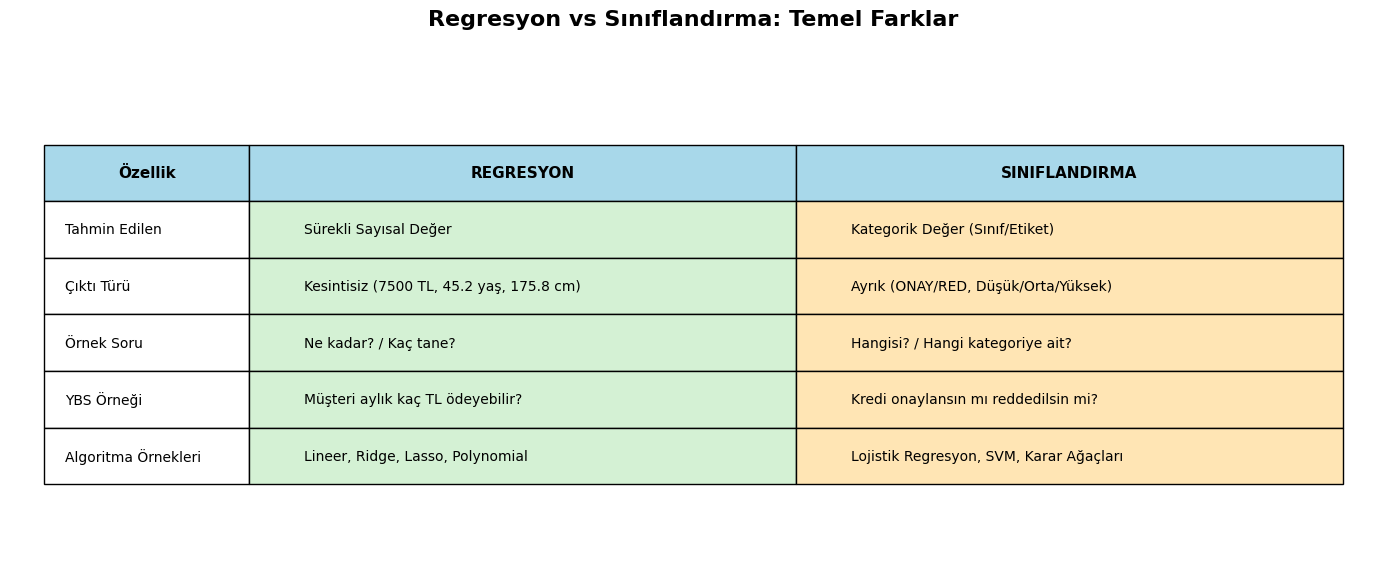


💡 ÖNEMLİ NOKTA:
Regresyon: 'NE KADAR?' sorusuna cevap verir.
Sınıflandırma: 'HANGİSİ?' sorusuna cevap verir.


In [2]:
# Karşılaştırma tablosu oluşturalım
karsilastirma_data = {
    'Özellik': ['Tahmin Edilen', 'Çıktı Türü', 'Örnek Soru', 'YBS Örneği', 'Algoritma Örnekleri'],
    'REGRESYON': [
        'Sürekli Sayısal Değer',
        'Kesintisiz (7500 TL, 45.2 yaş, 175.8 cm)',
        'Ne kadar? / Kaç tane?',
        'Müşteri aylık kaç TL ödeyebilir?',
        'Lineer, Ridge, Lasso, Polynomial'
    ],
    'SINIFLANDIRMA': [
        'Kategorik Değer (Sınıf/Etiket)',
        'Ayrık (ONAY/RED, Düşük/Orta/Yüksek)',
        'Hangisi? / Hangi kategoriye ait?',
        'Kredi onaylansın mı reddedilsin mi?',
        'Lojistik Regresyon, SVM, Karar Ağaçları'
    ]
}

df_karsilastirma = pd.DataFrame(karsilastirma_data)

# Tabloyu görselleştirelim
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('tight')
ax.axis('off')

# Pastel renklerle tablo oluşturma
table = ax.table(cellText=df_karsilastirma.values, 
                colLabels=df_karsilastirma.columns,
                cellLoc='left', 
                loc='center',
                colWidths=[0.15, 0.4, 0.4])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 3)

# Header'ı vurgula (koyu pastel mavi)
for i in range(len(df_karsilastirma.columns)):
    table[(0, i)].set_facecolor('#A8D8EA')
    table[(0, i)].set_text_props(weight='bold', size=11)

# Regresyon sütunu (pastel yeşil)
for i in range(1, len(df_karsilastirma) + 1):
    table[(i, 1)].set_facecolor('#D4F1D4')

# Sınıflandırma sütunu (pastel turuncu)
for i in range(1, len(df_karsilastirma) + 1):
    table[(i, 2)].set_facecolor('#FFE5B4')

plt.title('Regresyon vs Sınıflandırma: Temel Farklar', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 ÖNEMLİ NOKTA:")
print("Regresyon: 'NE KADAR?' sorusuna cevap verir.")
print("Sınıflandırma: 'HANGİSİ?' sorusuna cevap verir.")

### 🏦 **YBS'de Sınıflandırma: Banka Kredi Onay Sistemi**

**Senaryomuz:**

Bir bankada **Kredi Karar Destek Sistemi** geliştirilmesi gerekiyor. Banka müdürü artık manuel karar vermek yerine, makine öğrenmesi destekli bir sistem istiyor.

**Mevcut Durum:**
- Günde ortalama 500 kredi başvurusu geliyor
- Her başvuru manuel inceleniyor (1 başvuru = 15 dakika)
- İnsan hatası yüksek
- Tutarsız kararlar alınıyor

**Hedef Durum:**
- Otomatik ön değerlendirme sistemi
- Tutarlı ve hızlı kararlar
- Riski minimize etme
- Müşteri memnuniyetini artırma

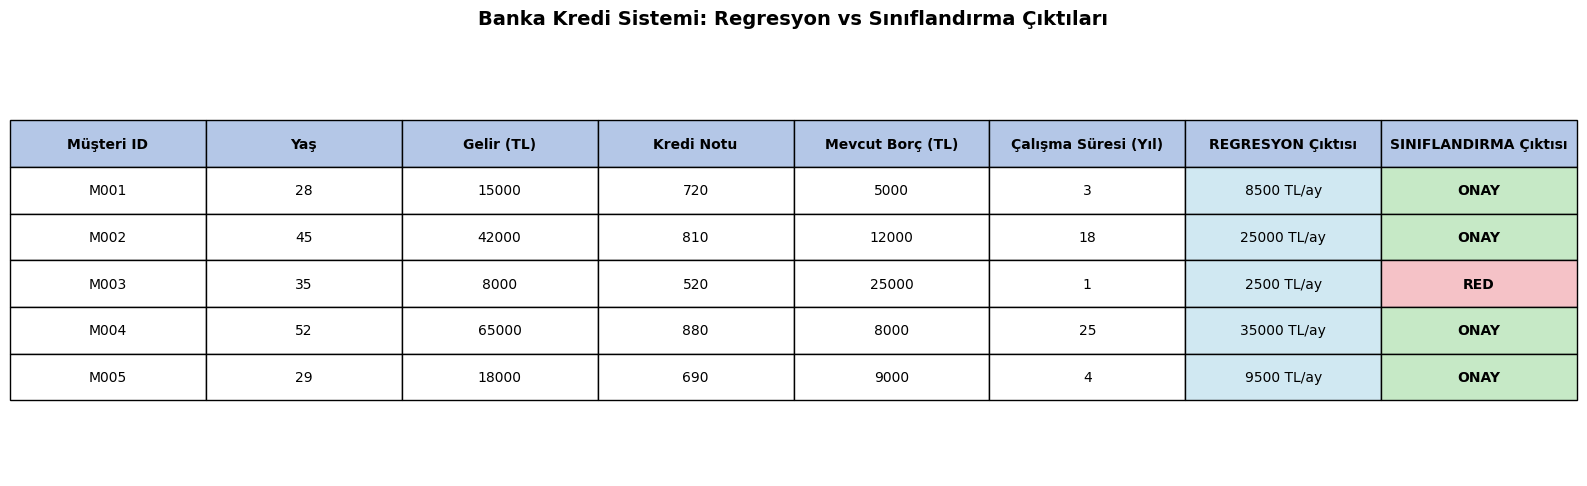


🎯 FARK EDİN:
• Regresyon: Her müşteri için ödeme KAPASİTESİ hesaplıyor (sürekli değer)
• Sınıflandırma: Her müşteri için KARAR üretiyor (kategorik değer)

💼 YBS Açısından: Banka için asıl değerli olan KARAR'dır!


In [3]:
# Banka verisi için örnek müşteri profilleri oluşturalım
np.random.seed(42)

# Senaryo verileri
senaryolar = {
    'Müşteri ID': ['M001', 'M002', 'M003', 'M004', 'M005'],
    'Yaş': [28, 45, 35, 52, 29],
    'Gelir (TL)': [15000, 42000, 8000, 65000, 18000],
    'Kredi Notu': [720, 810, 520, 880, 690],
    'Mevcut Borç (TL)': [5000, 12000, 25000, 8000, 9000],
    'Çalışma Süresi (Yıl)': [3, 18, 1, 25, 4],
    'REGRESYON Çıktısı': ['8500 TL/ay', '25000 TL/ay', '2500 TL/ay', '35000 TL/ay', '9500 TL/ay'],
    'SINIFLANDIRMA Çıktısı': ['ONAY', 'ONAY', 'RED', 'ONAY', 'ONAY']
}

df_senaryolar = pd.DataFrame(senaryolar)

# Görseli oluştur
fig, ax = plt.subplots(figsize=(16, 5))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df_senaryolar.values, 
                colLabels=df_senaryolar.columns,
                cellLoc='center', 
                loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Header renklendirme
for i in range(len(df_senaryolar.columns)):
    table[(0, i)].set_facecolor('#B4C7E7')
    table[(0, i)].set_text_props(weight='bold')

# Regresyon çıktısı (pastel mavi)
for i in range(1, 6):
    table[(i, 6)].set_facecolor('#D0E8F2')

# Sınıflandırma çıktıları (ONAY=yeşil, RED=kırmızı)
for i in range(1, 6):
    if df_senaryolar.iloc[i-1]['SINIFLANDIRMA Çıktısı'] == 'ONAY':
        table[(i, 7)].set_facecolor('#C6E9C6')
    else:
        table[(i, 7)].set_facecolor('#F5C2C7')
    table[(i, 7)].set_text_props(weight='bold')

plt.title('Banka Kredi Sistemi: Regresyon vs Sınıflandırma Çıktıları', 
         fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n🎯 FARK EDİN:")
print("• Regresyon: Her müşteri için ödeme KAPASİTESİ hesaplıyor (sürekli değer)")
print("• Sınıflandırma: Her müşteri için KARAR üretiyor (kategorik değer)")
print("\n💼 YBS Açısından: Banka için asıl değerli olan KARAR'dır!")

### 📐 **Gözetimli Öğrenme Haritası**

Şimdi büyük resmi görmek için gözetimli öğrenmenin yapısını görselleştirelim:

In [4]:
# Mermaid diyagramı için IPython display kullanacağız
from IPython.display import display, Markdown

mermaid_code = '''
```mermaid
graph TB
    A["🤖 Gözetimli Öğrenme<br/><b>Supervised Learning</b>"] --> B["📊 REGRESYON<br/>Sürekli Sayısal Çıktı"]
    A --> C["🎯 SINIFLANDIRMA<br/>Kategorik Çıktı"]
    
    B --> B1["📈 Lineer Regresyon"]
    B --> B2["🔄 Polynomial Regresyon"]
    B --> B3["🌳 Karar Ağacı Regresyon"]
    
    C --> C1["✌️ İkili Sınıflandırma<br/><i>Binary Classification</i>"]
    C --> C2["🎨 Çok Sınıflı<br/><i>Multiclass Classification</i>"]
    
    C1 --> C1A["🔵 Lojistik Regresyon<br/><b>Bu dersin konusu!</b>"]
    C1 --> C1B["📊 SVM"]
    
    C2 --> C2A["🔀 One-vs-Rest"]
    C2 --> C2B["🔁 One-vs-One"]
    
    style A fill:#A8D8EA,stroke:#333,stroke-width:3px,color:#000
    style B fill:#D4F1D4,stroke:#333,stroke-width:2px,color:#000
    style C fill:#FFE5B4,stroke:#333,stroke-width:2px,color:#000
    style C1A fill:#FFB6C1,stroke:#333,stroke-width:3px,color:#000
    style C1 fill:#FFDAB9,stroke:#333,stroke-width:2px,color:#000
    style C2 fill:#E6E6FA,stroke:#333,stroke-width:2px,color:#000
```
'''

display(Markdown(mermaid_code))

print("\n📌 NOTLAR:")
print("• Gözetimli öğrenme iki ana dala ayrılır")
print("• Regresyon: Sayısal tahmin (ev fiyatı, sıcaklık, satış miktarı)")
print("• Sınıflandırma: Kategori tahmini (onay/red, hastalık türü, müşteri segmenti)")
print("• Lojistik Regresyon: Adında 'regresyon' geçse de SINIFLANDIRMA algoritmasıdır!")


```mermaid
graph TB
    A["🤖 Gözetimli Öğrenme<br/><b>Supervised Learning</b>"] --> B["📊 REGRESYON<br/>Sürekli Sayısal Çıktı"]
    A --> C["🎯 SINIFLANDIRMA<br/>Kategorik Çıktı"]

    B --> B1["📈 Lineer Regresyon"]
    B --> B2["🔄 Polynomial Regresyon"]
    B --> B3["🌳 Karar Ağacı Regresyon"]

    C --> C1["✌️ İkili Sınıflandırma<br/><i>Binary Classification</i>"]
    C --> C2["🎨 Çok Sınıflı<br/><i>Multiclass Classification</i>"]

    C1 --> C1A["🔵 Lojistik Regresyon<br/><b>Bu dersin konusu!</b>"]
    C1 --> C1B["📊 SVM"]

    C2 --> C2A["🔀 One-vs-Rest"]
    C2 --> C2B["🔁 One-vs-One"]

    style A fill:#A8D8EA,stroke:#333,stroke-width:3px,color:#000
    style B fill:#D4F1D4,stroke:#333,stroke-width:2px,color:#000
    style C fill:#FFE5B4,stroke:#333,stroke-width:2px,color:#000
    style C1A fill:#FFB6C1,stroke:#333,stroke-width:3px,color:#000
    style C1 fill:#FFDAB9,stroke:#333,stroke-width:2px,color:#000
    style C2 fill:#E6E6FA,stroke:#333,stroke-width:2px,color:#000
```



📌 NOTLAR:
• Gözetimli öğrenme iki ana dala ayrılır
• Regresyon: Sayısal tahmin (ev fiyatı, sıcaklık, satış miktarı)
• Sınıflandırma: Kategori tahmini (onay/red, hastalık türü, müşteri segmenti)
• Lojistik Regresyon: Adında 'regresyon' geçse de SINIFLANDIRMA algoritmasıdır!


### 🔍 **Neden Lineer Regresyon Sınıflandırma İçin Uygun Değil?**

Öğrenciler sıklıkla sorar: *"Hocam lineer regresyon yapıp, 0.5'in üstünü ONAY, altını RED desek olmaz mı?"*

Teorik olarak mümkün görünse de **ciddi problemler** var. Hadi görelim:

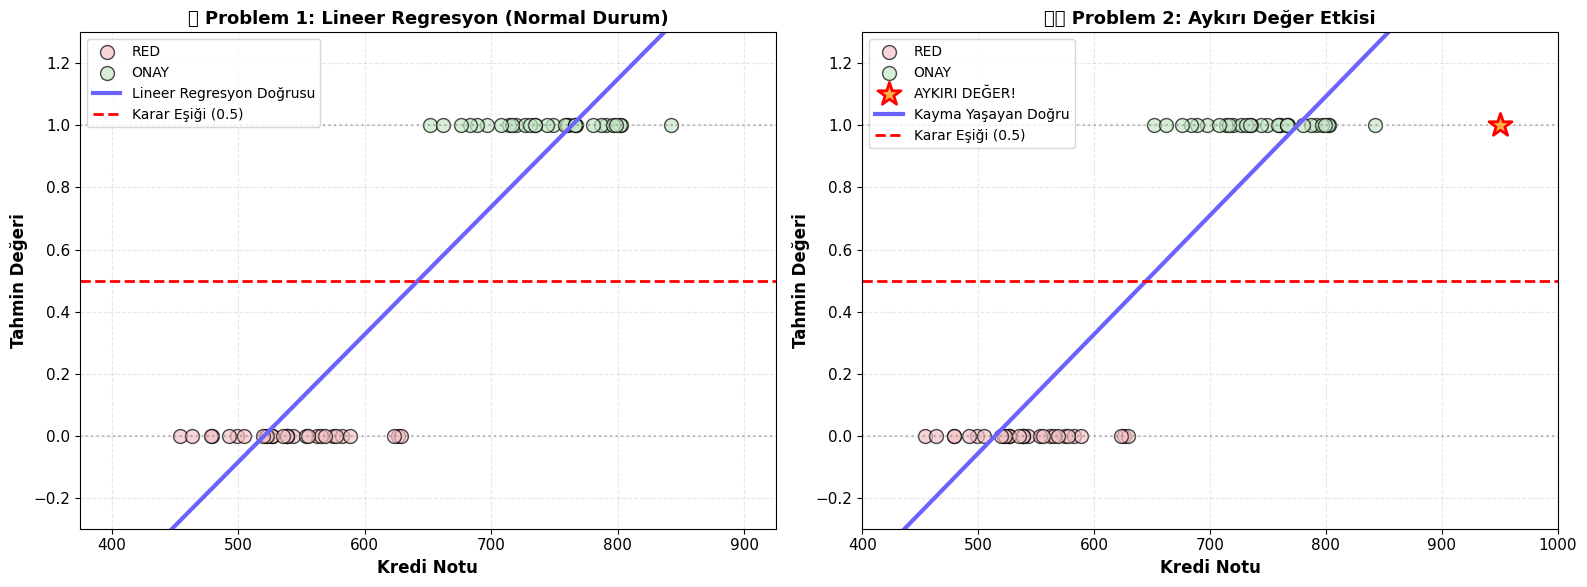


⚠️ LİNEER REGRESYON İLE SINIFLANDIRMA PROBLEMLERI:

1️⃣ SINIR AŞIMI:
   • Minimum tahmin: -0.50
   • Maksimum tahmin: 1.56
   • Çıktı 0-1 aralığının dışına çıkabilir (örn: -0.3 veya 1.5)
   • Banka '1.5 oranında onaylı' kredi veremez!

2️⃣ AYKIRI DEĞER HASSASIYETI:
   • Tek bir aykırı değer tüm doğruyu kaydırır
   • Doğru müşterilere RED, riskli müşterilere ONAY verilebilir
   • YBS açısından: Milyonlarca TL zarar riski!

3️⃣ OLASILIK YORUMLAMA:
   • Lineer regresyon çıktısı gerçek olasılık değildir
   • 0.7 değeri '%70 onay olasılığı' anlamına gelmez

✅ ÇÖZÜM: Lojistik Regresyon ve Sigmoid Fonksiyonu (Sonraki adımda göreceğiz!)


In [5]:
# Basit bir veri seti oluşturalım
# Kredi notu ile kredi onayı ilişkisi
np.random.seed(42)

# Düşük kredi notu -> RED (0), Yüksek kredi notu -> ONAY (1)
kredi_notu_red = np.random.normal(550, 50, 30)
kredi_notu_onay = np.random.normal(750, 50, 30)

kredi_notu = np.concatenate([kredi_notu_red, kredi_notu_onay])
karar = np.concatenate([np.zeros(30), np.ones(30)])

# Şimdi bir aykırı değer ekleyelim (çok yüksek kredi notu)
kredi_notu_outlier = np.array([950])
karar_outlier = np.array([1])

kredi_notu_with_outlier = np.concatenate([kredi_notu, kredi_notu_outlier])
karar_with_outlier = np.concatenate([karar, karar_outlier])

# Lineer regresyon modelleri
from sklearn.linear_model import LinearRegression

# Model 1: Aykırı değer olmadan
model_normal = LinearRegression()
model_normal.fit(kredi_notu.reshape(-1, 1), karar)
y_pred_normal = model_normal.predict(np.linspace(400, 900, 100).reshape(-1, 1))

# Model 2: Aykırı değer ile
model_outlier = LinearRegression()
model_outlier.fit(kredi_notu_with_outlier.reshape(-1, 1), karar_with_outlier)
y_pred_outlier = model_outlier.predict(np.linspace(400, 1000, 100).reshape(-1, 1))

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol grafik: Normal durum
axes[0].scatter(kredi_notu[karar==0], karar[karar==0], 
               color='#F5C2C7', s=100, alpha=0.7, label='RED', edgecolors='black', linewidth=1)
axes[0].scatter(kredi_notu[karar==1], karar[karar==1], 
               color='#C6E9C6', s=100, alpha=0.7, label='ONAY', edgecolors='black', linewidth=1)
axes[0].plot(np.linspace(400, 900, 100), y_pred_normal, 
            color='#6C63FF', linewidth=3, label='Lineer Regresyon Doğrusu')
axes[0].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Karar Eşiği (0.5)')
axes[0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[0].axhline(y=1, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Kredi Notu', fontsize=12, weight='bold')
axes[0].set_ylabel('Tahmin Değeri', fontsize=12, weight='bold')
axes[0].set_title('❌ Problem 1: Lineer Regresyon (Normal Durum)', fontsize=13, weight='bold')
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_ylim(-0.3, 1.3)

# Sağ grafik: Aykırı değerli durum
axes[1].scatter(kredi_notu[karar==0], karar[karar==0], 
               color='#F5C2C7', s=100, alpha=0.7, label='RED', edgecolors='black', linewidth=1)
axes[1].scatter(kredi_notu[karar==1], karar[karar==1], 
               color='#C6E9C6', s=100, alpha=0.7, label='ONAY', edgecolors='black', linewidth=1)
axes[1].scatter(kredi_notu_outlier, karar_outlier, 
               color='#FFB347', s=300, marker='*', label='AYKIRI DEĞER!', 
               edgecolors='red', linewidth=2, zorder=5)
axes[1].plot(np.linspace(400, 1000, 100), y_pred_outlier, 
            color='#6C63FF', linewidth=3, label='Kayma Yaşayan Doğru')
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Karar Eşiği (0.5)')
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(y=1, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Kredi Notu', fontsize=12, weight='bold')
axes[1].set_ylabel('Tahmin Değeri', fontsize=12, weight='bold')
axes[1].set_title('❌❌ Problem 2: Aykırı Değer Etkisi', fontsize=13, weight='bold')
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_ylim(-0.3, 1.3)
axes[1].set_xlim(400, 1000)

plt.tight_layout()
plt.show()

print("\n⚠️ LİNEER REGRESYON İLE SINIFLANDIRMA PROBLEMLERI:")
print("\n1️⃣ SINIR AŞIMI:")
print(f"   • Minimum tahmin: {y_pred_normal.min():.2f}")
print(f"   • Maksimum tahmin: {y_pred_normal.max():.2f}")
print("   • Çıktı 0-1 aralığının dışına çıkabilir (örn: -0.3 veya 1.5)")
print("   • Banka '1.5 oranında onaylı' kredi veremez!")

print("\n2️⃣ AYKIRI DEĞER HASSASIYETI:")
print("   • Tek bir aykırı değer tüm doğruyu kaydırır")
print("   • Doğru müşterilere RED, riskli müşterilere ONAY verilebilir")
print("   • YBS açısından: Milyonlarca TL zarar riski!")

print("\n3️⃣ OLASILIK YORUMLAMA:")
print("   • Lineer regresyon çıktısı gerçek olasılık değildir")
print("   • 0.7 değeri '%70 onay olasılığı' anlamına gelmez")

print("\n✅ ÇÖZÜM: Lojistik Regresyon ve Sigmoid Fonksiyonu (Sonraki adımda göreceğiz!)")

### 💼 **YBS Perspektifi: Sınıflandırma Problemleri İş Dünyasında**

Sınıflandırma, YBS alanında en çok kullanılan makine öğrenmesi yaklaşımıdır. İşte gerçek dünya örnekleri:

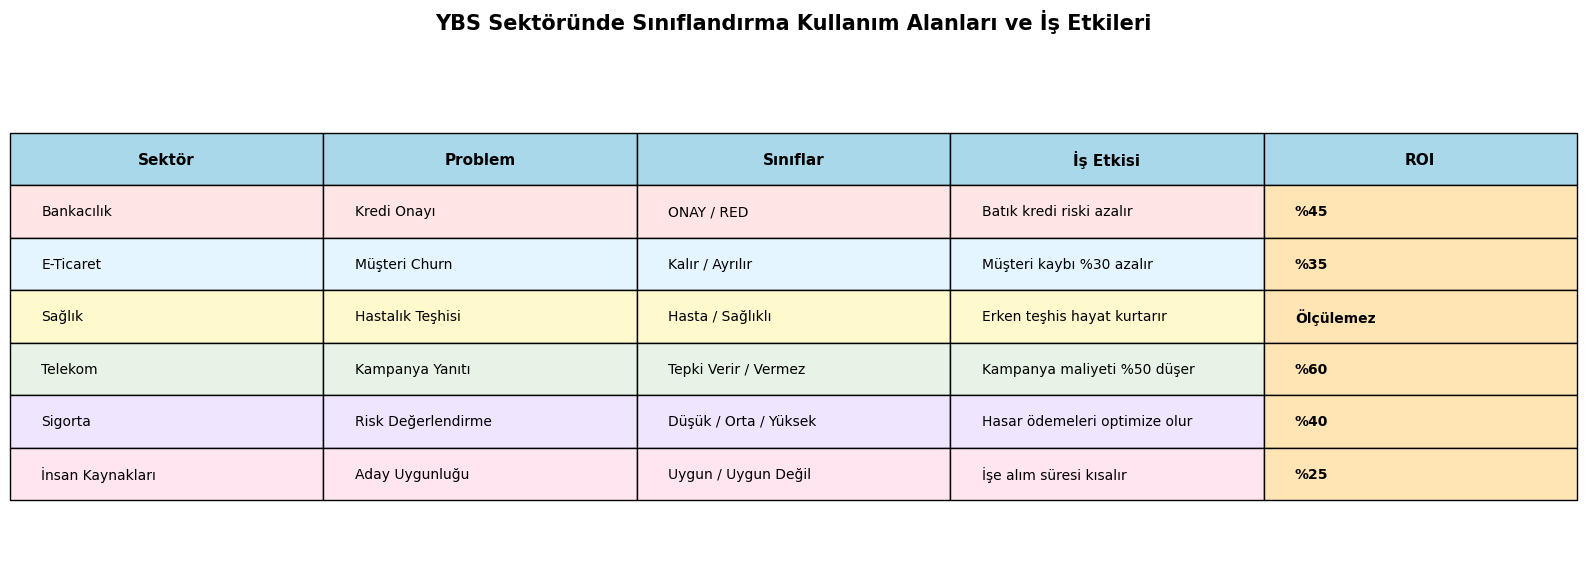


🎯 ÖNEMLİ ÇIKARIM:
• Sınıflandırma, YBS'de stratejik kararların temel taşıdır
• Her sektörde farklı bir problem, aynı metodoloji
• Doğru model + Doğru metrik = İş değeri
• ROI (Return on Investment) her zaman ölçülmelidir!


In [6]:
# İş dünyası sınıflandırma örnekleri
ybs_ornekleri = {
    'Sektör': ['Bankacılık', 'E-Ticaret', 'Sağlık', 'Telekom', 'Sigorta', 'İnsan Kaynakları'],
    'Problem': [
        'Kredi Onayı',
        'Müşteri Churn',
        'Hastalık Teşhisi',
        'Kampanya Yanıtı',
        'Risk Değerlendirme',
        'Aday Uygunluğu'
    ],
    'Sınıflar': [
        'ONAY / RED',
        'Kalır / Ayrılır',
        'Hasta / Sağlıklı',
        'Tepki Verir / Vermez',
        'Düşük / Orta / Yüksek',
        'Uygun / Uygun Değil'
    ],
    'İş Etkisi': [
        'Batık kredi riski azalır',
        'Müşteri kaybı %30 azalır',
        'Erken teşhis hayat kurtarır',
        'Kampanya maliyeti %50 düşer',
        'Hasar ödemeleri optimize olur',
        'İşe alım süresi kısalır'
    ],
    'ROI': ['%45', '%35', 'Ölçülemez', '%60', '%40', '%25']
}

df_ybs = pd.DataFrame(ybs_ornekleri)

# Görselleştirme
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df_ybs.values, 
                colLabels=df_ybs.columns,
                cellLoc='left', 
                loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.8)

# Renklendirme
colors = ['#FFE5E5', '#E5F5FF', '#FFFACD', '#E6F3E6', '#F0E5FF', '#FFE5F0']

# Header
for i in range(len(df_ybs.columns)):
    table[(0, i)].set_facecolor('#A8D8EA')
    table[(0, i)].set_text_props(weight='bold', size=11)

# Satırlar
for row in range(1, len(df_ybs) + 1):
    for col in range(len(df_ybs.columns)):
        table[(row, col)].set_facecolor(colors[row-1])
    # ROI sütununu vurgula
    table[(row, 4)].set_text_props(weight='bold')
    table[(row, 4)].set_facecolor('#FFE5B4')

plt.title('YBS Sektöründe Sınıflandırma Kullanım Alanları ve İş Etkileri', 
         fontsize=15, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🎯 ÖNEMLİ ÇIKARIM:")
print("• Sınıflandırma, YBS'de stratejik kararların temel taşıdır")
print("• Her sektörde farklı bir problem, aynı metodoloji")
print("• Doğru model + Doğru metrik = İş değeri")
print("• ROI (Return on Investment) her zaman ölçülmelidir!")

## 🎯 **ADIM 2: İkili Sınıflandırma ve Veri Hazırlığı**

### **2.1 Binary Classification (İkili Sınıflandırma) Nedir?**

**İkili sınıflandırma**, bir veri noktasının iki sınıftan birine atandığı makine öğrenmesi problemidir.

**Temel Özellikler:**
- 📌 Sadece **iki sınıf** vardır (örn: Evet/Hayır, 0/1, Pozitif/Negatif)
- 📌 Her örnek mutlaka bu iki sınıftan birine aittir
- 📌 Çıktı genellikle **0** veya **1** olarak kodlanır
- 📌 Model, bir örnekğin sınıf 1'e ait olma **olasılığını** üretir

In [7]:
# İkili sınıflandırma konseptini görselleştirelim
from IPython.display import display, Markdown

mermaid_code = '''
```mermaid
graph LR
    A["📋 Kredi Başvurusu<br/><b>Giriş Verileri</b><br/>• Gelir<br/>• Kredi Notu<br/>• Yaş<br/>• Borç"] --> B{"🤖 İkili Sınıflandırma<br/>Modeli<br/><i>Binary Classifier</i>"}
    
    B --> C["✅ SINIF 1<br/><b>ONAY</b><br/>Etiket: 1<br/>Olasılık > 0.5"]
    B --> D["❌ SINIF 0<br/><b>RED</b><br/>Etiket: 0<br/>Olasılık ≤ 0.5"]
    
    style A fill:#E8F4F8,stroke:#333,stroke-width:2px,color:#000
    style B fill:#FFE5B4,stroke:#333,stroke-width:3px,color:#000
    style C fill:#C6E9C6,stroke:#2E7D32,stroke-width:2px,color:#000
    style D fill:#F5C2C7,stroke:#C62828,stroke-width:2px,color:#000
```
'''

display(Markdown(mermaid_code))

print("\n💡 ÖNEMLİ KAVRAMLAR:")
print("\n1️⃣ SINIF ETİKETLERİ:")
print("   • Sınıf 0 (Negatif Sınıf): RED, Hayır, Sağlıklı, Spam Değil")
print("   • Sınıf 1 (Pozitif Sınıf): ONAY, Evet, Hasta, Spam")
print("\n2️⃣ OLASLIK YORUMLAMA:")
print("   • Model çıktısı: 0 ile 1 arasında bir sayı")
print("   • 0.85 → '%85 olasılıkla Sınıf 1'e ait'")
print("   • 0.20 → '%20 olasılıkla Sınıf 1'e ait' → Sınıf 0 atanır")
print("\n3️⃣ KARAR EŞİĞİ (Threshold):")
print("   • Varsayılan: 0.5")
print("   • P(Sınıf=1) > 0.5 → Sınıf 1")
print("   • P(Sınıf=1) ≤ 0.5 → Sınıf 0")
print("   • İş ihtiyacına göre değiştirilebilir (örn: 0.3, 0.7)")


```mermaid
graph LR
    A["📋 Kredi Başvurusu<br/><b>Giriş Verileri</b><br/>• Gelir<br/>• Kredi Notu<br/>• Yaş<br/>• Borç"] --> B{"🤖 İkili Sınıflandırma<br/>Modeli<br/><i>Binary Classifier</i>"}

    B --> C["✅ SINIF 1<br/><b>ONAY</b><br/>Etiket: 1<br/>Olasılık > 0.5"]
    B --> D["❌ SINIF 0<br/><b>RED</b><br/>Etiket: 0<br/>Olasılık ≤ 0.5"]

    style A fill:#E8F4F8,stroke:#333,stroke-width:2px,color:#000
    style B fill:#FFE5B4,stroke:#333,stroke-width:3px,color:#000
    style C fill:#C6E9C6,stroke:#2E7D32,stroke-width:2px,color:#000
    style D fill:#F5C2C7,stroke:#C62828,stroke-width:2px,color:#000
```



💡 ÖNEMLİ KAVRAMLAR:

1️⃣ SINIF ETİKETLERİ:
   • Sınıf 0 (Negatif Sınıf): RED, Hayır, Sağlıklı, Spam Değil
   • Sınıf 1 (Pozitif Sınıf): ONAY, Evet, Hasta, Spam

2️⃣ OLASLIK YORUMLAMA:
   • Model çıktısı: 0 ile 1 arasında bir sayı
   • 0.85 → '%85 olasılıkla Sınıf 1'e ait'
   • 0.20 → '%20 olasılıkla Sınıf 1'e ait' → Sınıf 0 atanır

3️⃣ KARAR EŞİĞİ (Threshold):
   • Varsayılan: 0.5
   • P(Sınıf=1) > 0.5 → Sınıf 1
   • P(Sınıf=1) ≤ 0.5 → Sınıf 0
   • İş ihtiyacına göre değiştirilebilir (örn: 0.3, 0.7)


### **2.2 Gerçekçi Banka Kredi Veri Seti Oluşturma**

Şimdi bir banka için gerçekçi bir kredi başvuru veri seti oluşturalım. 

**Veri Setimiz Şunları İçerecek:**
- 🎂 **Yaş**: Müşterinin yaşı (18-70 arası)
- 💰 **Yıllık Gelir**: TL cinsinden (20,000 - 250,000 arası)
- 📊 **Kredi Notu**: FICO tarzı skor (300-900 arası)
- 💳 **Mevcut Borç**: TL cinsinden toplam borç
- 👔 **Çalışma Süresi**: Mevcut işyerinde kaç yıl (0-40 yıl)
- 🏠 **Ev Sahibi**: Ev sahibi mi? (0: Hayır, 1: Evet)
- 🎯 **Kredi Onayı**: Hedef değişken (0: RED, 1: ONAY)

In [8]:
# Gerçekçi banka kredi veri seti oluşturma
np.random.seed(42)

# Veri seti boyutu
n_samples = 1000

# Bağımsız değişkenler (features) oluşturma
yas = np.random.randint(18, 71, n_samples)
yillik_gelir = np.random.randint(20000, 250000, n_samples)
kredi_notu = np.random.randint(300, 901, n_samples)
mevcut_borc = np.random.randint(0, 150000, n_samples)
calisma_suresi = np.random.randint(0, 41, n_samples)
ev_sahibi = np.random.choice([0, 1], n_samples, p=[0.4, 0.6])  # %60 ev sahibi

# Gerçekçi bir karar fonksiyonu oluşturalım
# Kredi onayı için risk skoru hesaplama (mantıklı bir formül)
def kredi_karar_ver(yas, gelir, kredi_notu, borc, calisma_suresi, ev_sahibi):
    """
    Gerçekçi bir kredi karar fonksiyonu
    
    Mantık:
    - Yüksek kredi notu → Olumlu etki
    - Yüksek gelir → Olumlu etki
    - Yüksek borç → Olumsuz etki
    - Uzun çalışma süresi → Olumlu etki
    - Ev sahibi olmak → Olumlu etki
    """
    # Risk skoru hesaplama (0-1 arası normalize)
    risk_skoru = (
        (kredi_notu / 900) * 0.35 +           # %35 ağırlık - En önemli faktör
        (gelir / 250000) * 0.25 +              # %25 ağırlık
        (1 - borc / 150000) * 0.20 +           # %20 ağırlık (düşük borç iyi)
        (calisma_suresi / 40) * 0.10 +         # %10 ağırlık
        (ev_sahibi) * 0.10                     # %10 ağırlık
    )
    
    # Yaş faktörü (25-55 arası ideal)
    if 25 <= yas <= 55:
        risk_skoru += 0.05
    elif yas < 25 or yas > 65:
        risk_skoru -= 0.05
    
    # Eşik değer belirleme ve biraz rastgelelik ekle (gerçek hayat belirsizliği)
    esik = 0.5 + np.random.normal(0, 0.1)  # 0.5 etrafında değişken eşik
    
    return 1 if risk_skoru > esik else 0

# Her müşteri için kredi kararı ver
kredi_onayi = np.array([
    kredi_karar_ver(yas[i], yillik_gelir[i], kredi_notu[i], 
                    mevcut_borc[i], calisma_suresi[i], ev_sahibi[i])
    for i in range(n_samples)
])

# DataFrame oluşturma
df_kredi = pd.DataFrame({
    'Yaş': yas,
    'Yıllık_Gelir': yillik_gelir,
    'Kredi_Notu': kredi_notu,
    'Mevcut_Borç': mevcut_borc,
    'Çalışma_Süresi': calisma_suresi,
    'Ev_Sahibi': ev_sahibi,
    'Kredi_Onayı': kredi_onayi
})

# Veri seti bilgileri
print("✅ Banka Kredi Veri Seti Oluşturuldu!")
print(f"\n📊 Veri Seti Boyutu: {df_kredi.shape[0]} satır, {df_kredi.shape[1]} sütun")
print(f"\n🎯 Hedef Değişken Dağılımı:")
print(f"   • RED (0): {(df_kredi['Kredi_Onayı'] == 0).sum()} başvuru ({(df_kredi['Kredi_Onayı'] == 0).sum()/len(df_kredi)*100:.1f}%)")
print(f"   • ONAY (1): {(df_kredi['Kredi_Onayı'] == 1).sum()} başvuru ({(df_kredi['Kredi_Onayı'] == 1).sum()/len(df_kredi)*100:.1f}%)")

# İlk 10 satırı göster
print("\n📋 İlk 10 Müşteri:")
df_kredi.head(10)

✅ Banka Kredi Veri Seti Oluşturuldu!

📊 Veri Seti Boyutu: 1000 satır, 7 sütun

🎯 Hedef Değişken Dağılımı:
   • RED (0): 292 başvuru (29.2%)
   • ONAY (1): 708 başvuru (70.8%)

📋 İlk 10 Müşteri:


,Yaş,Yıllık_Gelir,Kredi_Notu,Mevcut_Borç,Çalışma_Süresi,Ev_Sahibi,Kredi_Onayı
0,56,151374,569,63870,0,1,1
1,69,233630,584,9283,16,0,1
2,46,151127,526,78707,2,1,1
3,32,131317,680,5774,25,1,1
4,60,159789,759,142055,14,1,1
5,25,147449,306,96468,35,1,1
6,38,48699,328,96334,31,1,0
7,56,93686,332,18133,31,1,0
8,36,87661,378,146011,3,0,0
9,40,64247,758,781,17,0,1


### **2.3 Keşifsel Veri Analizi (EDA)**

Modelleme yapmadan önce verimizi tanımamız gerekiyor. **YBS perspektifinden**, veri analizi iş kararlarının temelidir.

In [9]:
# Temel istatistiksel özet
print("📊 VERİ SETİ İSTATİSTİKLERİ:\n")
print(df_kredi.describe())

print("\n" + "="*70)
print("\n🔍 EKSİK VERİ KONTROLÜ:")
print(df_kredi.isnull().sum())

print("\n" + "="*70)
print("\n📈 VERİ TİPLERİ:")
print(df_kredi.dtypes)

📊 VERİ SETİ İSTATİSTİKLERİ:

               Yaş   Yıllık_Gelir   Kredi_Notu    Mevcut_Borç  Çalışma_Süresi  \
count  1000.000000    1000.000000  1000.000000    1000.000000     1000.000000   
mean     44.385000  134545.035000   604.095000   74312.379000       19.974000   
std      15.321669   64836.496524   174.568399   44003.943106       11.606293   
min      18.000000   20126.000000   300.000000     138.000000        0.000000   
25%      31.750000   80128.250000   451.750000   35046.750000       10.000000   
50%      45.000000  138283.000000   604.000000   74150.500000       20.000000   
75%      57.000000  187319.500000   755.250000  112181.000000       30.000000   
max      70.000000  249947.000000   900.000000  149960.000000       40.000000   

         Ev_Sahibi  Kredi_Onayı  
count  1000.000000   1000.00000  
mean      0.564000      0.70800  
std       0.496135      0.45491  
min       0.000000      0.00000  
25%       0.000000      0.00000  
50%       1.000000      1.00000  
75%

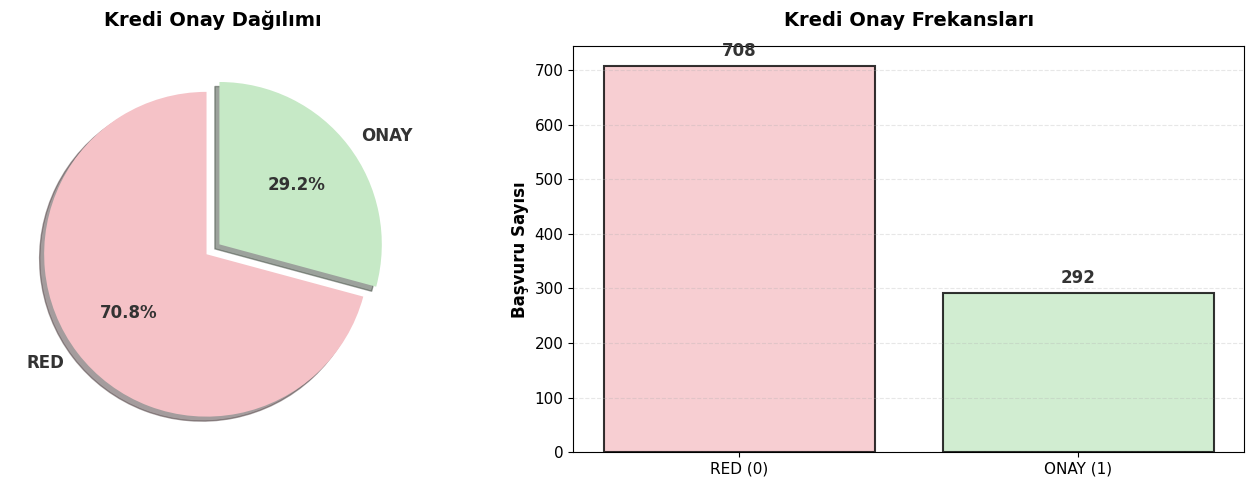


⚖️ VERİ SETİ DENGESİ:
⚠️ Veri seti DENGESİZ (RED: 29.2%, ONAY: 70.8%)
   → Class imbalance teknikleri gerekebilir (SMOTE, class weights)


In [10]:
# Hedef değişken dağılımını görselleştir
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pasta grafiği
onay_counts = df_kredi['Kredi_Onayı'].value_counts()
colors_pie = ['#F5C2C7', '#C6E9C6']  # Red için kırmızı, Onay için yeşil
explode = (0.05, 0.05)

axes[0].pie(onay_counts, labels=['RED', 'ONAY'], autopct='%1.1f%%', 
           colors=colors_pie, explode=explode, shadow=True, startangle=90,
           textprops={'fontsize': 12, 'weight': 'bold', 'color': '#333'})
axes[0].set_title('Kredi Onay Dağılımı', fontsize=14, weight='bold', pad=15)

# Çubuk grafiği
axes[1].bar(['RED (0)', 'ONAY (1)'], onay_counts.values, 
           color=colors_pie, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('Başvuru Sayısı', fontsize=12, weight='bold')
axes[1].set_title('Kredi Onay Frekansları', fontsize=14, weight='bold', pad=15)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Değerleri çubukların üstüne yaz
for i, v in enumerate(onay_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', va='bottom', 
                fontsize=12, weight='bold', color='#333')

plt.tight_layout()
plt.show()

# Denge kontrolü
red_oran = (df_kredi['Kredi_Onayı'] == 0).sum() / len(df_kredi)
onay_oran = (df_kredi['Kredi_Onayı'] == 1).sum() / len(df_kredi)

print("\n⚖️ VERİ SETİ DENGESİ:")
if 0.4 <= red_oran <= 0.6:
    print("✅ Veri seti DENGELİ (RED: {:.1%}, ONAY: {:.1%})".format(red_oran, onay_oran))
    print("   → Model eğitimi için ideal durum!")
else:
    print("⚠️ Veri seti DENGESİZ (RED: {:.1%}, ONAY: {:.1%})".format(red_oran, onay_oran))
    print("   → Class imbalance teknikleri gerekebilir (SMOTE, class weights)")

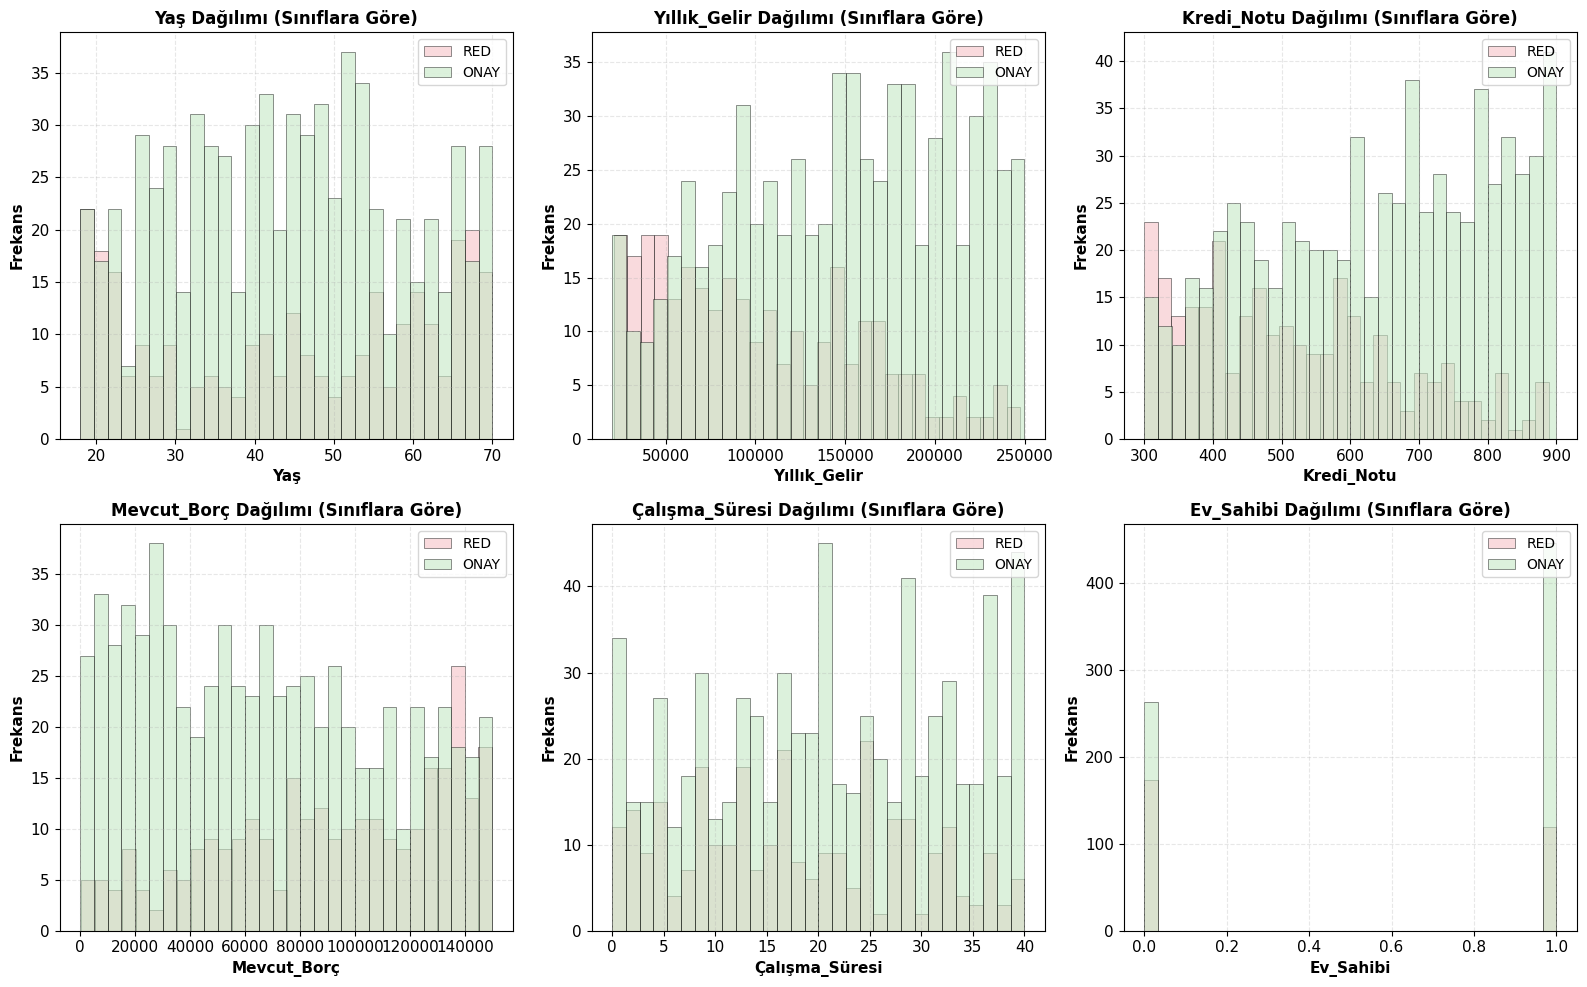


🔍 GÖZLEMLER:

1️⃣ Kredi Notu: ONAY alan müşterilerde belirgin şekilde daha yüksek
2️⃣ Yıllık Gelir: ONAY grubunda sağa kayık (daha yüksek gelir)
3️⃣ Mevcut Borç: RED grubunda daha yüksek borç seviyeleri
4️⃣ Bu farklılıklar, özelliklerin ayırt edici gücünü gösterir!


In [11]:
# Sayısal değişkenlerin dağılımlarını inceleyelim (Sınıflara göre)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

# Pastel renkler - ONAY ve RED için
colors_dist = ['#F5C2C7', '#C6E9C6']
features = ['Yaş', 'Yıllık_Gelir', 'Kredi_Notu', 'Mevcut_Borç', 'Çalışma_Süresi', 'Ev_Sahibi']

for idx, feature in enumerate(features):
    # RED (0) ve ONAY (1) için ayrı histogramlar
    axes[idx].hist(df_kredi[df_kredi['Kredi_Onayı']==0][feature], 
                  bins=30, alpha=0.6, label='RED', color=colors_dist[0], 
                  edgecolor='black', linewidth=0.5)
    axes[idx].hist(df_kredi[df_kredi['Kredi_Onayı']==1][feature], 
                  bins=30, alpha=0.6, label='ONAY', color=colors_dist[1], 
                  edgecolor='black', linewidth=0.5)
    
    axes[idx].set_xlabel(feature, fontsize=11, weight='bold')
    axes[idx].set_ylabel('Frekans', fontsize=11, weight='bold')
    axes[idx].set_title(f'{feature} Dağılımı (Sınıflara Göre)', fontsize=12, weight='bold')
    axes[idx].legend(loc='upper right', fontsize=10)
    axes[idx].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🔍 GÖZLEMLER:")
print("\n1️⃣ Kredi Notu: ONAY alan müşterilerde belirgin şekilde daha yüksek")
print("2️⃣ Yıllık Gelir: ONAY grubunda sağa kayık (daha yüksek gelir)")
print("3️⃣ Mevcut Borç: RED grubunda daha yüksek borç seviyeleri")
print("4️⃣ Bu farklılıklar, özelliklerin ayırt edici gücünü gösterir!")

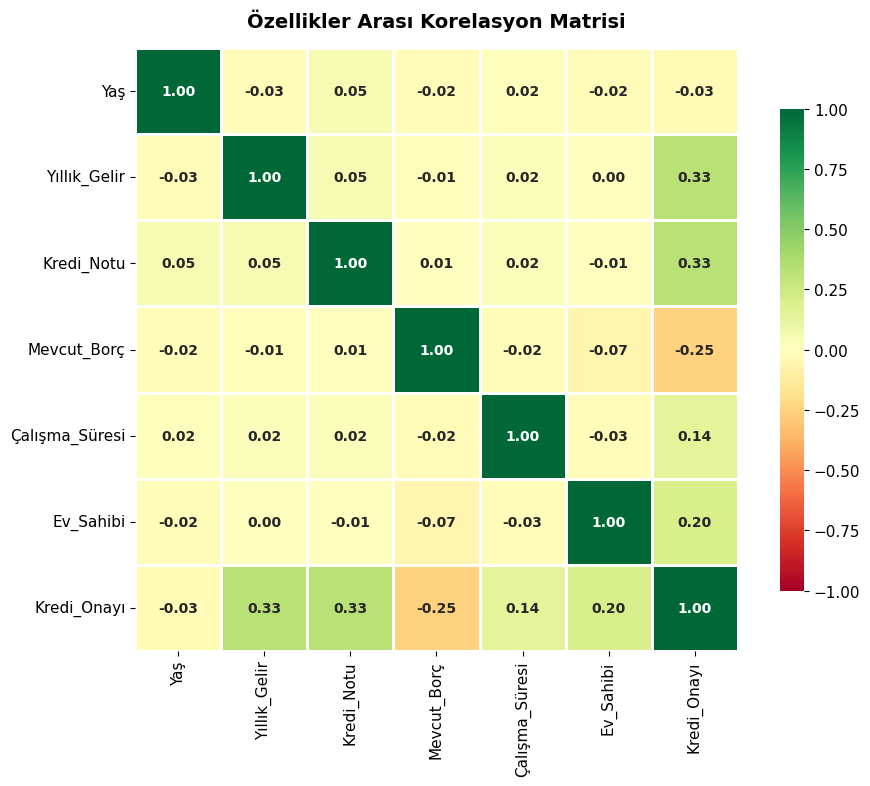


🎯 HEdef DEĞİŞKEN (Kredi_Onayı) İLE KORELASYONLAR:
🟡 Orta | Yıllık_Gelir        : +0.326 (Pozitif)
🟡 Orta | Kredi_Notu          : +0.325 (Pozitif)
🟢 Zayıf  | Ev_Sahibi           : +0.203
🟢 Zayıf  | Çalışma_Süresi      : +0.137
🟢 Zayıf  | Yaş                 : -0.032
🟢 Zayıf  | Mevcut_Borç         : -0.251

💡 YORUM:
• Pozitif korelasyon: Özellik arttıkça ONAY olasılığı artar
• Negatif korelasyon: Özellik arttıkça RED olasılığı artar
• |Korelasyon| > 0.5: Model için çok önemli özellik


In [12]:
# Korelasyon matrisi - Özellikler arasındaki ilişkiler
fig, ax = plt.subplots(figsize=(10, 8))

# Korelasyon hesaplama
correlation_matrix = df_kredi.corr()

# Pastel renkli ısı haritası
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn', 
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
           annot_kws={'size': 10, 'weight': 'bold'}, ax=ax,
           vmin=-1, vmax=1)

ax.set_title('Özellikler Arası Korelasyon Matrisi', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

# Hedef değişken ile en yüksek korelasyona sahip özellikler
target_corr = correlation_matrix['Kredi_Onayı'].sort_values(ascending=False)

print("\n🎯 HEdef DEĞİŞKEN (Kredi_Onayı) İLE KORELASYONLAR:")
print("="*60)
for feature, corr_value in target_corr.items():
    if feature != 'Kredi_Onayı':
        if abs(corr_value) > 0.3:
            strength = "🔴 Güçlü" if abs(corr_value) > 0.5 else "🟡 Orta"
            direction = "Pozitif" if corr_value > 0 else "Negatif"
            print(f"{strength} | {feature:20s}: {corr_value:+.3f} ({direction})")
        else:
            print(f"🟢 Zayıf  | {feature:20s}: {corr_value:+.3f}")

print("\n💡 YORUM:")
print("• Pozitif korelasyon: Özellik arttıkça ONAY olasılığı artar")
print("• Negatif korelasyon: Özellik arttıkça RED olasılığı artar")
print("• |Korelasyon| > 0.5: Model için çok önemli özellik")

### 2.4 Veri Ön İşleme ve Eğitim/Test Ayrımı

Modelleme öncesi **kritik adımlar**:
1. 📊 **Feature Scaling (Özellik Ölçeklendirme)**: Farklı ölçeklerdeki özellikleri normalize etme
2. ✂️ **Train-Test Split**: Veriyi eğitim ve test setlerine ayırma
3. 🎯 **X ve y Ayrımı**: Bağımsız değişkenler (X) ve hedef değişken (y)

In [13]:
# Veri hazırlığı
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. X (Bağımsız değişkenler) ve y (Hedef değişken) ayrımı
X = df_kredi.drop('Kredi_Onayı', axis=1)
y = df_kredi['Kredi_Onayı']

print("📊 VERİ SETİ YAPISI:")
print(f"• Bağımsız değişkenler (X): {X.shape}")
print(f"• Hedef değişken (y): {y.shape}")
print(f"\n• Özellikler: {list(X.columns)}")

# 2. Train-Test Split (80% eğitim, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # %20 test verisi
    random_state=42,    # Tekrarlanabilirlik için
    stratify=y          # Sınıf oranlarını koru
)

print("\n✂️ EĞİTİM/TEST AYIRIMI:")
print(f"• Eğitim seti: {X_train.shape[0]} örnek ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"• Test seti: {X_test.shape[0]} örnek ({X_test.shape[0]/len(X)*100:.0f}%)")

# Sınıf dağılımlarını kontrol et
print("\n⚖️ SINIF DAĞILIMLARI:")
print(f"Eğitim - RED: {(y_train==0).sum()}, ONAY: {(y_train==1).sum()}")
print(f"Test    - RED: {(y_test==0).sum()}, ONAY: {(y_test==1).sum()}")

# 3. Feature Scaling (Standardization)
# Her özelliği ortalama=0, standart sapma=1 olacak şekilde ölçeklendir
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Eğitim verisinden öğren ve dönüştür
X_test_scaled = scaler.transform(X_test)         # Test verisini aynı parametrelerle dönüştür

# DataFrame'e geri çevir (görselleştirme için)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n📐 FEATURE SCALING TAMAMLANDI:")
print("• Standardization (z-score normalization) uygulandı")
print("• Her özellik: μ=0, σ=1")
print(f"\n• Ölçeklenmiş eğitim verisi: {X_train_scaled.shape}")
print(f"• Ölçeklenmiş test verisi: {X_test_scaled.shape}")

📊 VERİ SETİ YAPISI:
• Bağımsız değişkenler (X): (1000, 6)
• Hedef değişken (y): (1000,)

• Özellikler: ['Yaş', 'Yıllık_Gelir', 'Kredi_Notu', 'Mevcut_Borç', 'Çalışma_Süresi', 'Ev_Sahibi']

✂️ EĞİTİM/TEST AYIRIMI:
• Eğitim seti: 800 örnek (80%)
• Test seti: 200 örnek (20%)

⚖️ SINIF DAĞILIMLARI:
Eğitim - RED: 234, ONAY: 566
Test    - RED: 58, ONAY: 142

📐 FEATURE SCALING TAMAMLANDI:
• Standardization (z-score normalization) uygulandı
• Her özellik: μ=0, σ=1

• Ölçeklenmiş eğitim verisi: (800, 6)
• Ölçeklenmiş test verisi: (200, 6)


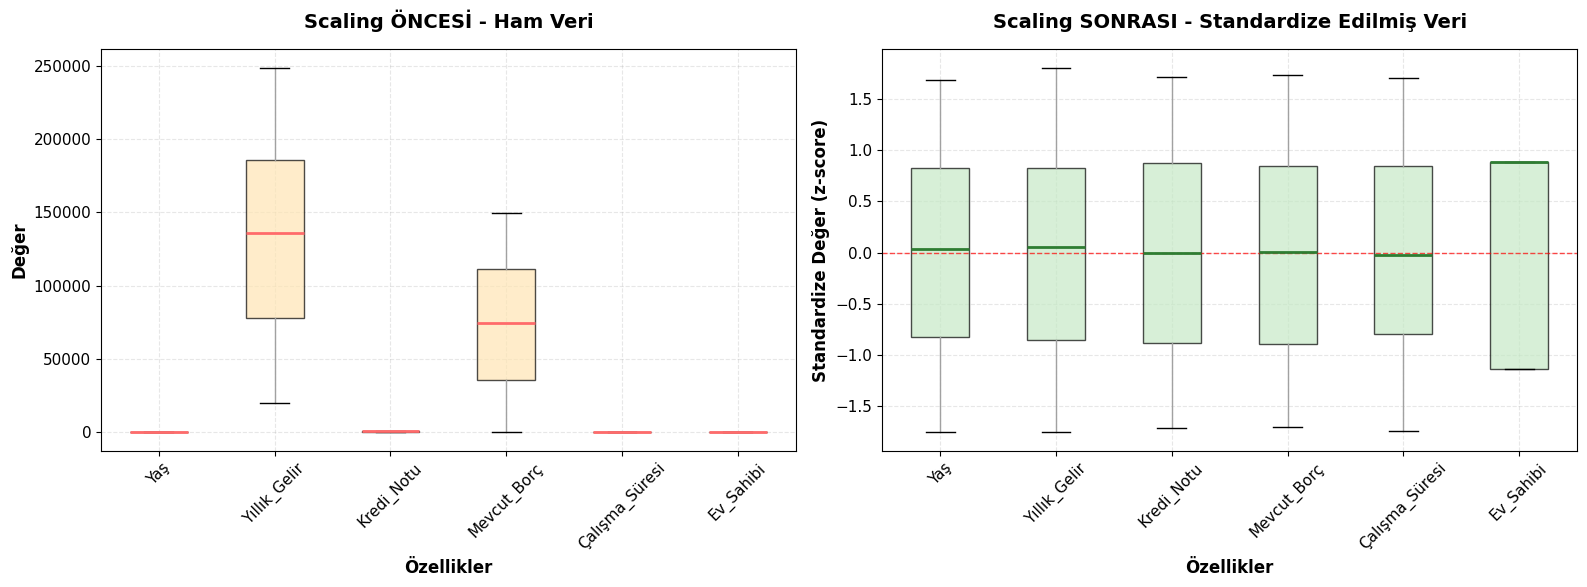


❓ NEDEN FEATURE SCALING GEREKLİ?

1️⃣ FARKLI ÖLÇEKLERDEKİ ÖZELLİKLER:
   • Yıllık Gelir: 20126 - 248892 TL
   • Yaş: 18 - 70 yıl
   • Ev Sahibi: 0 - 1 (ikili)

2️⃣ MODEL PERFORMANSI:
   • Yüksek değerli özellikler modeli domine edebilir
   • Gradient descent daha hızlı yakınsarşar
   • Katsayılar karşılaştırılabilir hale gelir

3️⃣ YBS PERSPEKTİFİ:
   • Farklı birimlerde veri (TL, yıl, puan)
   • Standardizasyon = Adil karşılaştırma


In [14]:
# Scaling öncesi ve sonrası karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Öncesi - Ham veri
X_train.boxplot(ax=axes[0], patch_artist=True, 
               boxprops=dict(facecolor='#FFE5B4', alpha=0.7),
               medianprops=dict(color='#FF6B6B', linewidth=2))
axes[0].set_title('Scaling ÖNCESİ - Ham Veri', fontsize=14, weight='bold', pad=15)
axes[0].set_ylabel('Değer', fontsize=12, weight='bold')
axes[0].set_xlabel('Özellikler', fontsize=12, weight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, linestyle='--')

# Sonrası - Ölçeklenmiş veri
X_train_scaled_df.boxplot(ax=axes[1], patch_artist=True,
                          boxprops=dict(facecolor='#C6E9C6', alpha=0.7),
                          medianprops=dict(color='#2E7D32', linewidth=2))
axes[1].set_title('Scaling SONRASI - Standardize Edilmiş Veri', fontsize=14, weight='bold', pad=15)
axes[1].set_ylabel('Standardize Değer (z-score)', fontsize=12, weight='bold')
axes[1].set_xlabel('Özellikler', fontsize=12, weight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()

print("\n❓ NEDEN FEATURE SCALING GEREKLİ?")
print("\n1️⃣ FARKLI ÖLÇEKLERDEKİ ÖZELLİKLER:")
print(f"   • Yıllık Gelir: {X_train['Yıllık_Gelir'].min():.0f} - {X_train['Yıllık_Gelir'].max():.0f} TL")
print(f"   • Yaş: {X_train['Yaş'].min():.0f} - {X_train['Yaş'].max():.0f} yıl")
print(f"   • Ev Sahibi: {X_train['Ev_Sahibi'].min():.0f} - {X_train['Ev_Sahibi'].max():.0f} (ikili)")
print("\n2️⃣ MODEL PERFORMANSI:")
print("   • Yüksek değerli özellikler modeli domine edebilir")
print("   • Gradient descent daha hızlı yakınsarşar")
print("   • Katsayılar karşılaştırılabilir hale gelir")
print("\n3️⃣ YBS PERSPEKTİFİ:")
print("   • Farklı birimlerde veri (TL, yıl, puan)")
print("   • Standardizasyon = Adil karşılaştırma")

## 🎯 **ADIM 3: Lojistik Regresyon Teorisi ve Sigmoid Fonksiyonu**

### **3.1 Lojistik Regresyon Nedir?**

**Lojistik Regresyon**, isminde "regresyon" geçse de aslında bir **sınıflandırma** algoritmasıdır.

**📌 Temel Fikir:**

```
Lineer Kombinasyon → Sigmoid Fonksiyonu → Olasılık (0-1 arası) → Sınıf Kararı
```

**Matematiksel Formül:**

$$ P(y=1|X) = \sigma(z) = \frac{1}{1 + e^{-z}} $$

Burada:
- $z = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + ... + \theta_n x_n$ (lineer kombinasyon)
- $\sigma(z)$ = Sigmoid fonksiyonu
- $P(y=1|X)$ = X özelliklerine sahip bir örneğin Sınıf 1'e ait olma olasılığı
- $\theta$ = Model parametreleri (ağırlıklar)

In [15]:
# Lojistik Regresyon akışını Mermaid ile görselleştirelim
from IPython.display import display, Markdown

mermaid_code = '''
```mermaid
graph LR
    A["📊 Girdi Özellikleri<br/><b>X</b><br/>Gelir, Yaş, Kredi Notu..."] --> B["➕ Lineer Kombinasyon<br/><b>z = θ₀ + θ₁x₁ + θ₂x₂ + ...</b><br/>Sonuç: -∞ ile +∞ arası"]
    
    B --> C["🔄 Sigmoid Fonksiyonu<br/><b>σ(z) = 1/(1+e⁻ᶻ)</b><br/>Dönüşüm"]
    
    C --> D["📈 Olasılık<br/><b>P(y=1|X)</b><br/>0 ile 1 arası"]
    
    D --> E{"⚖️ Karar Eşiği<br/>P > 0.5?"}
    
    E -->|Evet| F["✅ SINIF 1<br/><b>ONAY</b>"]
    E -->|Hayır| G["❌ SINIF 0<br/><b>RED</b>"]
    
    style A fill:#E8F4F8,stroke:#333,stroke-width:2px,color:#000
    style B fill:#FFE5B4,stroke:#333,stroke-width:2px,color:#000
    style C fill:#FFB6C1,stroke:#333,stroke-width:3px,color:#000
    style D fill:#DDA0DD,stroke:#333,stroke-width:2px,color:#000
    style E fill:#F0E68C,stroke:#333,stroke-width:2px,color:#000
    style F fill:#C6E9C6,stroke:#2E7D32,stroke-width:2px,color:#000
    style G fill:#F5C2C7,stroke:#C62828,stroke-width:2px,color:#000
```
'''

display(Markdown(mermaid_code))

print("\n💡 ÖNEMLİ NOKTALAR:")
print("\n1️⃣ Lineer kombinasyon (z) herhangi bir sayı olabilir:")
print("   • z = -100 (çok düşük risk)")
print("   • z = 0 (nötr)")
print("   • z = +100 (çok yüksek risk)")
print("\n2️⃣ Sigmoid bu değeri 0-1 arasına SIKIŞTIRIR:")
print("   • σ(-100) ≈ 0.0000... (neredeyse 0)")
print("   • σ(0) = 0.5 (tam ortada)")
print("   • σ(+100) ≈ 1.0000... (neredeyse 1)")
print("\n3️⃣ Artık bu değer OLASILIK gibi yorumlanabilir:")
print("   • 0.85 → '%85 olasılıkla ONAY'")
print("   • 0.15 → '%15 olasılıkla ONAY' → RED kararı")


```mermaid
graph LR
    A["📊 Girdi Özellikleri<br/><b>X</b><br/>Gelir, Yaş, Kredi Notu..."] --> B["➕ Lineer Kombinasyon<br/><b>z = θ₀ + θ₁x₁ + θ₂x₂ + ...</b><br/>Sonuç: -∞ ile +∞ arası"]

    B --> C["🔄 Sigmoid Fonksiyonu<br/><b>σ(z) = 1/(1+e⁻ᶻ)</b><br/>Dönüşüm"]

    C --> D["📈 Olasılık<br/><b>P(y=1|X)</b><br/>0 ile 1 arası"]

    D --> E{"⚖️ Karar Eşiği<br/>P > 0.5?"}

    E -->|Evet| F["✅ SINIF 1<br/><b>ONAY</b>"]
    E -->|Hayır| G["❌ SINIF 0<br/><b>RED</b>"]

    style A fill:#E8F4F8,stroke:#333,stroke-width:2px,color:#000
    style B fill:#FFE5B4,stroke:#333,stroke-width:2px,color:#000
    style C fill:#FFB6C1,stroke:#333,stroke-width:3px,color:#000
    style D fill:#DDA0DD,stroke:#333,stroke-width:2px,color:#000
    style E fill:#F0E68C,stroke:#333,stroke-width:2px,color:#000
    style F fill:#C6E9C6,stroke:#2E7D32,stroke-width:2px,color:#000
    style G fill:#F5C2C7,stroke:#C62828,stroke-width:2px,color:#000
```



💡 ÖNEMLİ NOKTALAR:

1️⃣ Lineer kombinasyon (z) herhangi bir sayı olabilir:
   • z = -100 (çok düşük risk)
   • z = 0 (nötr)
   • z = +100 (çok yüksek risk)

2️⃣ Sigmoid bu değeri 0-1 arasına SIKIŞTIRIR:
   • σ(-100) ≈ 0.0000... (neredeyse 0)
   • σ(0) = 0.5 (tam ortada)
   • σ(+100) ≈ 1.0000... (neredeyse 1)

3️⃣ Artık bu değer OLASILIK gibi yorumlanabilir:
   • 0.85 → '%85 olasılıkla ONAY'
   • 0.15 → '%15 olasılıkla ONAY' → RED kararı


### 3.2 **Sigmoid Fonksiyonu: Sihirli Dönüşüm**

**Sigmoid** (veya Lojistik) fonksiyonu, herhangi bir gerçek sayıyı 0 ile 1 arasına dönüştüren bir fonksiyondur.

**Matematiksel Tanım:**

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

**Önemli Özellikler:**
- 📌 **Tanım Kümesi:** $z \in (-\infty, +\infty)$
- 📌 **Görüntü Kümesi:** $\sigma(z) \in (0, 1)$
- 📌 **Simetrik:** $\sigma(-z) = 1 - \sigma(z)$
- 📌 **Orta Nokta:** $\sigma(0) = 0.5$
- 📌 **Türevi:** $\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$ → Gradient descent için önemli!

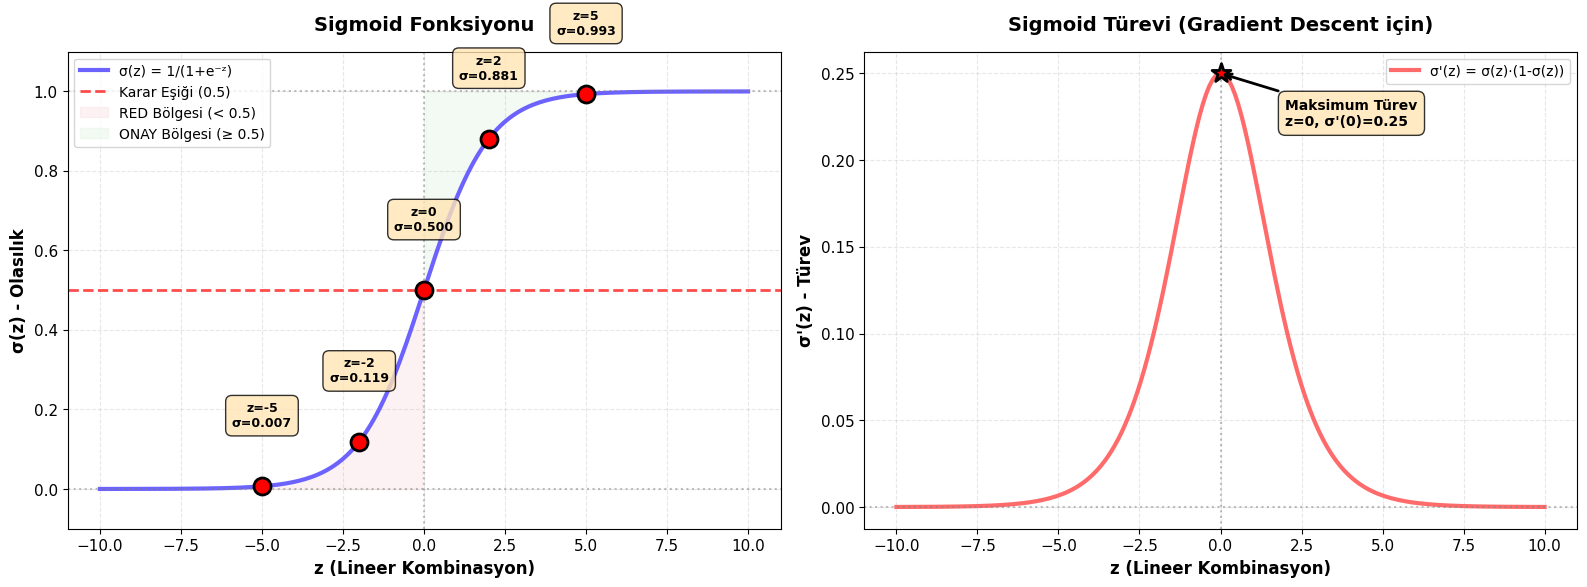


📊 SİGMOİD FONKSİYONU ÖRNEKLER:
    z |         σ(z) |        Olasılık |      Karar
------------------------------------------------------------
  -10 |   0.00004540 |          0.00% |      RED ❌
   -5 |   0.00669285 |          0.67% |      RED ❌
   -2 |   0.11920292 |         11.92% |      RED ❌
   -1 |   0.26894142 |         26.89% |      RED ❌
    0 |   0.50000000 |         50.00% |     ONAY ✅
    1 |   0.73105858 |         73.11% |     ONAY ✅
    2 |   0.88079708 |         88.08% |     ONAY ✅
    5 |   0.99330715 |         99.33% |     ONAY ✅
   10 |   0.99995460 |        100.00% |     ONAY ✅

💡 GÖZLEM:
• z → -∞ iken σ(z) → 0 (kesinlikle RED)
• z = 0 iken σ(z) = 0.5 (kararsız nokta)
• z → +∞ iken σ(z) → 1 (kesinlikle ONAY)
• z değeri 0'dan uzaklaştıkça karar daha NET!


In [16]:
# Sigmoid fonksiyonunu tanımlayalım
def sigmoid(z):
    """
    Sigmoid (Lojistik) fonksiyonu
    
    Parametreler:
    -----------
    z : float veya array
        Girdi değeri/değerleri
    
    Döndürür:
    ---------
    sigmoid : float veya array
        0 ile 1 arasında sigmoid çıktısı
    """
    return 1 / (1 + np.exp(-z))

# Test değerleri
z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol grafik: Sigmoid fonksiyonu
axes[0].plot(z_values, sigmoid_values, linewidth=3, color='#6C63FF', label='σ(z) = 1/(1+e⁻ᶻ)')
axes[0].axhline(y=0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Karar Eşiği (0.5)')
axes[0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[0].axhline(y=1, color='gray', linestyle=':', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle=':', alpha=0.5)

# Önemli noktaları işaretle
key_points_z = [-5, -2, 0, 2, 5]
key_points_sigmoid = sigmoid(np.array(key_points_z))

axes[0].scatter(key_points_z, key_points_sigmoid, s=150, c='red', 
               zorder=5, edgecolors='black', linewidth=2)

# Nokta etiketleri
for z, sig in zip(key_points_z, key_points_sigmoid):
    axes[0].annotate(f'z={z}\nσ={sig:.3f}', 
                    xy=(z, sig), xytext=(z, sig+0.15),
                    fontsize=9, ha='center', weight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFE5B4', alpha=0.8))

# Bölgeleri renklendir
axes[0].fill_between(z_values, 0, sigmoid_values, where=(sigmoid_values<0.5), 
                     alpha=0.2, color='#F5C2C7', label='RED Bölgesi (< 0.5)')
axes[0].fill_between(z_values, sigmoid_values, 1, where=(sigmoid_values>=0.5), 
                     alpha=0.2, color='#C6E9C6', label='ONAY Bölgesi (≥ 0.5)')

axes[0].set_xlabel('z (Lineer Kombinasyon)', fontsize=12, weight='bold')
axes[0].set_ylabel('σ(z) - Olasılık', fontsize=12, weight='bold')
axes[0].set_title('Sigmoid Fonksiyonu', fontsize=14, weight='bold', pad=15)
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_ylim(-0.1, 1.1)

# Sağ grafik: Sigmoid türevi
sigmoid_derivative = sigmoid_values * (1 - sigmoid_values)

axes[1].plot(z_values, sigmoid_derivative, linewidth=3, color='#FF6B6B', label="σ'(z) = σ(z)·(1-σ(z))")
axes[1].axvline(x=0, color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)

# Maksimum türev noktası (z=0'da)
axes[1].scatter([0], [0.25], s=200, c='red', zorder=5, 
               edgecolors='black', linewidth=2, marker='*')
axes[1].annotate('Maksimum Türev\nz=0, σ\'(0)=0.25', 
                xy=(0, 0.25), xytext=(2, 0.22),
                fontsize=10, weight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFE5B4', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

axes[1].set_xlabel('z (Lineer Kombinasyon)', fontsize=12, weight='bold')
axes[1].set_ylabel("σ'(z) - Türev", fontsize=12, weight='bold')
axes[1].set_title('Sigmoid Türevi (Gradient Descent için)', fontsize=14, weight='bold', pad=15)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n📊 SİGMOİD FONKSİYONU ÖRNEKLER:")
print("="*60)
test_z = [-10, -5, -2, -1, 0, 1, 2, 5, 10]
print(f"{'z':>5} | {'σ(z)':>12} | {'Olasılık':>15} | {'Karar':>10}")
print("-"*60)
for z in test_z:
    sig = sigmoid(z)
    karar = "ONAY ✅" if sig >= 0.5 else "RED ❌"
    print(f"{z:5d} | {sig:12.8f} | {sig*100:13.2f}% | {karar:>10}")

print("\n💡 GÖZLEM:")
print("• z → -∞ iken σ(z) → 0 (kesinlikle RED)")
print("• z = 0 iken σ(z) = 0.5 (kararsız nokta)")
print("• z → +∞ iken σ(z) → 1 (kesinlikle ONAY)")
print("• z değeri 0'dan uzaklaştıkça karar daha NET!")

### **3.3 Lineer vs Lojistik Regresyon: Görsel Karşılaştırma**

Şimdi gerçek verimizden tek bir özellik alalım (Kredi Notu) ve iki yaklaşımı karşılaştıralım.

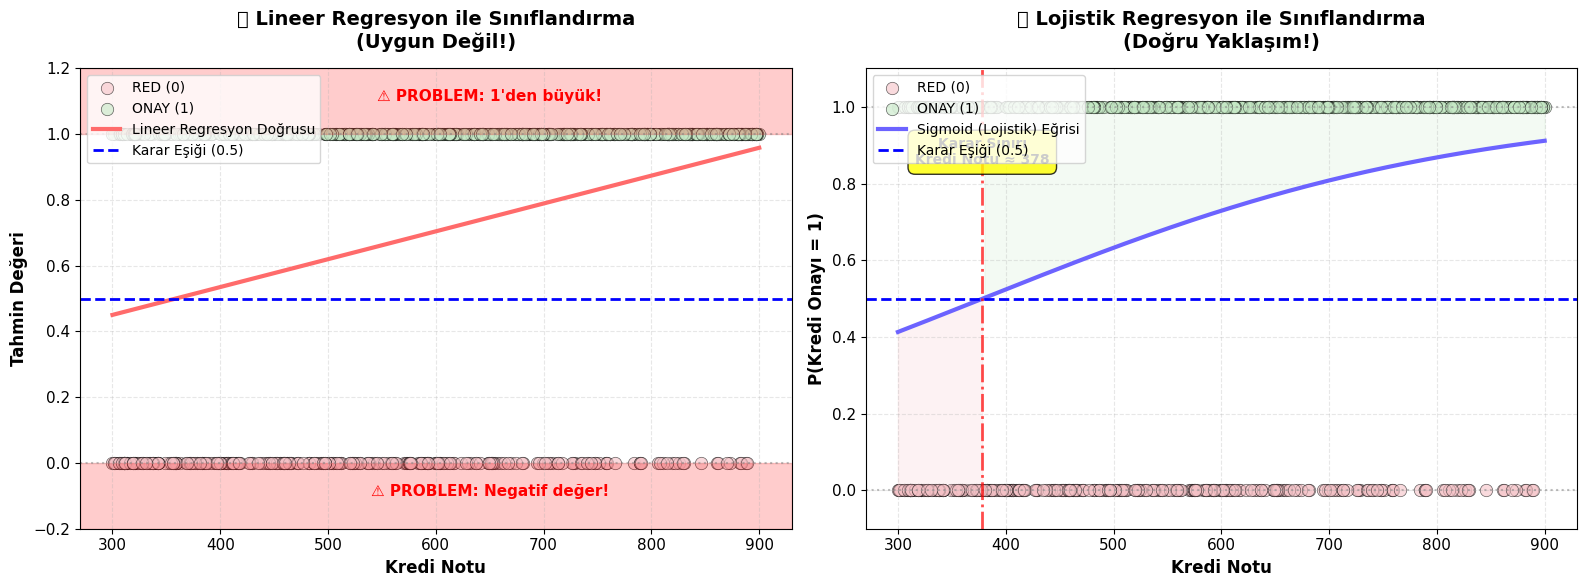


🔍 KARŞILAŞTIRMA SONUÇLARI:

❌ LİNEER REGRESYON PROBLEMLERI:
   • Minimum tahmin: 0.450 (0'dan küçük! ❌)
   • Maksimum tahmin: 0.959 (1'den büyük! ❌)
   • Çıktı olasılık olarak yorumlanamaz
   • Aykırı değerlere çok hassas

✅ LOJİSTİK REGRESYON AVANTAJLARI:
   • Minimum tahmin: 0.413 (0'a yakın ✅)
   • Maksimum tahmin: 0.911 (1'e yakın ✅)
   • Karar sınırı: Kredi Notu ≈ 378
   • Tüm değerler 0-1 arası → Olasılık yorumu!
   • S-şeklinde yumuşak geçiş

💼 YBS YORUMU:
   • Kredi notu < 378 → RED (Yüksek risk)
   • Kredi notu ≥ 378 → ONAY (Düşük risk)
   • Sigmoid sayesinde kesin çizgi yok, kademeli risk değerlendirmesi!


In [17]:
# Tek özellik ile karşılaştırma: Kredi Notu vs Kredi Onayı
from sklearn.linear_model import LinearRegression, LogisticRegression

# Tek özellik seç: Kredi Notu
X_single = df_kredi[['Kredi_Notu']].values
y_single = df_kredi['Kredi_Onayı'].values

# Modelleri eğit
# 1. Lineer Regresyon
linear_model = LinearRegression()
linear_model.fit(X_single, y_single)

# 2. Lojistik Regresyon
logistic_model = LogisticRegression()
logistic_model.fit(X_single, y_single)

# Tahmin için değer aralığı
kredi_notu_range = np.linspace(300, 900, 300).reshape(-1, 1)

# Tahminler
y_pred_linear = linear_model.predict(kredi_notu_range)
y_pred_logistic = logistic_model.predict_proba(kredi_notu_range)[:, 1]  # Sınıf 1 olasılığı

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol grafik: Lineer Regresyon
axes[0].scatter(X_single[y_single==0], y_single[y_single==0], 
               color='#F5C2C7', s=80, alpha=0.6, label='RED (0)', 
               edgecolors='black', linewidth=0.5)
axes[0].scatter(X_single[y_single==1], y_single[y_single==1], 
               color='#C6E9C6', s=80, alpha=0.6, label='ONAY (1)', 
               edgecolors='black', linewidth=0.5)

axes[0].plot(kredi_notu_range, y_pred_linear, 
            color='#FF6B6B', linewidth=3, label='Lineer Regresyon Doğrusu')
axes[0].axhline(y=0.5, color='blue', linestyle='--', linewidth=2, label='Karar Eşiği (0.5)')
axes[0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[0].axhline(y=1, color='gray', linestyle=':', alpha=0.5)

# Problematik bölgeleri vurgula
axes[0].axhspan(-0.2, 0, alpha=0.2, color='red')
axes[0].axhspan(1, 1.2, alpha=0.2, color='red')
axes[0].text(650, -0.1, '⚠️ PROBLEM: Negatif değer!', fontsize=11, 
            weight='bold', color='red', ha='center')
axes[0].text(650, 1.1, '⚠️ PROBLEM: 1\'den büyük!', fontsize=11, 
            weight='bold', color='red', ha='center')

axes[0].set_xlabel('Kredi Notu', fontsize=12, weight='bold')
axes[0].set_ylabel('Tahmin Değeri', fontsize=12, weight='bold')
axes[0].set_title('❌ Lineer Regresyon ile Sınıflandırma\n(Uygun Değil!)', 
                 fontsize=14, weight='bold', pad=15)
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_ylim(-0.2, 1.2)

# Sağ grafik: Lojistik Regresyon
axes[1].scatter(X_single[y_single==0], y_single[y_single==0], 
               color='#F5C2C7', s=80, alpha=0.6, label='RED (0)', 
               edgecolors='black', linewidth=0.5)
axes[1].scatter(X_single[y_single==1], y_single[y_single==1], 
               color='#C6E9C6', s=80, alpha=0.6, label='ONAY (1)', 
               edgecolors='black', linewidth=0.5)

axes[1].plot(kredi_notu_range, y_pred_logistic, 
            color='#6C63FF', linewidth=3, label='Sigmoid (Lojistik) Eğrisi')
axes[1].axhline(y=0.5, color='blue', linestyle='--', linewidth=2, label='Karar Eşiği (0.5)')
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(y=1, color='gray', linestyle=':', alpha=0.5)

# Bölgeleri renklendir
axes[1].fill_between(kredi_notu_range.flatten(), 0, y_pred_logistic, 
                     where=(y_pred_logistic<0.5), alpha=0.2, color='#F5C2C7')
axes[1].fill_between(kredi_notu_range.flatten(), y_pred_logistic, 1, 
                     where=(y_pred_logistic>=0.5), alpha=0.2, color='#C6E9C6')

# Karar sınırını bul
decision_boundary_idx = np.argmin(np.abs(y_pred_logistic - 0.5))
decision_boundary_score = kredi_notu_range[decision_boundary_idx][0]

axes[1].axvline(x=decision_boundary_score, color='red', linestyle='-.', 
               linewidth=2, alpha=0.7)
axes[1].text(decision_boundary_score, 0.85, 
            f'Karar Sınırı\nKredi Notu ≈ {decision_boundary_score:.0f}', 
            fontsize=10, weight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8))

axes[1].set_xlabel('Kredi Notu', fontsize=12, weight='bold')
axes[1].set_ylabel('P(Kredi Onayı = 1)', fontsize=12, weight='bold')
axes[1].set_title('✅ Lojistik Regresyon ile Sınıflandırma\n(Doğru Yaklaşım!)', 
                 fontsize=14, weight='bold', pad=15)
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

print("\n🔍 KARŞILAŞTIRMA SONUÇLARI:")
print("="*70)
print("\n❌ LİNEER REGRESYON PROBLEMLERI:")
print(f"   • Minimum tahmin: {y_pred_linear.min():.3f} (0'dan küçük! ❌)")
print(f"   • Maksimum tahmin: {y_pred_linear.max():.3f} (1'den büyük! ❌)")
print("   • Çıktı olasılık olarak yorumlanamaz")
print("   • Aykırı değerlere çok hassas")

print("\n✅ LOJİSTİK REGRESYON AVANTAJLARI:")
print(f"   • Minimum tahmin: {y_pred_logistic.min():.3f} (0'a yakın ✅)")
print(f"   • Maksimum tahmin: {y_pred_logistic.max():.3f} (1'e yakın ✅)")
print(f"   • Karar sınırı: Kredi Notu ≈ {decision_boundary_score:.0f}")
print("   • Tüm değerler 0-1 arası → Olasılık yorumu!")
print("   • S-şeklinde yumuşak geçiş")

print("\n💼 YBS YORUMU:")
print(f"   • Kredi notu < {decision_boundary_score:.0f} → RED (Yüksek risk)")
print(f"   • Kredi notu ≥ {decision_boundary_score:.0f} → ONAY (Düşük risk)")
print("   • Sigmoid sayesinde kesin çizgi yok, kademeli risk değerlendirmesi!")

### **3.4 Olasılık Yorumlama: Gerçek Senaryolar**

Lojistik regresyonun en güçlü yanı: **Çıktıyı olasılık olarak yorumlayabiliyoruz!**

Bu, YBS'de çok kritiktir çünkü:
- 🎯 Risk değerlendirmesi yapabilirsiniz
- 🎯 Farklı eşik değerleri test edebilirsiniz
- 🎯 İş stratejisine göre karar ayarlayabilirsiniz

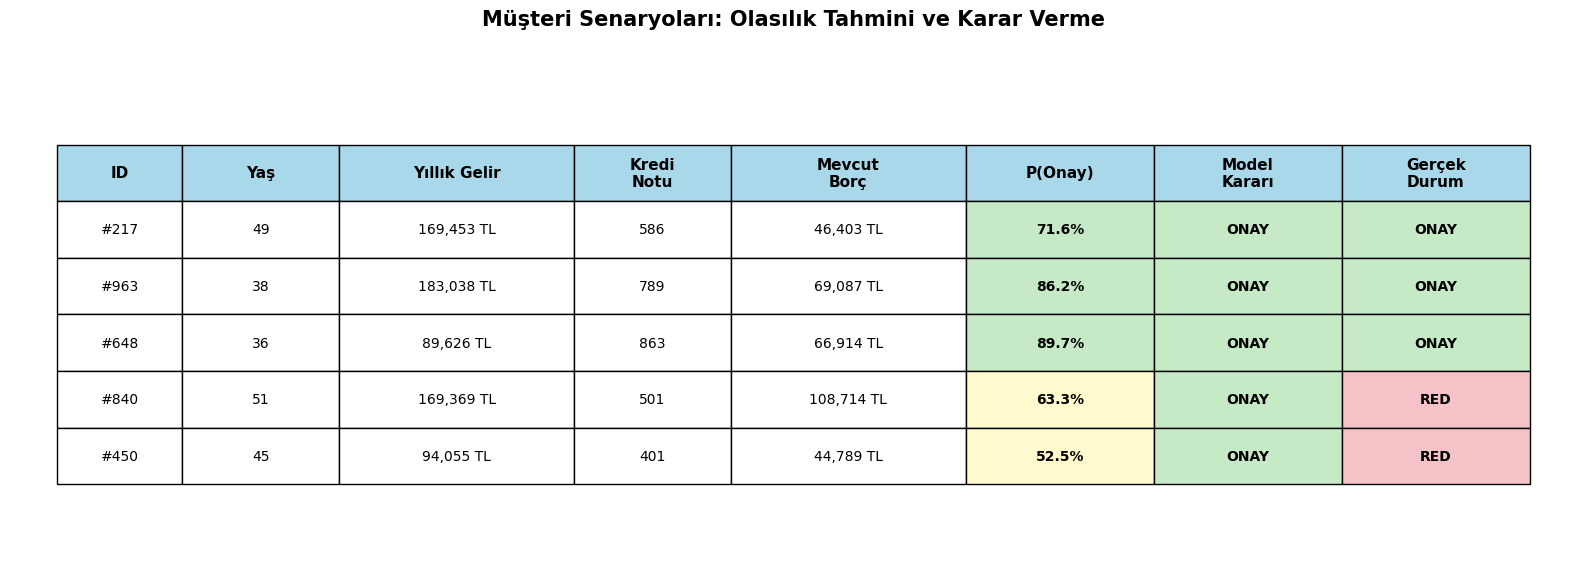


💡 OLASILIK YORUMLAMA - YBS PERSPEKTİFİ:

👤 Müşteri #217:
   Kredi Notu: 586
   Onay Olasılığı: 71.6%
   Risk Seviyesi: DÜŞÜK RİSK 🟢
   İş Önerisi: Onaylayın, standart kredi koşulları
   Model Kararı: ✅ ONAY
   Gerçek Durum: ✅ ONAY

👤 Müşteri #963:
   Kredi Notu: 789
   Onay Olasılığı: 86.2%
   Risk Seviyesi: ÇOK DÜŞÜK RİSK 🟢
   İş Önerisi: Kesinlikle onaylayın, müşteri çok güvenilir
   Model Kararı: ✅ ONAY
   Gerçek Durum: ✅ ONAY

👤 Müşteri #648:
   Kredi Notu: 863
   Onay Olasılığı: 89.7%
   Risk Seviyesi: ÇOK DÜŞÜK RİSK 🟢
   İş Önerisi: Kesinlikle onaylayın, müşteri çok güvenilir
   Model Kararı: ✅ ONAY
   Gerçek Durum: ✅ ONAY

👤 Müşteri #840:
   Kredi Notu: 501
   Onay Olasılığı: 63.3%
   Risk Seviyesi: DÜŞÜK RİSK 🟢
   İş Önerisi: Onaylayın, standart kredi koşulları
   Model Kararı: ✅ ONAY
   Gerçek Durum: ❌ RED

👤 Müşteri #450:
   Kredi Notu: 401
   Onay Olasılığı: 52.5%
   Risk Seviyesi: ORTA RİSK 🟡
   İş Önerisi: Ek teminat veya daha yüksek faiz ile değerlendirin
   Model Kararı

In [18]:
# Gerçek müşteri senaryoları ile olasılık tahmini
# Test setinden 5 rastgele müşteri seçelim
np.random.seed(42)
sample_indices = np.random.choice(X_test.index, 5, replace=False)
sample_customers = df_kredi.loc[sample_indices].copy()

# Basit lojistik model (sadece Kredi Notu ile) kullanarak olasılık hesapla
probabilities = logistic_model.predict_proba(sample_customers[['Kredi_Notu']].values)[:, 1]
sample_customers['Olasılık'] = probabilities
sample_customers['Model_Kararı'] = ['ONAY' if p >= 0.5 else 'RED' for p in probabilities]

# Görselleştirme için tablo
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('tight')
ax.axis('off')

# Tablo verisini hazırla
table_data = []
for idx, row in sample_customers.iterrows():
    table_data.append([
        f"#{idx}",
        f"{row['Yaş']}",
        f"{row['Yıllık_Gelir']:,} TL",
        f"{row['Kredi_Notu']}",
        f"{row['Mevcut_Borç']:,} TL",
        f"{row['Olasılık']:.1%}",
        row['Model_Kararı'],
        'ONAY' if row['Kredi_Onayı'] == 1 else 'RED'
    ])

columns = ['ID', 'Yaş', 'Yıllık Gelir', 'Kredi\nNotu', 'Mevcut\nBorç', 
          'P(Onay)', 'Model\nKararı', 'Gerçek\nDurum']

table = ax.table(cellText=table_data, colLabels=columns,
                cellLoc='center', loc='center', colWidths=[0.08, 0.1, 0.15, 0.1, 0.15, 0.12, 0.12, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 3)

# Header renklendirme
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#A8D8EA')
    table[(0, i)].set_text_props(weight='bold', size=11)

# Satırları rengilendir
for i, (idx, row) in enumerate(sample_customers.iterrows(), 1):
    # Olasılık sütunu
    if row['Olasılık'] >= 0.7:
        table[(i, 5)].set_facecolor('#C6E9C6')  # Yüksek olasılık - yeşil
    elif row['Olasılık'] >= 0.3:
        table[(i, 5)].set_facecolor('#FFFACD')  # Orta olasılık - sarı
    else:
        table[(i, 5)].set_facecolor('#F5C2C7')  # Düşük olasılık - kırmızı
    table[(i, 5)].set_text_props(weight='bold')
    
    # Model kararı
    if row['Model_Kararı'] == 'ONAY':
        table[(i, 6)].set_facecolor('#C6E9C6')
    else:
        table[(i, 6)].set_facecolor('#F5C2C7')
    table[(i, 6)].set_text_props(weight='bold')
    
    # Gerçek durum
    if row['Kredi_Onayı'] == 1:
        table[(i, 7)].set_facecolor('#C6E9C6')
    else:
        table[(i, 7)].set_facecolor('#F5C2C7')
    table[(i, 7)].set_text_props(weight='bold')

plt.title('Müşteri Senaryoları: Olasılık Tahmini ve Karar Verme', 
         fontsize=15, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 OLASILIK YORUMLAMA - YBS PERSPEKTİFİ:")
print("="*80)

for idx, row in sample_customers.iterrows():
    prob = row['Olasılık']
    print(f"\n👤 Müşteri #{idx}:")
    print(f"   Kredi Notu: {row['Kredi_Notu']}")
    print(f"   Onay Olasılığı: {prob:.1%}")
    
    if prob >= 0.8:
        risk = "ÇOK DÜŞÜK RİSK 🟢"
        oneri = "Kesinlikle onaylayın, müşteri çok güvenilir"
    elif prob >= 0.6:
        risk = "DÜŞÜK RİSK 🟢"
        oneri = "Onaylayın, standart kredi koşulları"
    elif prob >= 0.4:
        risk = "ORTA RİSK 🟡"
        oneri = "Ek teminat veya daha yüksek faiz ile değerlendirin"
    elif prob >= 0.2:
        risk = "YÜKSEK RİSK 🔴"
        oneri = "Risk yönetimi ile görüşülmeli, sınırlı kredi"
    else:
        risk = "ÇOK YÜKSEK RİSK 🔴"
        oneri = "Reddetme önerisi, batık kredi riski yüksek"
    
    print(f"   Risk Seviyesi: {risk}")
    print(f"   İş Önerisi: {oneri}")
    print(f"   Model Kararı: {'✅ ONAY' if row['Model_Kararı']=='ONAY' else '❌ RED'}")
    print(f"   Gerçek Durum: {'✅ ONAY' if row['Kredi_Onayı']==1 else '❌ RED'}")

print("\n" + "="*80)
print("\n🎯 ÖNEMLİ NOKTA:")
print("• 0.5 eşik değeri sabit değildir!")
print("• Banka risk iştahına göre ayarlanabilir:")
print("  - Muhafazakar banka → Eşik 0.7 (daha az onay, daha az risk)")
print("  - Agresif banka → Eşik 0.3 (daha fazla onay, daha fazla risk)")
print("• Her olasılık değeri, risk yönetimi için değerli bilgidir!")

### **3.5 Karar Eşiği (Threshold) Analizi**

Karar eşiği, olasılığı sınıf kararına dönüştüren kritik parametredir.

**Varsayılan:** Threshold = 0.5
- P(y=1) > 0.5 → Sınıf 1 (ONAY)
- P(y=1) ≤ 0.5 → Sınıf 0 (RED)

**Ama bu değer değiştirilebilir!** İş stratejisine göre optimize edilebilir.

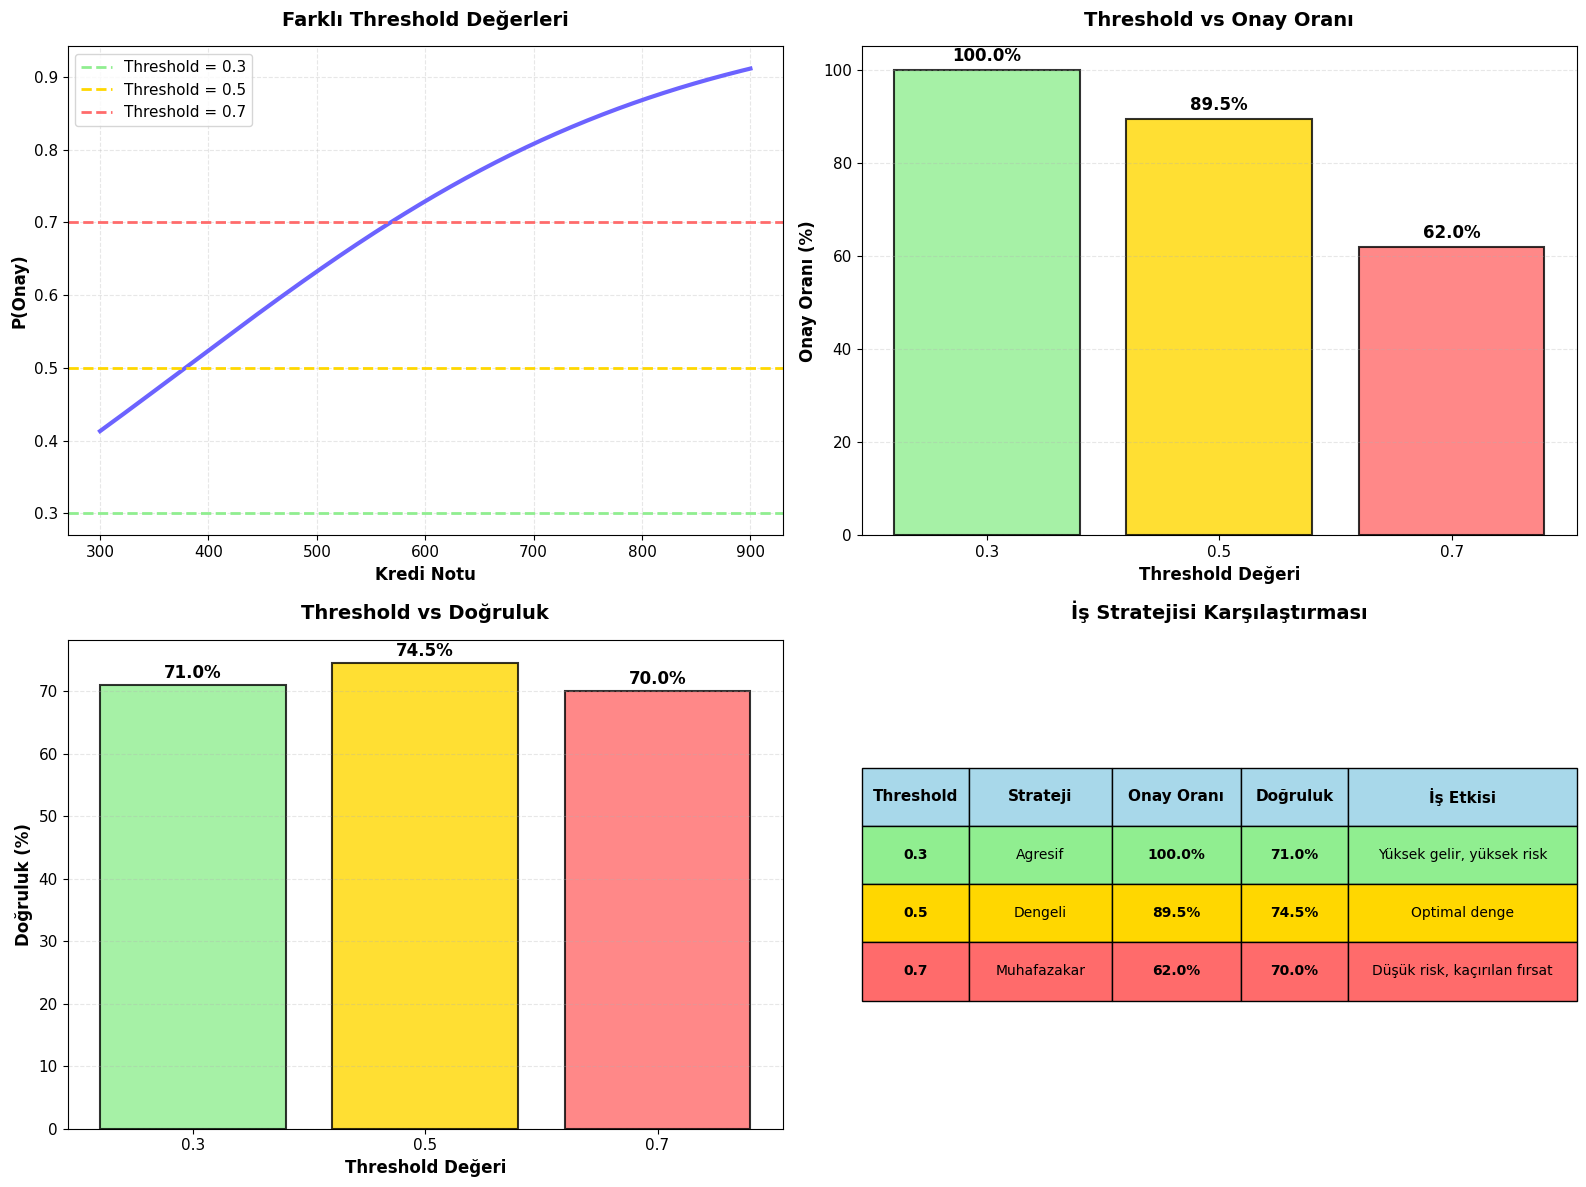


📊 THRESHOLD ANALİZİ SONUÇLARI:

🎯 Threshold = 0.3
   Onay Oranı: 100.0%
   Doğruluk: 71.0%
   Test setinde onaylanan: 200/200 başvuru

🎯 Threshold = 0.5
   Onay Oranı: 89.5%
   Doğruluk: 74.5%
   Test setinde onaylanan: 179/200 başvuru

🎯 Threshold = 0.7
   Onay Oranı: 62.0%
   Doğruluk: 70.0%
   Test setinde onaylanan: 124/200 başvuru


💼 YBS KARAR VERİCİ İÇİN REHBERİ:

🟢 THRESHOLD = 0.3 (Agresif Strateji):
   ✅ Avantaj: Daha fazla müşteri kazanılır, pazar payı artar
   ❌ Dezavantaj: Batık kredi riski yükselir
   🎯 Uygun: Rekabetçi pazarlarda, büyüme dönemi

🟡 THRESHOLD = 0.5 (Dengeli Strateji):
   ✅ Avantaj: Risk-getiri dengesi optimal
   ✅ Standart yaklaşım, çoğu senaryoda uygun
   🎯 Uygun: Normal piyasa koşullarında

🔴 THRESHOLD = 0.7 (Muhafazakar Strateji):
   ✅ Avantaj: Çok düşük batık kredi riski
   ❌ Dezavantaj: Güvenilir müşteriler reddedilebilir, gelir kaybı
   🎯 Uygun: Ekonomik belirsizlik, kriz dönemleri

🎯 SONUÇ: Threshold seçimi TEKNİK değil STRATEJİK bir karardır!


In [19]:
# Farklı threshold değerlerinin etkisini analiz edelim
thresholds = [0.3, 0.5, 0.7]
threshold_results = []

# Test seti üzerinde olasılık tahmini (basit model ile)
test_probs = logistic_model.predict_proba(X_test[['Kredi_Notu']].values)[:, 1]

for threshold in thresholds:
    # Bu threshold ile tahmin yap
    predictions = (test_probs >= threshold).astype(int)
    
    # Onay oranı hesapla
    approval_rate = (predictions == 1).sum() / len(predictions)
    
    # Doğruluk hesapla (gerçek y_test ile karşılaştır)
    accuracy = (predictions == y_test.values).sum() / len(y_test)
    
    threshold_results.append({
        'Threshold': threshold,
        'Onay_Oranı': approval_rate,
        'Doğruluk': accuracy,
        'Tahmin': predictions
    })

# Görselleştirme
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Threshold'ların sigmoid üzerinde gösterimi
axes[0, 0].plot(kredi_notu_range, y_pred_logistic, linewidth=3, color='#6C63FF')

colors_threshold = ['#90EE90', '#FFD700', '#FF6B6B']
for threshold, color in zip(thresholds, colors_threshold):
    axes[0, 0].axhline(y=threshold, color=color, linestyle='--', 
                      linewidth=2, label=f'Threshold = {threshold}')

axes[0, 0].set_xlabel('Kredi Notu', fontsize=12, weight='bold')
axes[0, 0].set_ylabel('P(Onay)', fontsize=12, weight='bold')
axes[0, 0].set_title('Farklı Threshold Değerleri', fontsize=14, weight='bold', pad=15)
axes[0, 0].legend(fontsize=11, loc='upper left')
axes[0, 0].grid(alpha=0.3, linestyle='--')

# 2. Onay oranları karşılaştırması
approval_rates = [r['Onay_Oranı'] * 100 for r in threshold_results]
bars = axes[0, 1].bar([f"{t}" for t in thresholds], approval_rates, 
                      color=colors_threshold, edgecolor='black', linewidth=1.5, alpha=0.8)

for bar, rate in zip(bars, approval_rates):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{rate:.1f}%', ha='center', va='bottom', 
                   fontsize=12, weight='bold')

axes[0, 1].set_xlabel('Threshold Değeri', fontsize=12, weight='bold')
axes[0, 1].set_ylabel('Onay Oranı (%)', fontsize=12, weight='bold')
axes[0, 1].set_title('Threshold vs Onay Oranı', fontsize=14, weight='bold', pad=15)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# 3. Doğruluk karşılaştırması
accuracies = [r['Doğruluk'] * 100 for r in threshold_results]
bars = axes[1, 0].bar([f"{t}" for t in thresholds], accuracies, 
                      color=colors_threshold, edgecolor='black', linewidth=1.5, alpha=0.8)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{acc:.1f}%', ha='center', va='bottom', 
                   fontsize=12, weight='bold')

axes[1, 0].set_xlabel('Threshold Değeri', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('Doğruluk (%)', fontsize=12, weight='bold')
axes[1, 0].set_title('Threshold vs Doğruluk', fontsize=14, weight='bold', pad=15)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# 4. Strateji karşılaştırma tablosu
axes[1, 1].axis('off')

strategy_data = [
    ['Threshold', 'Strateji', 'Onay Oranı', 'Doğruluk', 'İş Etkisi'],
    ['0.3', 'Agresif', f"{approval_rates[0]:.1f}%", f"{accuracies[0]:.1f}%", 'Yüksek gelir, yüksek risk'],
    ['0.5', 'Dengeli', f"{approval_rates[1]:.1f}%", f"{accuracies[1]:.1f}%", 'Optimal denge'],
    ['0.7', 'Muhafazakar', f"{approval_rates[2]:.1f}%", f"{accuracies[2]:.1f}%", 'Düşük risk, kaçırılan fırsat']
]

table = axes[1, 1].table(cellText=strategy_data, cellLoc='center', loc='center',
                        colWidths=[0.15, 0.2, 0.18, 0.15, 0.32])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 3)

# Header
for i in range(5):
    table[(0, i)].set_facecolor('#A8D8EA')
    table[(0, i)].set_text_props(weight='bold', size=11)

# Satırlar
for i, color in enumerate(colors_threshold, 1):
    for j in range(5):
        table[(i, j)].set_facecolor(color)
        if j == 0 or j == 2 or j == 3:  # Sayısal değerler
            table[(i, j)].set_text_props(weight='bold')

axes[1, 1].set_title('İş Stratejisi Karşılaştırması', fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.show()

print("\n📊 THRESHOLD ANALİZİ SONUÇLARI:")
print("="*80)

for result in threshold_results:
    print(f"\n🎯 Threshold = {result['Threshold']}")
    print(f"   Onay Oranı: {result['Onay_Oranı']*100:.1f}%")
    print(f"   Doğruluk: {result['Doğruluk']*100:.1f}%")
    print(f"   Test setinde onaylanan: {result['Tahmin'].sum()}/{len(result['Tahmin'])} başvuru")

print("\n" + "="*80)
print("\n💼 YBS KARAR VERİCİ İÇİN REHBERİ:")
print("\n🟢 THRESHOLD = 0.3 (Agresif Strateji):")
print("   ✅ Avantaj: Daha fazla müşteri kazanılır, pazar payı artar")
print("   ❌ Dezavantaj: Batık kredi riski yükselir")
print("   🎯 Uygun: Rekabetçi pazarlarda, büyüme dönemi")

print("\n🟡 THRESHOLD = 0.5 (Dengeli Strateji):")
print("   ✅ Avantaj: Risk-getiri dengesi optimal")
print("   ✅ Standart yaklaşım, çoğu senaryoda uygun")
print("   🎯 Uygun: Normal piyasa koşullarında")

print("\n🔴 THRESHOLD = 0.7 (Muhafazakar Strateji):")
print("   ✅ Avantaj: Çok düşük batık kredi riski")
print("   ❌ Dezavantaj: Güvenilir müşteriler reddedilebilir, gelir kaybı")
print("   🎯 Uygun: Ekonomik belirsizlik, kriz dönemleri")

print("\n🎯 SONUÇ: Threshold seçimi TEKNİK değil STRATEJİK bir karardır!")

## 🎯 **ADIM 4: İkili Sınıflandırma Modeli Uygulaması*

### **4.1 Scikit-learn ile Lojistik Regresyon Modeli**

Artık teorik altyapımız hazır! Şimdi gerçek veriyle **tüm özellikleri** kullanarak tam bir lojistik regresyon modeli eğiteceğiz.

**Kullanacağımız Veri:**
- ✅ 800 eğitim örneği
- ✅ 200 test örneği
- ✅ 6 özellik (Yaş, Gelir, Kredi Notu, Borç, Çalışma Süresi, Ev Sahibi)
- ✅ Ölçeklendirilmiş veriler (StandardScaler)

In [20]:
# Lojistik Regresyon modelini oluştur ve eğit
from sklearn.linear_model import LogisticRegression
import time

# Model oluşturma
print("🤖 LOJİSTİK REGRESYON MODELİ OLUŞTURULUYOR...")
print("="*70)

# LogisticRegression parametreleri
model_lr = LogisticRegression(
    penalty='l2',           # L2 regularization (Ridge)
    C=1.0,                  # Regularization gücü (düşük C = güçlü regularization)
    solver='lbfgs',         # Optimizasyon algoritması
    max_iter=1000,          # Maksimum iterasyon sayısı
    random_state=42,        # Tekrarlanabilirlik
    class_weight=None       # Sınıf ağırlıkları (None = dengeli)
)

print("\n📋 Model Parametreleri:")
print(f"   • Penalty: {model_lr.penalty} (Ridge regularization)")
print(f"   • C (Regularization): {model_lr.C}")
print(f"   • Solver: {model_lr.solver}")
print(f"   • Max Iterations: {model_lr.max_iter}")

# Model eğitimi
print("\n🎓 MODEL EĞİTİMİ BAŞLIYOR...")
start_time = time.time()

model_lr.fit(X_train_scaled, y_train)

end_time = time.time()
training_time = end_time - start_time

print(f"✅ Model eğitimi tamamlandı! (Süre: {training_time:.4f} saniye)")

# Model katsayılarını incele
print("\n📊 MODEL KATSAYILARI (θ - Theta):")
print("="*70)
print(f"{'Özellik':<20} | {'Katsayı (θ)':<15} | {'Etki':<30}")
print("-"*70)

feature_names = X.columns.tolist()
coefficients = model_lr.coef_[0]
intercept = model_lr.intercept_[0]

for feature, coef in zip(feature_names, coefficients):
    if coef > 0:
        etki = f"↗️ Pozitif (ONAY'ı artırır)"
        color = "🟢"
    else:
        etki = f"↘️ Negatif (RED'i artırır)"
        color = "🔴"
    
    print(f"{color} {feature:<17} | {coef:>14.4f} | {etki}")

print("-"*70)
print(f"🎯 Bias (θ₀):        | {intercept:>14.4f} | Sabit terim")

print("\n💡 KATSAYI YORUMLAMA:")
print("• Pozitif katsayı: Özellik arttıkça ONAY olasılığı artar")
print("• Negatif katsayı: Özellik arttıkça RED olasılığı artar")
print("• Büyük |katsayı|: Özellik kararı güçlü etkiler")
print("\n⚠️ NOT: Katsayılar standardize edilmiş özellikler içindir (karşılaştırılabilir)")

🤖 LOJİSTİK REGRESYON MODELİ OLUŞTURULUYOR...

📋 Model Parametreleri:
   • Penalty: l2 (Ridge regularization)
   • C (Regularization): 1.0
   • Solver: lbfgs
   • Max Iterations: 1000

🎓 MODEL EĞİTİMİ BAŞLIYOR...
✅ Model eğitimi tamamlandı! (Süre: 0.0024 saniye)

📊 MODEL KATSAYILARI (θ - Theta):
Özellik              | Katsayı (θ)     | Etki                          
----------------------------------------------------------------------
🔴 Yaş               |        -0.0907 | ↘️ Negatif (RED'i artırır)
🟢 Yıllık_Gelir      |         0.9891 | ↗️ Pozitif (ONAY'ı artırır)
🟢 Kredi_Notu        |         0.9529 | ↗️ Pozitif (ONAY'ı artırır)
🔴 Mevcut_Borç       |        -0.8247 | ↘️ Negatif (RED'i artırır)
🟢 Çalışma_Süresi    |         0.4138 | ↗️ Pozitif (ONAY'ı artırır)
🟢 Ev_Sahibi         |         0.5844 | ↗️ Pozitif (ONAY'ı artırır)
----------------------------------------------------------------------
🎯 Bias (θ₀):        |         1.3663 | Sabit terim

💡 KATSAYI YORUMLAMA:
• Pozitif katsayı

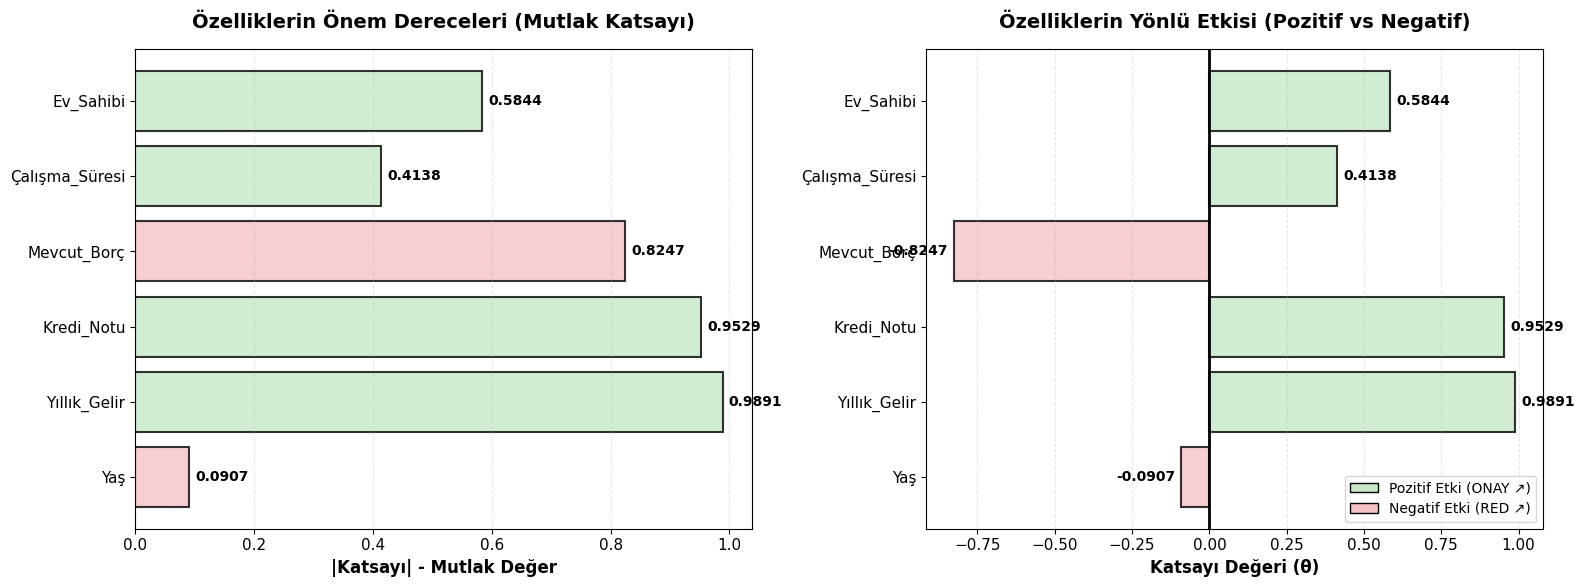


🔍 ÖZELLİK ÖNEMİ SIRLAMASI:
Yıllık_Gelir         | θ =   0.9891 | ↗️ Pozitif
Kredi_Notu           | θ =   0.9529 | ↗️ Pozitif
Mevcut_Borç          | θ =  -0.8247 | ↘️ Negatif
Ev_Sahibi            | θ =   0.5844 | ↗️ Pozitif
Çalışma_Süresi       | θ =   0.4138 | ↗️ Pozitif
Yaş                  | θ =  -0.0907 | ↘️ Negatif

💼 YBS YORUMU:
• En etkili özellik: Yıllık_Gelir
• Bu özellik kredi onayını pozitif yönde etkiler
• Model kararlarında en yüksek ağırlığa sahip


In [21]:
# Katsayıları görselleştir
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol grafik: Katsayıların büyüklüğü
coef_abs = np.abs(coefficients)
colors_coef = ['#C6E9C6' if c > 0 else '#F5C2C7' for c in coefficients]

bars = axes[0].barh(feature_names, coef_abs, color=colors_coef, 
                    edgecolor='black', linewidth=1.5, alpha=0.8)

# Değerleri çubukların yanına yaz
for i, (bar, val) in enumerate(zip(bars, coef_abs)):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontsize=10, weight='bold')

axes[0].set_xlabel('|Katsayı| - Mutlak Değer', fontsize=12, weight='bold')
axes[0].set_title('Özelliklerin Önem Dereceleri (Mutlak Katsayı)', 
                 fontsize=14, weight='bold', pad=15)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# Sağ grafik: Katsayıların yönü (pozitif/negatif)
colors_signed = ['#C6E9C6' if c > 0 else '#F5C2C7' for c in coefficients]
bars = axes[1].barh(feature_names, coefficients, color=colors_signed, 
                    edgecolor='black', linewidth=1.5, alpha=0.8)

# Değerleri çubukların yanına yaz
for bar, val in zip(bars, coefficients):
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    axes[1].text(x_pos, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', ha=ha, fontsize=10, weight='bold')

axes[1].axvline(x=0, color='black', linestyle='-', linewidth=2)
axes[1].set_xlabel('Katsayı Değeri (θ)', fontsize=12, weight='bold')
axes[1].set_title('Özelliklerin Yönlü Etkisi (Pozitif vs Negatif)', 
                 fontsize=14, weight='bold', pad=15)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

# Legend ekle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C6E9C6', edgecolor='black', label='Pozitif Etki (ONAY ↗️)'),
    Patch(facecolor='#F5C2C7', edgecolor='black', label='Negatif Etki (RED ↗️)')
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n🔍 ÖZELLİK ÖNEMİ SIRLAMASI:")
print("="*70)

# Önem derecesine göre sırala
feature_importance = pd.DataFrame({
    'Özellik': feature_names,
    'Katsayı': coefficients,
    'Mutlak_Değer': np.abs(coefficients),
    'Yön': ['↗️ Pozitif' if c > 0 else '↘️ Negatif' for c in coefficients]
}).sort_values('Mutlak_Değer', ascending=False)

for idx, row in feature_importance.iterrows():
    print(f"{row['Özellik']:<20} | θ = {row['Katsayı']:>8.4f} | {row['Yön']}")

print("\n💼 YBS YORUMU:")
most_important = feature_importance.iloc[0]
print(f"• En etkili özellik: {most_important['Özellik']}")
print(f"• Bu özellik kredi onayını {most_important['Yön'].split()[1].lower()} yönde etkiler")
print(f"• Model kararlarında en yüksek ağırlığa sahip")

### 4.2 Tahmin Yapma ve Olasılık Üretme

Eğitilmiş modelle artık tahmin yapabiliriz. Lojistik regresyon iki tür çıktı üretir:
1. **Sınıf Tahmini** (0 veya 1): `predict()`
2. **Olasılık Tahmini** (0-1 arası): `predict_proba()`

In [22]:
# Eğitim ve test setleri üzerinde tahmin yap
print("🔮 TAHMİN YAPILIYOR...")
print("="*70)

# 1. Sınıf tahminleri
y_train_pred = model_lr.predict(X_train_scaled)
y_test_pred = model_lr.predict(X_test_scaled)

# 2. Olasılık tahminleri
y_train_proba = model_lr.predict_proba(X_train_scaled)  # [P(0), P(1)] şeklinde
y_test_proba = model_lr.predict_proba(X_test_scaled)

# Sadece Sınıf 1 (ONAY) olasılıklarını alalım
y_train_proba_1 = y_train_proba[:, 1]
y_test_proba_1 = y_test_proba[:, 1]

print("✅ Tahminler tamamlandı!")
print(f"\n📊 EĞİTİM SETİ TAHMİNLERİ:")
print(f"   • Toplam örnek: {len(y_train_pred)}")
print(f"   • ONAY tahmini: {(y_train_pred == 1).sum()} ({(y_train_pred == 1).sum()/len(y_train_pred)*100:.1f}%)")
print(f"   • RED tahmini: {(y_train_pred == 0).sum()} ({(y_train_pred == 0).sum()/len(y_train_pred)*100:.1f}%)")

print(f"\n📊 TEST SETİ TAHMİNLERİ:")
print(f"   • Toplam örnek: {len(y_test_pred)}")
print(f"   • ONAY tahmini: {(y_test_pred == 1).sum()} ({(y_test_pred == 1).sum()/len(y_test_pred)*100:.1f}%)")
print(f"   • RED tahmini: {(y_test_pred == 0).sum()} ({(y_test_pred == 0).sum()/len(y_test_pred)*100:.1f}%)")

# İlk 10 test örneği için detaylı bakış
print("\n" + "="*70)
print("🔍 İLK 10 TEST ÖRNEĞİ - DETAYLI ANALİZ:")
print("="*70)

sample_df = pd.DataFrame({
    'Gerçek': y_test.values[:10],
    'Tahmin': y_test_pred[:10],
    'P(RED)': y_test_proba[:10, 0],
    'P(ONAY)': y_test_proba[:10, 1],
    'Doğru?': y_test.values[:10] == y_test_pred[:10]
})

for idx, row in sample_df.iterrows():
    gercek_label = "✅ ONAY" if row['Gerçek'] == 1 else "❌ RED"
    tahmin_label = "✅ ONAY" if row['Tahmin'] == 1 else "❌ RED"
    dogru = "✓ Doğru" if row['Doğru?'] else "✗ Yanlış"
    
    print(f"\nÖrnek {idx+1}:")
    print(f"   Gerçek: {gercek_label}")
    print(f"   Tahmin: {tahmin_label}")
    print(f"   P(RED) = {row['P(RED)']:.4f} | P(ONAY) = {row['P(ONAY)']:.4f}")
    print(f"   Sonuç: {dogru}")

print("\n" + "="*70)

🔮 TAHMİN YAPILIYOR...
✅ Tahminler tamamlandı!

📊 EĞİTİM SETİ TAHMİNLERİ:
   • Toplam örnek: 800
   • ONAY tahmini: 617 (77.1%)
   • RED tahmini: 183 (22.9%)

📊 TEST SETİ TAHMİNLERİ:
   • Toplam örnek: 200
   • ONAY tahmini: 158 (79.0%)
   • RED tahmini: 42 (21.0%)

🔍 İLK 10 TEST ÖRNEĞİ - DETAYLI ANALİZ:

Örnek 1:
   Gerçek: ✅ ONAY
   Tahmin: ✅ ONAY
   P(RED) = 0.1051 | P(ONAY) = 0.8949
   Sonuç: ✓ Doğru

Örnek 2:
   Gerçek: ✅ ONAY
   Tahmin: ✅ ONAY
   P(RED) = 0.2042 | P(ONAY) = 0.7958
   Sonuç: ✓ Doğru

Örnek 3:
   Gerçek: ❌ RED
   Tahmin: ✅ ONAY
   P(RED) = 0.1889 | P(ONAY) = 0.8111
   Sonuç: ✗ Yanlış

Örnek 4:
   Gerçek: ✅ ONAY
   Tahmin: ✅ ONAY
   P(RED) = 0.0130 | P(ONAY) = 0.9870
   Sonuç: ✓ Doğru

Örnek 5:
   Gerçek: ✅ ONAY
   Tahmin: ✅ ONAY
   P(RED) = 0.3041 | P(ONAY) = 0.6959
   Sonuç: ✓ Doğru

Örnek 6:
   Gerçek: ❌ RED
   Tahmin: ✅ ONAY
   P(RED) = 0.1612 | P(ONAY) = 0.8388
   Sonuç: ✗ Yanlış

Örnek 7:
   Gerçek: ✅ ONAY
   Tahmin: ✅ ONAY
   P(RED) = 0.0922 | P(ONAY) = 0.9078

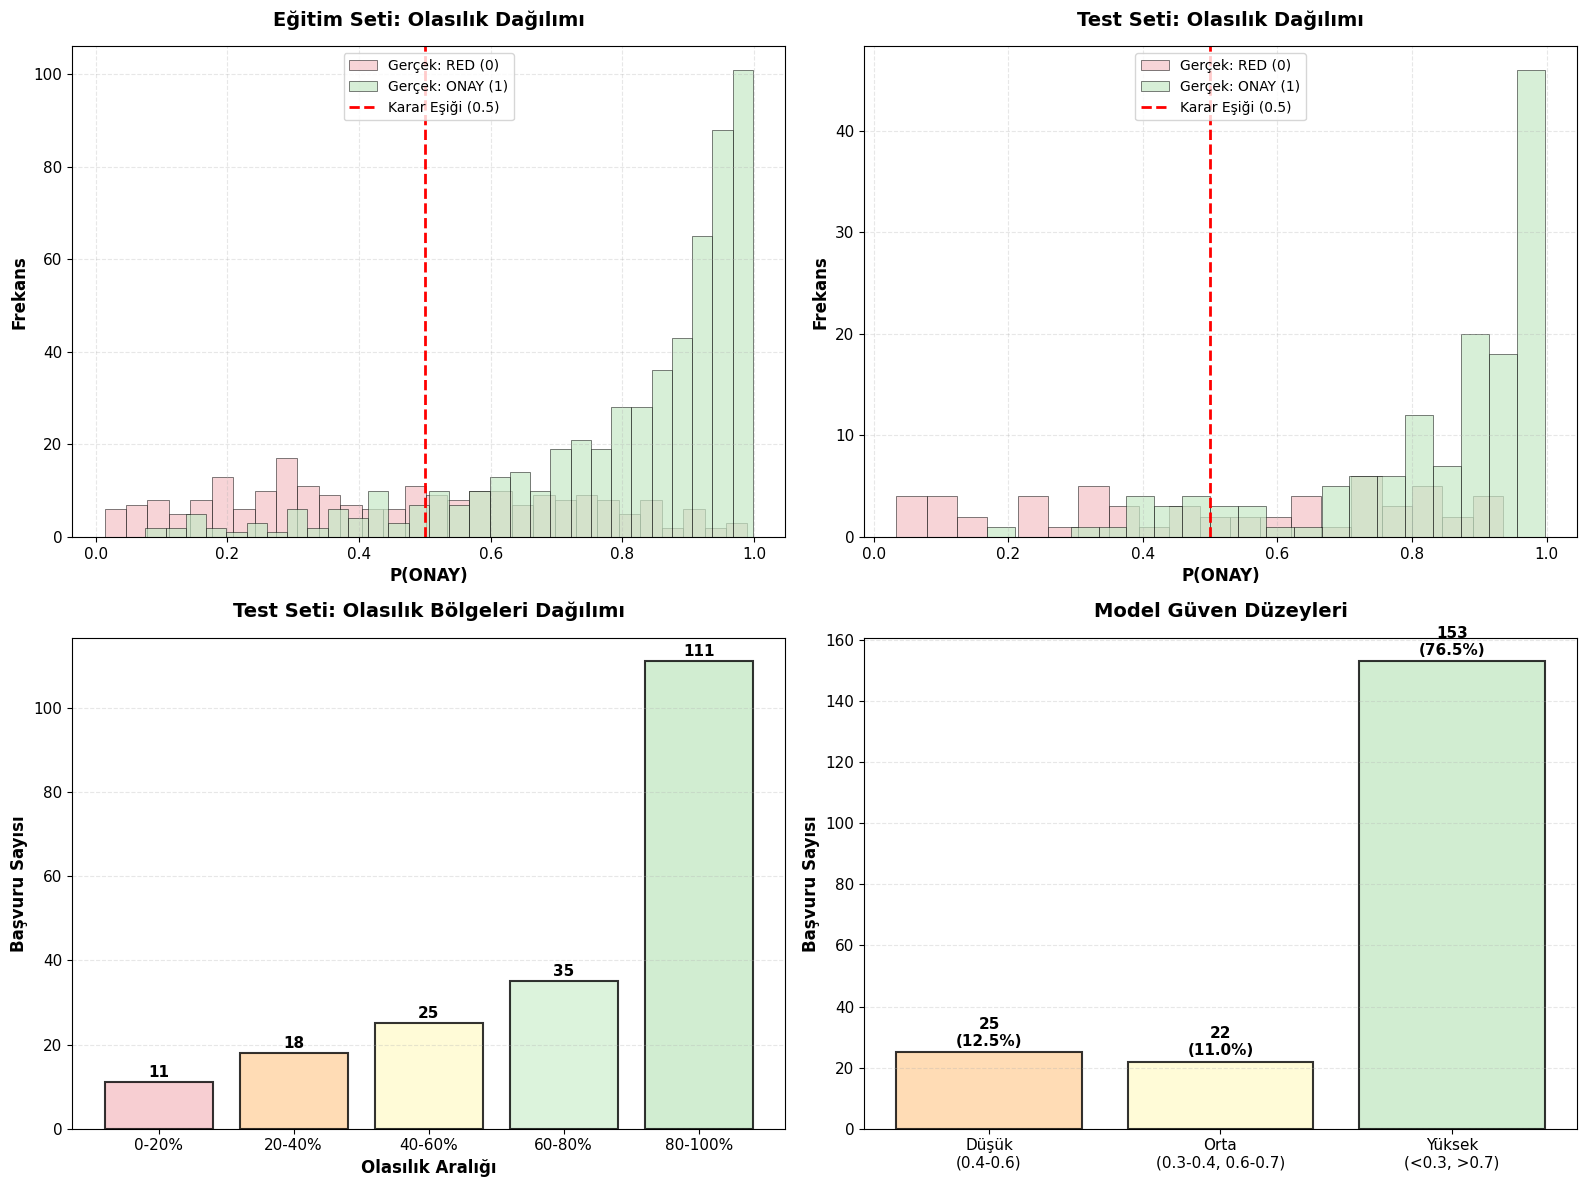


📊 OLASILIK ANALİZİ SONUÇLARI:

🎯 Test Seti Olasılık İstatistikleri:
   • Ortalama P(ONAY): 0.7369
   • Medyan P(ONAY): 0.8276
   • Std. Sapma: 0.2595
   • Min P(ONAY): 0.0337
   • Max P(ONAY): 0.9970

🔍 Güven Düzeyi Dağılımı:
   • Yüksek Güven: 153 örnek (76.5%)
     → Model çok emin (P<0.3 veya P>0.7)
   • Orta Güven: 22 örnek (11.0%)
     → Model nispeten emin
   • Düşük Güven: 25 örnek (12.5%)
     → Model kararsız (P≈0.5), manuel inceleme gerekebilir

💼 YBS YORUMU:
• Yüksek güven örnekleri → Otomatik işlem yapılabilir
• Düşük güven örnekleri → Uzman incelemesi önerilir
• İyi bir model, çoğu örnekte yüksek güven göstermelidir


In [23]:
# Olasılık dağılımlarını görselleştir
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Eğitim seti - Olasılık dağılımı (sınıflara göre)
axes[0, 0].hist(y_train_proba_1[y_train == 0], bins=30, alpha=0.7, 
               color='#F5C2C7', label='Gerçek: RED (0)', edgecolor='black', linewidth=0.5)
axes[0, 0].hist(y_train_proba_1[y_train == 1], bins=30, alpha=0.7, 
               color='#C6E9C6', label='Gerçek: ONAY (1)', edgecolor='black', linewidth=0.5)
axes[0, 0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Karar Eşiği (0.5)')
axes[0, 0].set_xlabel('P(ONAY)', fontsize=12, weight='bold')
axes[0, 0].set_ylabel('Frekans', fontsize=12, weight='bold')
axes[0, 0].set_title('Eğitim Seti: Olasılık Dağılımı', fontsize=14, weight='bold', pad=15)
axes[0, 0].legend(fontsize=10, loc='upper center')
axes[0, 0].grid(alpha=0.3, linestyle='--')

# 2. Test seti - Olasılık dağılımı (sınıflara göre)
axes[0, 1].hist(y_test_proba_1[y_test == 0], bins=20, alpha=0.7, 
               color='#F5C2C7', label='Gerçek: RED (0)', edgecolor='black', linewidth=0.5)
axes[0, 1].hist(y_test_proba_1[y_test == 1], bins=20, alpha=0.7, 
               color='#C6E9C6', label='Gerçek: ONAY (1)', edgecolor='black', linewidth=0.5)
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Karar Eşiği (0.5)')
axes[0, 1].set_xlabel('P(ONAY)', fontsize=12, weight='bold')
axes[0, 1].set_ylabel('Frekans', fontsize=12, weight='bold')
axes[0, 1].set_title('Test Seti: Olasılık Dağılımı', fontsize=14, weight='bold', pad=15)
axes[0, 1].legend(fontsize=10, loc='upper center')
axes[0, 1].grid(alpha=0.3, linestyle='--')

# 3. Olasılık aralıklarına göre dağılım
prob_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
prob_labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']

test_prob_binned = pd.cut(y_test_proba_1, bins=prob_bins, labels=prob_labels)
bin_counts = test_prob_binned.value_counts().sort_index()

colors_bins = ['#F5C2C7', '#FFD4A3', '#FFFACD', '#D4F1D4', '#C6E9C6']
bars = axes[1, 0].bar(range(len(bin_counts)), bin_counts.values, 
                      color=colors_bins, edgecolor='black', linewidth=1.5, alpha=0.8)

axes[1, 0].set_xticks(range(len(bin_counts)))
axes[1, 0].set_xticklabels(bin_counts.index, fontsize=11)
axes[1, 0].set_xlabel('Olasılık Aralığı', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('Başvuru Sayısı', fontsize=12, weight='bold')
axes[1, 0].set_title('Test Seti: Olasılık Bölgeleri Dağılımı', fontsize=14, weight='bold', pad=15)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Değerleri çubukların üstüne yaz
for bar, count in zip(bars, bin_counts.values):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{count}', ha='center', va='bottom', fontsize=11, weight='bold')

# 4. Güven düzeyi analizi
confidence_low = ((y_test_proba_1 > 0.4) & (y_test_proba_1 < 0.6)).sum()
confidence_medium = (((y_test_proba_1 >= 0.3) & (y_test_proba_1 <= 0.4)) | 
                    ((y_test_proba_1 >= 0.6) & (y_test_proba_1 <= 0.7))).sum()
confidence_high = ((y_test_proba_1 <= 0.3) | (y_test_proba_1 >= 0.7)).sum()

confidence_data = {
    'Güven Seviyesi': ['Düşük\n(0.4-0.6)', 'Orta\n(0.3-0.4, 0.6-0.7)', 'Yüksek\n(<0.3, >0.7)'],
    'Sayı': [confidence_low, confidence_medium, confidence_high],
    'Oran': [confidence_low/len(y_test)*100, confidence_medium/len(y_test)*100, 
             confidence_high/len(y_test)*100]
}

colors_conf = ['#FFD4A3', '#FFFACD', '#C6E9C6']
bars = axes[1, 1].bar(confidence_data['Güven Seviyesi'], confidence_data['Sayı'], 
                      color=colors_conf, edgecolor='black', linewidth=1.5, alpha=0.8)

axes[1, 1].set_ylabel('Başvuru Sayısı', fontsize=12, weight='bold')
axes[1, 1].set_title('Model Güven Düzeyleri', fontsize=14, weight='bold', pad=15)
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Değerleri ve yüzdeleri yaz
for bar, count, pct in zip(bars, confidence_data['Sayı'], confidence_data['Oran']):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{count}\n({pct:.1f}%)', ha='center', va='bottom', 
                   fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

print("\n📊 OLASILIK ANALİZİ SONUÇLARI:")
print("="*70)
print(f"\n🎯 Test Seti Olasılık İstatistikleri:")
print(f"   • Ortalama P(ONAY): {y_test_proba_1.mean():.4f}")
print(f"   • Medyan P(ONAY): {np.median(y_test_proba_1):.4f}")
print(f"   • Std. Sapma: {y_test_proba_1.std():.4f}")
print(f"   • Min P(ONAY): {y_test_proba_1.min():.4f}")
print(f"   • Max P(ONAY): {y_test_proba_1.max():.4f}")

print(f"\n🔍 Güven Düzeyi Dağılımı:")
print(f"   • Yüksek Güven: {confidence_high} örnek ({confidence_high/len(y_test)*100:.1f}%)")
print(f"     → Model çok emin (P<0.3 veya P>0.7)")
print(f"   • Orta Güven: {confidence_medium} örnek ({confidence_medium/len(y_test)*100:.1f}%)")
print(f"     → Model nispeten emin")
print(f"   • Düşük Güven: {confidence_low} örnek ({confidence_low/len(y_test)*100:.1f}%)")
print(f"     → Model kararsız (P≈0.5), manuel inceleme gerekebilir")

print("\n💼 YBS YORUMU:")
print("• Yüksek güven örnekleri → Otomatik işlem yapılabilir")
print("• Düşük güven örnekleri → Uzman incelemesi önerilir")
print("• İyi bir model, çoğu örnekte yüksek güven göstermelidir")

## 🎯 **ADIM 5: Confusion Matrix ve Performans Metrikleri**

### **5.1 Confusion Matrix (Karmaşıklık Matrisi) Nedir?**

**Confusion Matrix**, sınıflandırma modelinin performansını analiz etmek için kullanılan en temel araçtır.

**4 Ana Bileşen:**

| | **Tahmin: NEGATİF (0)** | **Tahmin: POZİTİF (1)** |
|---|---|---|
| **Gerçek: NEGATİF (0)** | ✅ **True Negative (TN)**<br/>Doğru RED | ❌ **False Positive (FP)**<br/>Yanlış ONAY<br/>(Type I Error) |
| **Gerçek: POZİTİF (1)** | ❌ **False Negative (FN)**<br/>Yanlış RED<br/>(Type II Error) | ✅ **True Positive (TP)**<br/>Doğru ONAY |

**YBS Açısından:**
- **TN**: Riskli müşteriyi doğru reddettik → 💰 Batık kredi engelledik
- **FP**: Riskli müşteriyi yanlışlıkla onayladık → ⚠️ Batık kredi riski!
- **FN**: Güvenilir müşteriyi yanlışlıkla reddettik → 😢 Müşteri kaybı
- **TP**: Güvenilir müşteriyi doğru onayladık → ✅ Sağlıklı kredi

📊 CONFUSION MATRIX HESAPLANIYOR...

✅ Confusion Matrix Hesaplandı:

   True Negative (TN):   28 → Doğru RED
   False Positive (FP):  30 → Yanlış ONAY (Type I Error)
   False Negative (FN):  14 → Yanlış RED (Type II Error)
   True Positive (TP):  128 → Doğru ONAY

   Toplam Test Örneği:  200


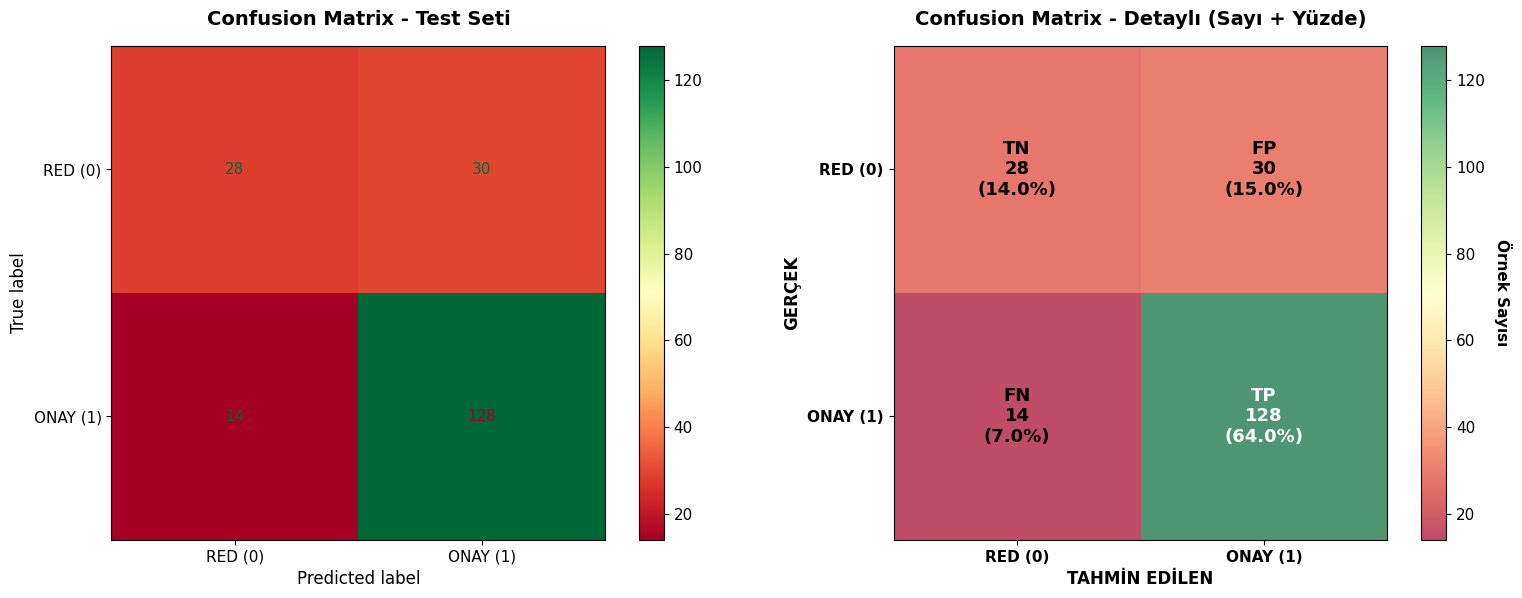


💡 CONFUSION MATRIX YORUMLAMA:

📊 DOĞRU TAHMİNLER (Diagonal):
   • TN + TP = 28 + 128 = 156 (78.0%)
   → Model bu örnekleri DOĞRU sınıflandırdı

❌ YANLIŞ TAHMİNLER (Off-diagonal):
   • FP + FN = 30 + 14 = 44 (22.0%)
   → Model bu örneklerde HATA yaptı

🎯 HATA TÜRLERİ ANALİZİ:

   Type I Error (False Positive - FP):
   • Sayı: 30 (15.0%)
   • YBS Etkisi: Riskli müşteri onaylandı → Batık kredi riski
   • Maliyet: YÜKSEK (doğrudan finansal kayıp)

   Type II Error (False Negative - FN):
   • Sayı: 14 (7.0%)
   • YBS Etkisi: Güvenilir müşteri reddedildi → Fırsat kaybı
   • Maliyet: ORTA (dolaylı gelir kaybı, müşteri kaybı)

⚠️ UYARI: FP > FN → Model çok fazla ONAY veriyor (Agresif)
   → Risk yönetimi gözden geçirilmeli


In [24]:
# Confusion Matrix hesaplama
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("📊 CONFUSION MATRIX HESAPLANIYOR...")
print("="*70)

# Test seti için confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)

# Bileşenleri çıkar
tn, fp, fn, tp = cm_test.ravel()

print(f"\n✅ Confusion Matrix Hesaplandı:")
print(f"\n   True Negative (TN):  {tn:3d} → Doğru RED")
print(f"   False Positive (FP): {fp:3d} → Yanlış ONAY (Type I Error)")
print(f"   False Negative (FN): {fn:3d} → Yanlış RED (Type II Error)")
print(f"   True Positive (TP):  {tp:3d} → Doğru ONAY")
print(f"\n   Toplam Test Örneği:  {tn + fp + fn + tp}")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol grafik: Sklearn'in confusion matrix görselleştirmesi
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, 
                              display_labels=['RED (0)', 'ONAY (1)'])
disp.plot(ax=axes[0], cmap='RdYlGn', colorbar=True, values_format='d')
axes[0].set_title('Confusion Matrix - Test Seti', fontsize=14, weight='bold', pad=15)
axes[0].grid(False)

# Sağ grafik: Özelleştirilmiş confusion matrix (yüzde ile)
cm_percent = cm_test / cm_test.sum() * 100

# Manuel olarak güzel bir confusion matrix çiz
im = axes[1].imshow(cm_test, interpolation='nearest', cmap='RdYlGn', alpha=0.7)

# Renk ölçeği
cbar = axes[1].figure.colorbar(im, ax=axes[1])
cbar.set_label('Örnek Sayısı', rotation=270, labelpad=20, fontsize=11, weight='bold')

# Eksen etiketleri
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['RED (0)', 'ONAY (1)'], fontsize=11, weight='bold')
axes[1].set_yticklabels(['RED (0)', 'ONAY (1)'], fontsize=11, weight='bold')
axes[1].set_xlabel('TAHMİN EDİLEN', fontsize=12, weight='bold')
axes[1].set_ylabel('GERÇEK', fontsize=12, weight='bold')
axes[1].set_title('Confusion Matrix - Detaylı (Sayı + Yüzde)', 
                 fontsize=14, weight='bold', pad=15)

# Her hücreye sayı ve yüzde yaz
labels = [
    [f'TN\n{tn}\n({cm_percent[0,0]:.1f}%)', f'FP\n{fp}\n({cm_percent[0,1]:.1f}%)'],
    [f'FN\n{fn}\n({cm_percent[1,0]:.1f}%)', f'TP\n{tp}\n({cm_percent[1,1]:.1f}%)']
]

for i in range(2):
    for j in range(2):
        color = 'white' if cm_test[i, j] > cm_test.max() / 2 else 'black'
        axes[1].text(j, i, labels[i][j], ha='center', va='center', 
                    fontsize=13, weight='bold', color=color)

axes[1].grid(False)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 CONFUSION MATRIX YORUMLAMA:")
print("="*70)

total = tn + fp + fn + tp
print(f"\n📊 DOĞRU TAHMİNLER (Diagonal):")
print(f"   • TN + TP = {tn} + {tp} = {tn + tp} ({(tn + tp)/total*100:.1f}%)")
print(f"   → Model bu örnekleri DOĞRU sınıflandırdı")

print(f"\n❌ YANLIŞ TAHMİNLER (Off-diagonal):")
print(f"   • FP + FN = {fp} + {fn} = {fp + fn} ({(fp + fn)/total*100:.1f}%)")
print(f"   → Model bu örneklerde HATA yaptı")

print(f"\n🎯 HATA TÜRLERİ ANALİZİ:")
print(f"\n   Type I Error (False Positive - FP):")
print(f"   • Sayı: {fp} ({fp/total*100:.1f}%)")
print(f"   • YBS Etkisi: Riskli müşteri onaylandı → Batık kredi riski")
print(f"   • Maliyet: YÜKSEK (doğrudan finansal kayıp)")

print(f"\n   Type II Error (False Negative - FN):")
print(f"   • Sayı: {fn} ({fn/total*100:.1f}%)")
print(f"   • YBS Etkisi: Güvenilir müşteri reddedildi → Fırsat kaybı")
print(f"   • Maliyet: ORTA (dolaylı gelir kaybı, müşteri kaybı)")

if fp > fn:
    print(f"\n⚠️ UYARI: FP > FN → Model çok fazla ONAY veriyor (Agresif)")
    print("   → Risk yönetimi gözden geçirilmeli")
elif fn > fp:
    print(f"\n⚠️ UYARI: FN > FP → Model çok fazla RED veriyor (Muhafazakar)")
    print("   → Fırsat kaybı söz konusu")
else:
    print(f"\n✅ DENGELI: FP ≈ FN → Model dengeli kararlar veriyor")

### **5.2 Temel Performans Metrikleri**

Confusion Matrix'ten türetilen metrikler, modelin farklı açılardan performansını değerlendirir.

**1️⃣ Accuracy (Doğruluk)**

$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

**Ne soruyor?** "Toplam tahminlerimizin kaçı doğru?"

**2️⃣ Precision (Kesinlik)**

$$ \text{Precision} = \frac{TP}{TP + FP} $$

**Ne soruyor?** "ONAY dediğimiz kredilerin kaçı gerçekten güveniliydi?"

**3️⃣ Recall (Duyarlılık / Sensitivity)**

$$ \text{Recall} = \frac{TP}{TP + FN} $$

**Ne soruyor?** "Gerçekten güvenilir olan müşterilerin kaçını yakaladık?"

**4️⃣ F1-Score (Harmonik Ortalama)**

$$ \text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

**Ne soruyor?** "Precision ve Recall'un dengesi nedir?"

In [25]:
# Performans metriklerini hesapla
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

print("📊 PERFORMANS METRİKLERİ HESAPLANIYOR...")
print("="*70)

# Eğitim seti metrikleri
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# Test seti metrikleri
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Manuel hesaplama (doğrulama için)
manual_accuracy = (tp + tn) / (tp + tn + fp + fn)
manual_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
manual_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
manual_f1 = 2 * (manual_precision * manual_recall) / (manual_precision + manual_recall) if (manual_precision + manual_recall) > 0 else 0

print("\n✅ Metrikler Hesaplandı!")
print("\n" + "="*70)
print("📊 TEST SETİ PERFORMANS METRİKLERİ:")
print("="*70)

print(f"\n🎯 ACCURACY (Doğruluk): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Formül: (TP + TN) / Toplam = ({tp} + {tn}) / {tp+tn+fp+fn}")
print(f"   Yorum: Tüm tahminlerin %{test_accuracy*100:.1f}'i doğru")

print(f"\n🎯 PRECISION (Kesinlik): {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"   Formül: TP / (TP + FP) = {tp} / ({tp} + {fp})")
print(f"   Yorum: ONAY dediğimiz {tp+fp} kredinin %{test_precision*100:.1f}'i gerçekten güvenilir")

print(f"\n🎯 RECALL (Duyarlılık): {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"   Formül: TP / (TP + FN) = {tp} / ({tp} + {fn})")
print(f"   Yorum: Güvenilir {tp+fn} müşterinin %{test_recall*100:.1f}'ini yakaladık")

print(f"\n🎯 F1-SCORE (Harmonik Ortalama): {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"   Formül: 2 × (Precision × Recall) / (Precision + Recall)")
print(f"   Yorum: Precision ve Recall'un dengeli skoru")

# Eğitim vs Test karşılaştırması
print("\n" + "="*70)
print("📊 EĞİTİM vs TEST KARŞILAŞTIRMASI:")
print("="*70)
print(f"{'Metrik':<15} | {'Eğitim':<12} | {'Test':<12} | {'Fark':<12}")
print("-"*70)
print(f"{'Accuracy':<15} | {train_accuracy:>11.4f} | {test_accuracy:>11.4f} | {train_accuracy-test_accuracy:>+11.4f}")
print(f"{'Precision':<15} | {train_precision:>11.4f} | {test_precision:>11.4f} | {train_precision-test_precision:>+11.4f}")
print(f"{'Recall':<15} | {train_recall:>11.4f} | {test_recall:>11.4f} | {train_recall-test_recall:>+11.4f}")
print(f"{'F1-Score':<15} | {train_f1:>11.4f} | {test_f1:>11.4f} | {train_f1-test_f1:>+11.4f}")

# Overfitting kontrolü
avg_diff = abs(train_accuracy - test_accuracy)
if avg_diff < 0.05:
    print("\n✅ Model GENELLEŞME BAŞARILI: Eğitim ve test performansı yakın")
elif avg_diff < 0.10:
    print("\n⚠️ HAFIF OVERFITTING: Eğitim performansı test'ten biraz yüksek")
else:
    print("\n❌ CİDDİ OVERFITTING: Model eğitim verisi üzerinde ezberliyor!")

# Scikit-learn classification report
print("\n" + "="*70)
print("📋 DETAYLI SINIFLANDIRMA RAPORU:")
print("="*70)
print(classification_report(y_test, y_test_pred, 
                           target_names=['RED (0)', 'ONAY (1)'],
                           digits=4))

📊 PERFORMANS METRİKLERİ HESAPLANIYOR...

✅ Metrikler Hesaplandı!

📊 TEST SETİ PERFORMANS METRİKLERİ:

🎯 ACCURACY (Doğruluk): 0.7800 (78.00%)
   Formül: (TP + TN) / Toplam = (128 + 28) / 200
   Yorum: Tüm tahminlerin %78.0'i doğru

🎯 PRECISION (Kesinlik): 0.8101 (81.01%)
   Formül: TP / (TP + FP) = 128 / (128 + 30)
   Yorum: ONAY dediğimiz 158 kredinin %81.0'i gerçekten güvenilir

🎯 RECALL (Duyarlılık): 0.9014 (90.14%)
   Formül: TP / (TP + FN) = 128 / (128 + 14)
   Yorum: Güvenilir 142 müşterinin %90.1'ini yakaladık

🎯 F1-SCORE (Harmonik Ortalama): 0.8533 (85.33%)
   Formül: 2 × (Precision × Recall) / (Precision + Recall)
   Yorum: Precision ve Recall'un dengeli skoru

📊 EĞİTİM vs TEST KARŞILAŞTIRMASI:
Metrik          | Eğitim       | Test         | Fark        
----------------------------------------------------------------------
Accuracy        |      0.8037 |      0.7800 |     +0.0237
Precision       |      0.8314 |      0.8101 |     +0.0213
Recall          |      0.9064 |      0.9

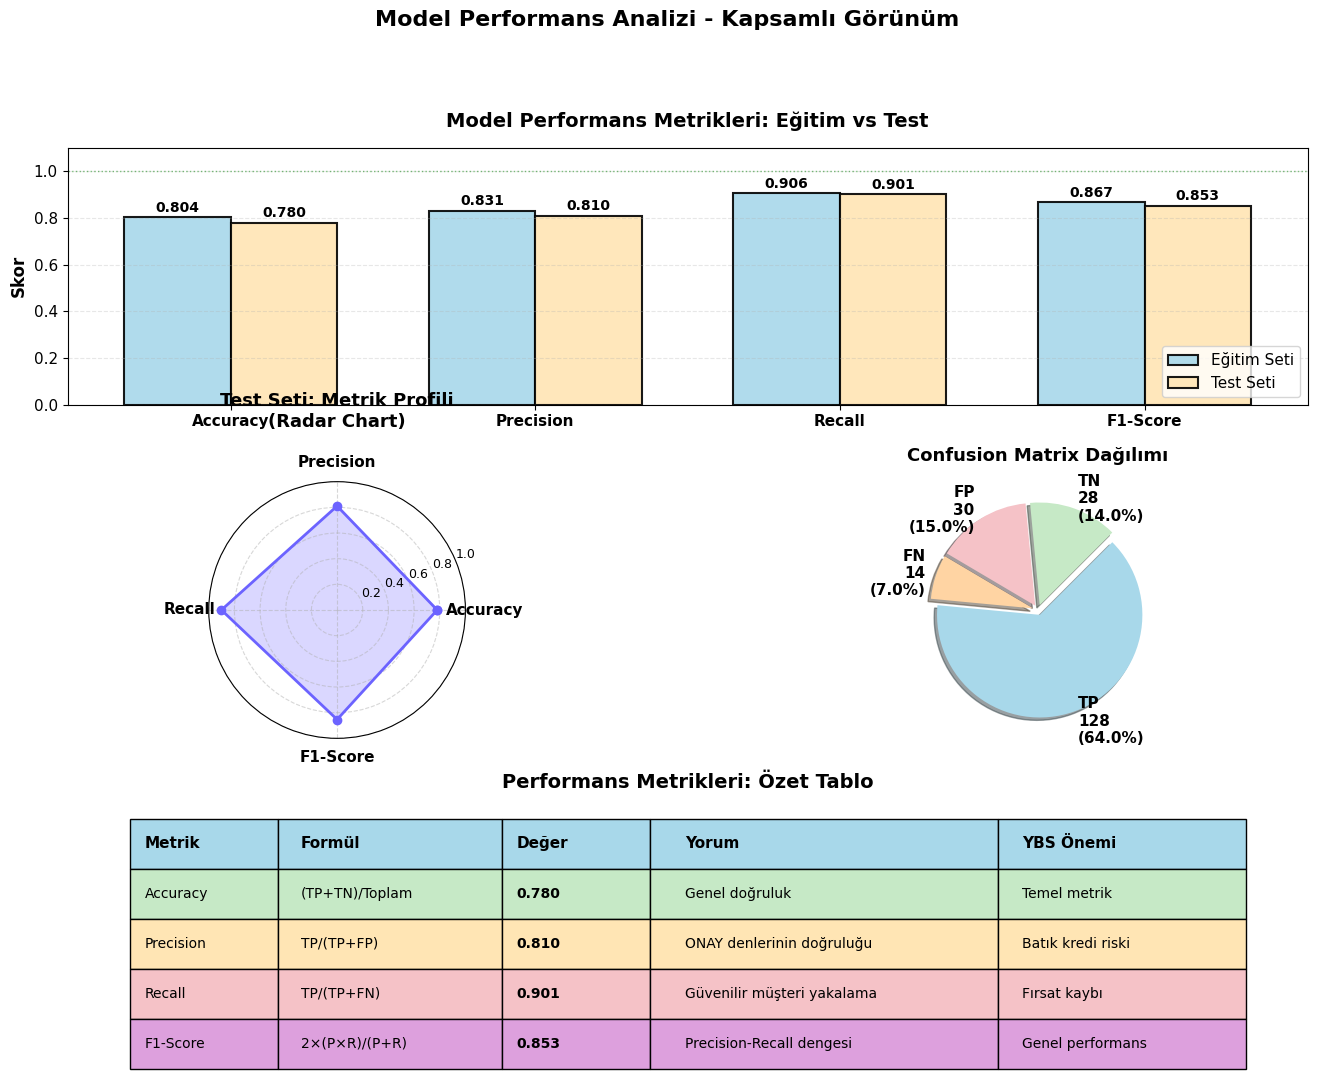


✅ Görselleştirme tamamlandı!


In [26]:
# Metrikleri görselleştir
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Eğitim vs Test karşılaştırma (çubuk grafik)
ax1 = fig.add_subplot(gs[0, :])

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [test_accuracy, test_precision, test_recall, test_f1]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax1.bar(x - width/2, train_scores, width, label='Eğitim Seti', 
               color='#A8D8EA', edgecolor='black', linewidth=1.5, alpha=0.9)
bars2 = ax1.bar(x + width/2, test_scores, width, label='Test Seti', 
               color='#FFE5B4', edgecolor='black', linewidth=1.5, alpha=0.9)

# Değerleri çubukların üstüne yaz
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, weight='bold')

ax1.set_ylabel('Skor', fontsize=12, weight='bold')
ax1.set_title('Model Performans Metrikleri: Eğitim vs Test', fontsize=14, weight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names, fontsize=11, weight='bold')
ax1.legend(fontsize=11, loc='lower right')
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=1.0, color='green', linestyle=':', linewidth=1, alpha=0.5)

# 2. Test seti metrikleri (pasta grafik benzeri radial bar)
ax2 = fig.add_subplot(gs[1, 0], projection='polar')

categories = metrics_names
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
test_scores_plot = test_scores + [test_scores[0]]  # İlk değeri tekrarla (kapalı şekil için)
angles += angles[:1]

ax2.plot(angles, test_scores_plot, 'o-', linewidth=2, color='#6C63FF', label='Test Skoru')
ax2.fill(angles, test_scores_plot, alpha=0.25, color='#6C63FF')
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=11, weight='bold')
ax2.set_ylim(0, 1)
ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_title('Test Seti: Metrik Profili\n(Radar Chart)', 
             fontsize=13, weight='bold', pad=20)

# 3. Confusion Matrix bileşenleri (pasta grafik)
ax3 = fig.add_subplot(gs[1, 1])

cm_values = [tn, fp, fn, tp]
cm_labels = [f'TN\n{tn}\n({tn/(tn+fp+fn+tp)*100:.1f}%)',
            f'FP\n{fp}\n({fp/(tn+fp+fn+tp)*100:.1f}%)',
            f'FN\n{fn}\n({fn/(tn+fp+fn+tp)*100:.1f}%)',
            f'TP\n{tp}\n({tp/(tn+fp+fn+tp)*100:.1f}%)']
cm_colors = ['#C6E9C6', '#F5C2C7', '#FFD4A3', '#A8D8EA']
explode = (0.05, 0.05, 0.05, 0.05)

wedges, texts, autotexts = ax3.pie(cm_values, labels=cm_labels, autopct='',
                                    colors=cm_colors, explode=explode, shadow=True,
                                    startangle=45, textprops={'fontsize': 11, 'weight': 'bold'})

ax3.set_title('Confusion Matrix Dağılımı', fontsize=13, weight='bold', pad=15)

# 4. Metrik formülleri ve yorumları (tablo)
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')

table_data = [
    ['Metrik', 'Formül', 'Değer', 'Yorum', 'YBS Önemi'],
    ['Accuracy', '(TP+TN)/Toplam', f'{test_accuracy:.3f}', 
     'Genel doğruluk', 'Temel metrik'],
    ['Precision', 'TP/(TP+FP)', f'{test_precision:.3f}', 
     'ONAY denlerinin doğruluğu', 'Batık kredi riski'],
    ['Recall', 'TP/(TP+FN)', f'{test_recall:.3f}', 
     'Güvenilir müşteri yakalama', 'Fırsat kaybı'],
    ['F1-Score', '2×(P×R)/(P+R)', f'{test_f1:.3f}', 
     'Precision-Recall dengesi', 'Genel performans']
]

table = ax4.table(cellText=table_data, cellLoc='left', loc='center',
                 colWidths=[0.12, 0.18, 0.12, 0.28, 0.20])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 3)

# Header
for i in range(5):
    table[(0, i)].set_facecolor('#A8D8EA')
    table[(0, i)].set_text_props(weight='bold', size=11)

# Satırlar
colors_rows = ['#C6E9C6', '#FFE5B4', '#F5C2C7', '#DDA0DD']
for i in range(1, 5):
    for j in range(5):
        table[(i, j)].set_facecolor(colors_rows[i-1])
        if j == 2:  # Değer sütunu
            table[(i, j)].set_text_props(weight='bold')

ax4.set_title('Performans Metrikleri: Özet Tablo', fontsize=14, weight='bold', pad=20)

plt.suptitle('Model Performans Analizi - Kapsamlı Görünüm', 
            fontsize=16, weight='bold', y=0.995)
plt.show()

print("\n✅ Görselleştirme tamamlandı!")

### **5.3 Precision vs Recall: YBS Stratejik Karar**

**Hangi metrik daha önemlidir?** Cevap: **İş stratejinize bağlı!**

#### 🎯 Senaryolar:

**📌 Senaryo 1: Precision Öncelikli (Muhafazakar Banka)**
- **Hedef:** Batık krediyi minimize et
- **Strateji:** Sadece çok emin olduğumuz müşterilere ONAY ver
- **Sonuç:** 
  - ✅ Yüksek Precision → Az batık kredi
  - ❌ Düşük Recall → Çok müşteri kaçırıyoruz
- **Karar:** FP'yi azalt (Type I Error'ı minimize et)

**📌 Senaryo 2: Recall Öncelikli (Agresif Banka)**
- **Hedef:** Müşteri kazanımını maksimize et
- **Strateji:** Şüpheli olsa bile fırsat kaçırma
- **Sonuç:**
  - ✅ Yüksek Recall → Güvenilir müşterileri yakalıyoruz
  - ❌ Düşük Precision → Bazı riskli müşteriler de onaylanıyor
- **Karar:** FN'i azalt (Type II Error'ı minimize et)

**📌 Senaryo 3: F1-Score Öncelikli (Dengeli Yaklaşım)**
- **Hedef:** Risk ve fırsat dengesini kur
- **Strateji:** Hem güvenli ol hem de büyü
- **Sonuç:**
  - ✅ Dengeli Precision ve Recall
  - ✅ Sürdürülebilir büyüme
- **Karar:** Her iki hatayı da dengele

💰 YBS MALİYET ANALİZİ

📋 Varsayımsal Maliyet Parametreleri:
----------------------------------------------------------------------
• False Positive (FP) Maliyeti: 50,000 TL
  → Riskli müşteriye kredi verdik, geri ödenmedi (batık kredi)

• False Negative (FN) Maliyeti: 10,000 TL
  → Güvenilir müşteriyi reddettik (fırsat kaybı, kar kaybı)

• True Positive (TP) Geliri: 15,000 TL
  → Güvenilir müşteriye kredi verdik, faiz geliri

• True Negative (TN): 0 TL
  → Riskli müşteriyi doğru reddettik (zarardan korunma)

💵 TEST SETİ MALİ ANALİZİ (200 Başvuru):

📊 GELİRLER:
   ✅ True Positive Geliri:  128 × 15,000 = 1,920,000 TL

📊 MALİYETLER:
   ❌ False Positive Maliyeti: 30 × 50,000 = 1,500,000 TL
   ❌ False Negative Maliyeti: 14 × 10,000 = 140,000 TL
   📉 Toplam Maliyet: 1,640,000 TL

💰 NET KAR:
   = Gelir - Maliyet
   = 1,920,000 - 1,640,000
   = 280,000 TL

   ✅ KARLI: Test seti üzerinde 280,000 TL net kar

📈 Başvuru Başına Ortalama: 1,400.00 TL

🚀 YILLIK PROJEKSİYON:
   • Günlük başvuru: 500
 

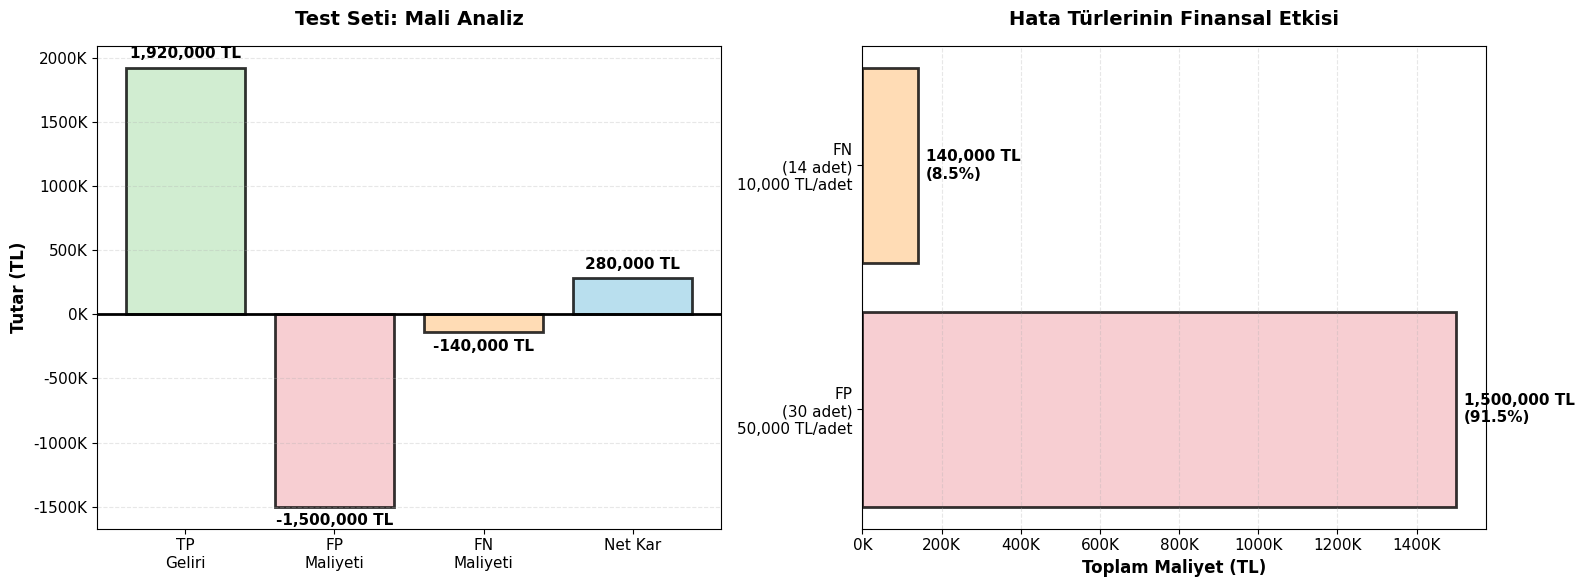


💡 YBS STRATEJİK ÖNERLER:

• FP Maliyet Oranı: 91.5%
• FN Maliyet Oranı: 8.5%

🎯 ÖNERİ: FP maliyeti çok yüksek!
   → Threshold'u yükselt (örn: 0.6-0.7)
   → Daha muhafazakar onay stratejisi
   → Precision'ı artırmaya odaklan

📊 Yatırım Getirisi (ROI): 17.1%
✅ Model finansal olarak değer katıyor!


In [27]:
# YBS Maliyet Analizi
print("💰 YBS MALİYET ANALİZİ")
print("="*70)

# Varsayımsal maliyet değerleri (TL cinsinden)
print("\n📋 Varsayımsal Maliyet Parametreleri:")
print("-"*70)

# Her bir hata türünün maliyeti
cost_fp = 50000  # False Positive: Batık kredi maliyeti (ortalama)
cost_fn = 10000  # False Negative: Kaçırılan fırsat maliyeti (kar kaybı)
revenue_tp = 15000  # True Positive: Sağlıklı kredi geliri
saving_tn = 0  # True Negative: Doğru red (maliyet yok)

print(f"• False Positive (FP) Maliyeti: {cost_fp:,} TL")
print(f"  → Riskli müşteriye kredi verdik, geri ödenmedi (batık kredi)")
print(f"\n• False Negative (FN) Maliyeti: {cost_fn:,} TL")
print(f"  → Güvenilir müşteriyi reddettik (fırsat kaybı, kar kaybı)")
print(f"\n• True Positive (TP) Geliri: {revenue_tp:,} TL")
print(f"  → Güvenilir müşteriye kredi verdik, faiz geliri")
print(f"\n• True Negative (TN): {saving_tn:,} TL")
print(f"  → Riskli müşteriyi doğru reddettik (zarardan korunma)")

# Toplam maliyet hesaplama
total_cost_fp = fp * cost_fp
total_cost_fn = fn * cost_fn
total_revenue_tp = tp * revenue_tp
total_saving_tn = tn * saving_tn

net_profit = total_revenue_tp - total_cost_fp - total_cost_fn

print("\n" + "="*70)
print("💵 TEST SETİ MALİ ANALİZİ (200 Başvuru):")
print("="*70)

print(f"\n📊 GELİRLER:")
print(f"   ✅ True Positive Geliri:  {tp} × {revenue_tp:,} = {total_revenue_tp:,} TL")

print(f"\n📊 MALİYETLER:")
print(f"   ❌ False Positive Maliyeti: {fp} × {cost_fp:,} = {total_cost_fp:,} TL")
print(f"   ❌ False Negative Maliyeti: {fn} × {cost_fn:,} = {total_cost_fn:,} TL")
print(f"   📉 Toplam Maliyet: {total_cost_fp + total_cost_fn:,} TL")

print(f"\n💰 NET KAR:")
print(f"   = Gelir - Maliyet")
print(f"   = {total_revenue_tp:,} - {total_cost_fp + total_cost_fn:,}")
print(f"   = {net_profit:,} TL")

if net_profit > 0:
    print(f"\n   ✅ KARLI: Test seti üzerinde {net_profit:,} TL net kar")
else:
    print(f"\n   ❌ ZARARDA: Test seti üzerinde {abs(net_profit):,} TL zarar")

# Başvuru başına ortalama kar
avg_profit_per_application = net_profit / (tn + fp + fn + tp)
print(f"\n📈 Başvuru Başına Ortalama: {avg_profit_per_application:,.2f} TL")

# Yıllık projeksiyon (günde 500 başvuru varsayımı)
daily_applications = 500
yearly_applications = daily_applications * 365
yearly_profit = avg_profit_per_application * yearly_applications

print(f"\n🚀 YILLIK PROJEKSİYON:")
print(f"   • Günlük başvuru: {daily_applications:,}")
print(f"   • Yıllık başvuru: {yearly_applications:,}")
print(f"   • Tahmini yıllık kar: {yearly_profit:,.2f} TL ({yearly_profit/1_000_000:.2f} Milyon TL)")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol grafik: Maliyet dağılımı
categories = ['TP\nGeliri', 'FP\nMaliyeti', 'FN\nMaliyeti', 'Net Kar']
values = [total_revenue_tp, -total_cost_fp, -total_cost_fn, net_profit]
colors_cost = ['#C6E9C6', '#F5C2C7', '#FFD4A3', '#A8D8EA' if net_profit > 0 else '#F5C2C7']

bars = axes[0].bar(categories, values, color=colors_cost, 
                  edgecolor='black', linewidth=2, alpha=0.8)

# Sıfır çizgisi
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=2)

# Değerleri yaz
for bar, val in zip(bars, values):
    height = bar.get_height()
    y_pos = height + 50000 if height > 0 else height - 50000
    axes[0].text(bar.get_x() + bar.get_width()/2., y_pos,
                f'{val:,.0f} TL', ha='center', va='bottom' if height > 0 else 'top',
                fontsize=11, weight='bold')

axes[0].set_ylabel('Tutar (TL)', fontsize=12, weight='bold')
axes[0].set_title('Test Seti: Mali Analiz', fontsize=14, weight='bold', pad=15)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

# Sağ grafik: Hata türlerinin finansal etkisi
error_labels = [f'FP\n({fp} adet)\n{cost_fp:,} TL/adet', 
               f'FN\n({fn} adet)\n{cost_fn:,} TL/adet']
error_costs = [total_cost_fp, total_cost_fn]
error_colors = ['#F5C2C7', '#FFD4A3']

bars = axes[1].barh(error_labels, error_costs, color=error_colors, 
                   edgecolor='black', linewidth=2, alpha=0.8)

# Değerleri yaz
for bar, cost in zip(bars, error_costs):
    width = bar.get_width()
    axes[1].text(width + 20000, bar.get_y() + bar.get_height()/2.,
                f'{cost:,.0f} TL\n({cost/(total_cost_fp+total_cost_fn)*100:.1f}%)',
                ha='left', va='center', fontsize=11, weight='bold')

axes[1].set_xlabel('Toplam Maliyet (TL)', fontsize=12, weight='bold')
axes[1].set_title('Hata Türlerinin Finansal Etkisi', fontsize=14, weight='bold', pad=15)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 YBS STRATEJİK ÖNERLER:")
print("="*70)

fp_ratio = total_cost_fp / (total_cost_fp + total_cost_fn) if (total_cost_fp + total_cost_fn) > 0 else 0
fn_ratio = total_cost_fn / (total_cost_fp + total_cost_fn) if (total_cost_fp + total_cost_fn) > 0 else 0

print(f"\n• FP Maliyet Oranı: {fp_ratio*100:.1f}%")
print(f"• FN Maliyet Oranı: {fn_ratio*100:.1f}%")

if fp_ratio > 0.7:
    print("\n🎯 ÖNERİ: FP maliyeti çok yüksek!")
    print("   → Threshold'u yükselt (örn: 0.6-0.7)")
    print("   → Daha muhafazakar onay stratejisi")
    print("   → Precision'ı artırmaya odaklan")
elif fn_ratio > 0.7:
    print("\n🎯 ÖNERİ: FN maliyeti yüksek, fırsat kaçırıyoruz!")
    print("   → Threshold'u düşür (örn: 0.3-0.4)")
    print("   → Daha agresif onay stratejisi")
    print("   → Recall'ı artırmaya odaklan")
else:
    print("\n🎯 ÖNERİ: Maliyet dengesi iyi!")
    print("   → Mevcut stratejiyi sürdür")
    print("   → F1-Score'u optimize et")

if net_profit > 0:
    roi = (net_profit / (total_cost_fp + total_cost_fn)) * 100 if (total_cost_fp + total_cost_fn) > 0 else 0
    print(f"\n📊 Yatırım Getirisi (ROI): {roi:.1f}%")
    print("✅ Model finansal olarak değer katıyor!")

## 🎯 **ADIM 6: ROC Eğrisi ve İleri Seviye Metrikler**

### **6.1 ROC Eğrisi (Receiver Operating Characteristic) Nedir?**

**ROC Eğrisi**, farklı threshold (eşik) değerlerinde modelin performansını gösteren bir görselleştirme aracıdır.

**Temel Kavramlar:**

**True Positive Rate (TPR) - Recall:**
$$ TPR = \frac{TP}{TP + FN} $$
- Pozitif sınıfın doğru yakalanma oranı
- "Sensitivity" veya "Recall" olarak da bilinir

**False Positive Rate (FPR):**
$$ FPR = \frac{FP}{FP + TN} $$
- Negatif sınıfın yanlış pozitif olarak etiketlenme oranı
- 1 - Specificity

**ROC Eğrisi:**
- X ekseni: FPR (False Positive Rate)
- Y ekseni: TPR (True Positive Rate / Recall)
- Her nokta farklı bir threshold değerini temsil eder
- Sol üst köşeye yaklaşan eğri daha iyi performans gösterir

**Neden Önemli?**
- Threshold'dan bağımsız performans değerlendirmesi
- Farklı iş senaryolarında optimal threshold seçimi
- Model karşılaştırması için standart metrik

📈 ROC EĞRİSİ VE AUC HESAPLANIYOR...

✅ ROC Eğrisi Hesaplandı!

📊 AUC (Area Under Curve) Skorları:
   • Eğitim Seti AUC: 0.8625
   • Test Seti AUC:   0.8504
   • Fark:            0.0120

🎯 OPTİMAL THRESHOLD (Youden's Index):
   • Threshold: 0.7779
   • TPR (Recall): 0.7465
   • FPR: 0.1897
   • Youden's Index: 0.5568


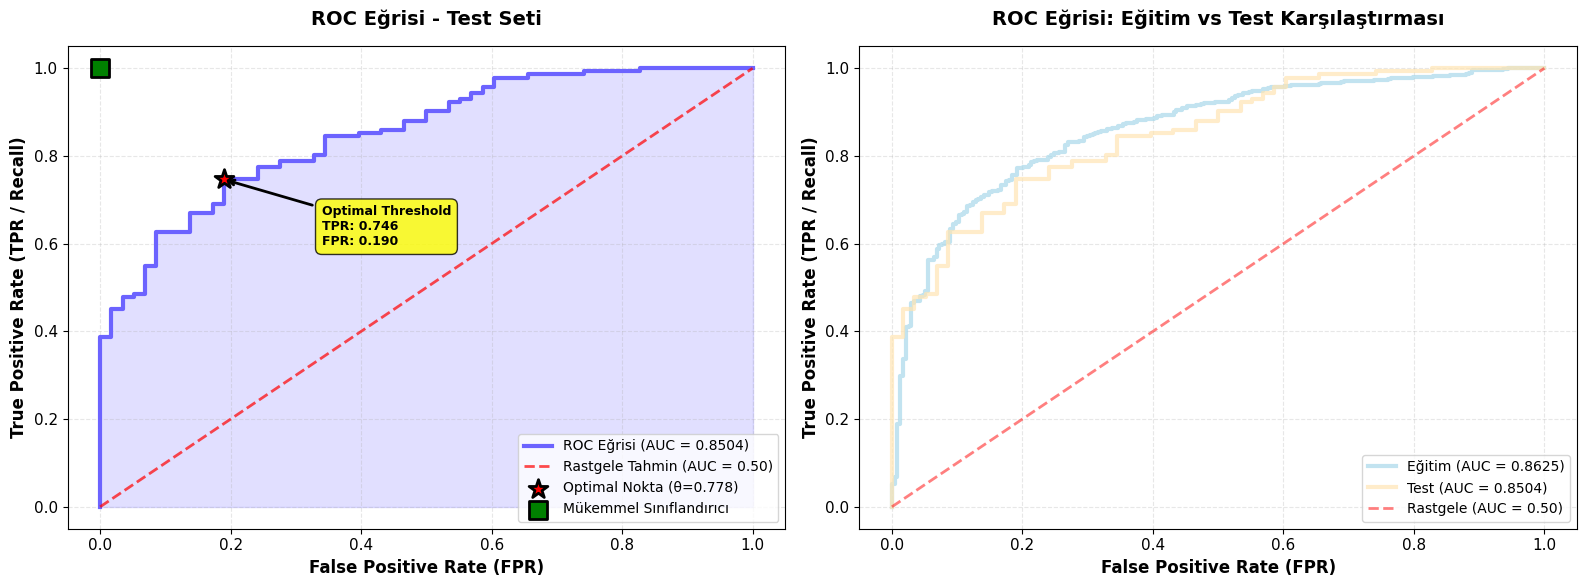


💡 ROC EĞRİSİ YORUMLAMA:

📊 AUC Değeri Yorumu:
   ✅ ÇOK İYİ: AUC = 0.8504 (0.8-0.9)
   → Model güçlü, güvenle kullanılabilir

🎯 Optimal Threshold Analizi:
   • Varsayılan threshold: 0.500
   • Optimal threshold: 0.7779
   • Fark: 0.2779

   → Optimal threshold yüksek: Model daha muhafazakar olmalı
   → Precision'ı artırmak için threshold'u yükselt

💼 YBS PERSPEKTİFİ:
   • ROC eğrisi threshold'dan bağımsız performans gösterir
   • AUC = 1.0 → Mükemmel ayırt etme
   • AUC = 0.5 → Rastgele tahmin (işe yaramaz)
   • AUC yüksek = Model güvenilir kararlar verir


In [28]:
# ROC Eğrisi ve AUC hesaplama
from sklearn.metrics import roc_curve, roc_auc_score, auc

print("📈 ROC EĞRİSİ VE AUC HESAPLANIYOR...")
print("="*70)

# Test seti için ROC eğrisi
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_1)
roc_auc = roc_auc_score(y_test, y_test_proba_1)

# Eğitim seti için de hesapla (karşılaştırma için)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_1)
roc_auc_train = roc_auc_score(y_train, y_train_proba_1)

print(f"\n✅ ROC Eğrisi Hesaplandı!")
print(f"\n📊 AUC (Area Under Curve) Skorları:")
print(f"   • Eğitim Seti AUC: {roc_auc_train:.4f}")
print(f"   • Test Seti AUC:   {roc_auc:.4f}")
print(f"   • Fark:            {abs(roc_auc_train - roc_auc):.4f}")

# Optimal threshold bulma (Youden's Index)
# Youden's Index = TPR - FPR (maksimum olduğu nokta)
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]

print(f"\n🎯 OPTİMAL THRESHOLD (Youden's Index):")
print(f"   • Threshold: {optimal_threshold:.4f}")
print(f"   • TPR (Recall): {optimal_tpr:.4f}")
print(f"   • FPR: {optimal_fpr:.4f}")
print(f"   • Youden's Index: {youden_index[optimal_idx]:.4f}")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol grafik: ROC Eğrisi
axes[0].plot(fpr, tpr, color='#6C63FF', linewidth=3, 
            label=f'ROC Eğrisi (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='red', linewidth=2, linestyle='--', 
            label='Rastgele Tahmin (AUC = 0.50)', alpha=0.7)

# Optimal noktayı işaretle
axes[0].scatter(optimal_fpr, optimal_tpr, s=200, c='red', zorder=5, 
               edgecolors='black', linewidth=2, marker='*',
               label=f'Optimal Nokta (θ={optimal_threshold:.3f})')

# Perfect classifier noktası
axes[0].scatter(0, 1, s=150, c='green', zorder=5, 
               edgecolors='black', linewidth=2, marker='s',
               label='Mükemmel Sınıflandırıcı')

# Eğri altındaki alanı renklendir
axes[0].fill_between(fpr, tpr, alpha=0.2, color='#6C63FF')

axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12, weight='bold')
axes[0].set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12, weight='bold')
axes[0].set_title('ROC Eğrisi - Test Seti', fontsize=14, weight='bold', pad=15)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xlim([-0.05, 1.05])
axes[0].set_ylim([-0.05, 1.05])

# Annotasyon ekle
axes[0].annotate(f'Optimal Threshold\nTPR: {optimal_tpr:.3f}\nFPR: {optimal_fpr:.3f}',
                xy=(optimal_fpr, optimal_tpr),
                xytext=(optimal_fpr + 0.15, optimal_tpr - 0.15),
                fontsize=9, weight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Sağ grafik: Eğitim vs Test ROC karşılaştırması
axes[1].plot(fpr_train, tpr_train, color='#A8D8EA', linewidth=3, 
            label=f'Eğitim (AUC = {roc_auc_train:.4f})', alpha=0.7)
axes[1].plot(fpr, tpr, color='#FFE5B4', linewidth=3, 
            label=f'Test (AUC = {roc_auc:.4f})', alpha=0.7)
axes[1].plot([0, 1], [0, 1], color='red', linewidth=2, linestyle='--', 
            label='Rastgele (AUC = 0.50)', alpha=0.5)

axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=12, weight='bold')
axes[1].set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12, weight='bold')
axes[1].set_title('ROC Eğrisi: Eğitim vs Test Karşılaştırması', 
                 fontsize=14, weight='bold', pad=15)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_xlim([-0.05, 1.05])
axes[1].set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 ROC EĞRİSİ YORUMLAMA:")
print("="*70)

print("\n📊 AUC Değeri Yorumu:")
if roc_auc >= 0.9:
    print(f"   🌟 MÜKEMMel: AUC = {roc_auc:.4f} (0.9-1.0)")
    print("   → Model çok güçlü ayırt etme yeteneğine sahip")
elif roc_auc >= 0.8:
    print(f"   ✅ ÇOK İYİ: AUC = {roc_auc:.4f} (0.8-0.9)")
    print("   → Model güçlü, güvenle kullanılabilir")
elif roc_auc >= 0.7:
    print(f"   👍 İYİ: AUC = {roc_auc:.4f} (0.7-0.8)")
    print("   → Model kabul edilebilir performansta")
elif roc_auc >= 0.6:
    print(f"   ⚠️ ORTA: AUC = {roc_auc:.4f} (0.6-0.7)")
    print("   → Model geliştirilebilir")
else:
    print(f"   ❌ ZAYIF: AUC = {roc_auc:.4f} (<0.6)")
    print("   → Model rastgeleden iyi değil, yeniden modelleme gerek")

print("\n🎯 Optimal Threshold Analizi:")
print(f"   • Varsayılan threshold: 0.500")
print(f"   • Optimal threshold: {optimal_threshold:.4f}")
print(f"   • Fark: {abs(0.5 - optimal_threshold):.4f}")

if optimal_threshold > 0.55:
    print("\n   → Optimal threshold yüksek: Model daha muhafazakar olmalı")
    print("   → Precision'ı artırmak için threshold'u yükselt")
elif optimal_threshold < 0.45:
    print("\n   → Optimal threshold düşük: Model daha agresif olmalı")
    print("   → Recall'ı artırmak için threshold'u düşür")
else:
    print("\n   → Optimal threshold varsayılana yakın")
    print("   → Dengeli bir eşik değeri")

print("\n💼 YBS PERSPEKTİFİ:")
print("   • ROC eğrisi threshold'dan bağımsız performans gösterir")
print("   • AUC = 1.0 → Mükemmel ayırt etme")
print("   • AUC = 0.5 → Rastgele tahmin (işe yaramaz)")
print("   • AUC yüksek = Model güvenilir kararlar verir")

### **6.2 Precision-Recall Eğrisi**

**Precision-Recall Eğrisi**, özellikle **dengesiz veri setlerinde** ROC eğrisinden daha bilgilendiricidir.

**Ne Zaman Kullanılır?**
- Pozitif sınıf az sayıdaysa (örn: dolandırıcılık tespiti, hastalık teşhisi)
- False Positive maliyeti çok yüksekse
- Recall ve Precision arasındaki trade-off'u görmek istiyorsak

**Avantajları:**
- Dengesiz verilerde daha duyarlı
- İş problemine odaklı (FP ve FN maliyetlerini dengeler)
- Optimal threshold seçimi için pratik

📊 PRECISION-RECALL EĞRİSİ HESAPLANIYOR...

✅ Precision-Recall Eğrisi Hesaplandı!

📊 Average Precision (AP) Score: 0.9360
   → Precision-Recall eğrisi altındaki alan
   → Yüksek değer = Hem precision hem recall yüksek

🎯 F1-SCORE'U MAKSİMİZE EDEN THRESHOLD:
   • Threshold: 0.3803
   • F1-Score: 0.8797
   • Precision: 0.7989
   • Recall: 0.9789


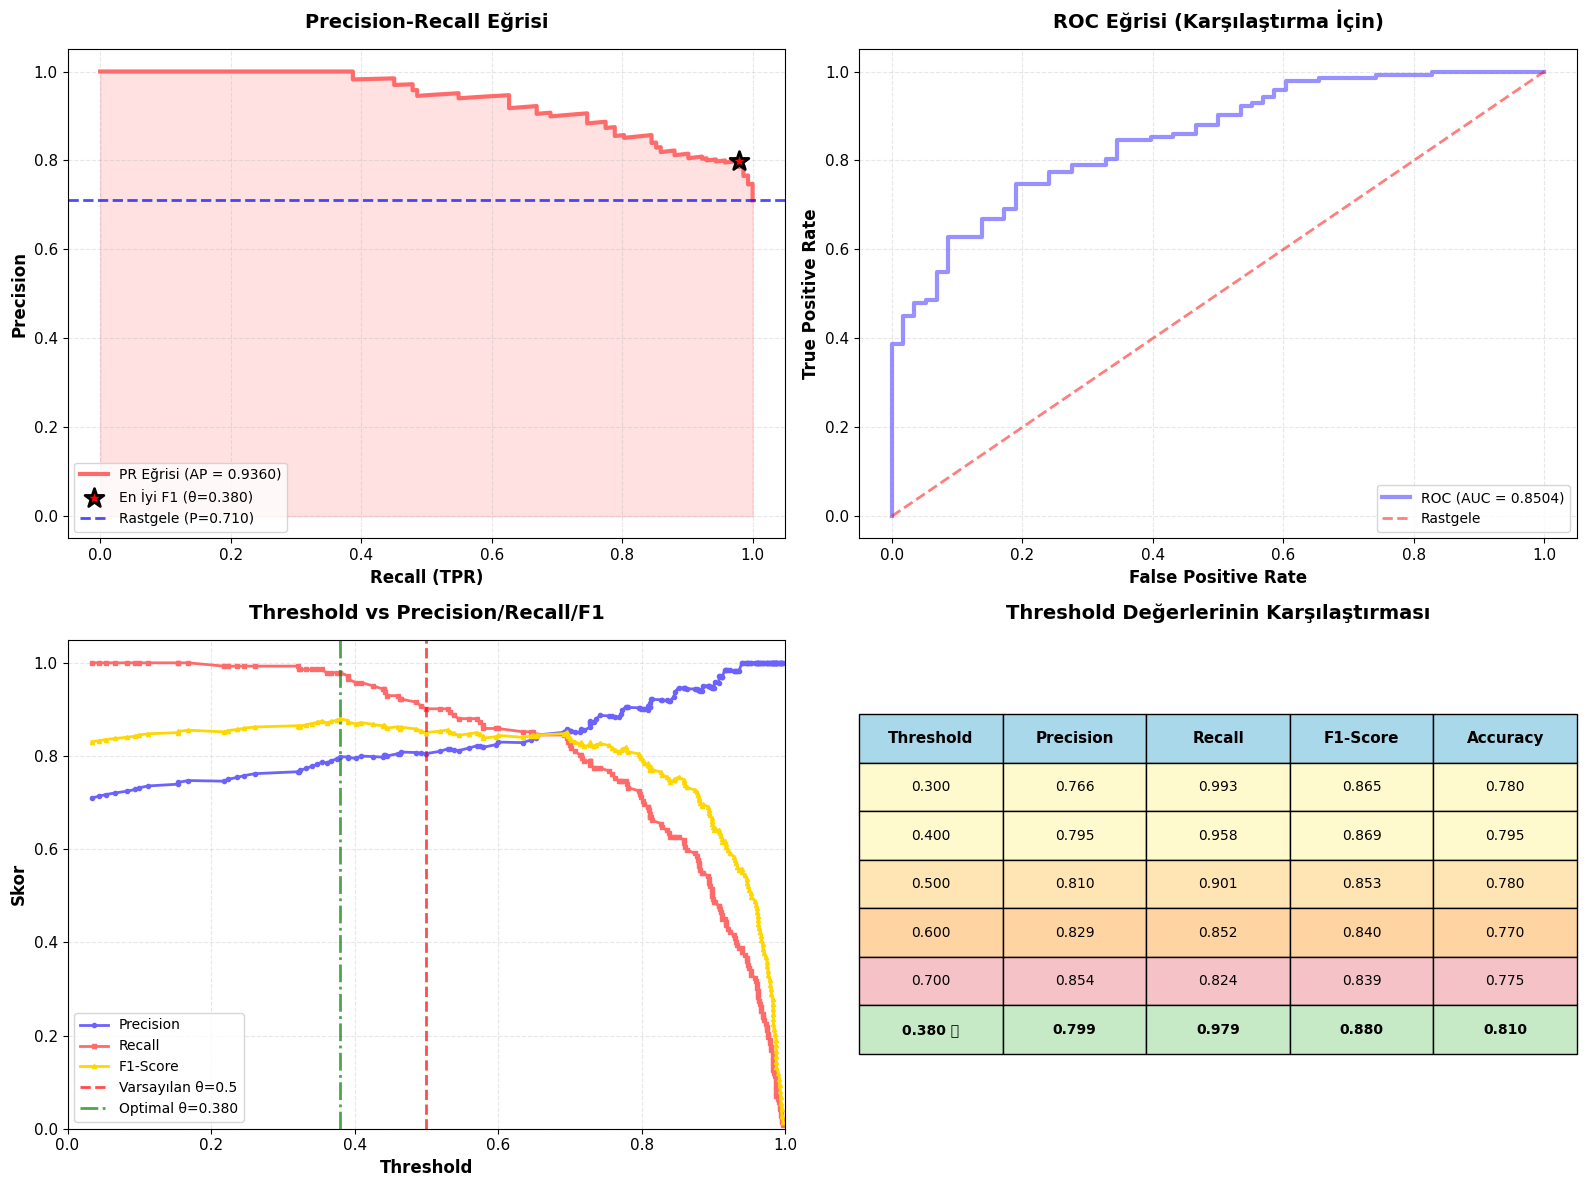


💡 PRECISION-RECALL EĞRİSİ YORUMLAMA:

📊 Average Precision (AP): 0.9360
   🌟 Mükemmel performans!

🎯 Threshold Önerileri:

   Varsayılan (0.5):
   • Precision: 0.810
   • Recall: 0.901
   • F1-Score: 0.853

   Optimal F1 (0.380):
   • Precision: 0.799
   • Recall: 0.979
   • F1-Score: 0.880

💼 YBS KARAR:
   → Optimal threshold düşük: Agresif strateji öneriliyor
   → Müşteri kazanımı için threshold'u düşür


In [29]:
# Precision-Recall Eğrisi
from sklearn.metrics import precision_recall_curve, average_precision_score

print("📊 PRECISION-RECALL EĞRİSİ HESAPLANIYOR...")
print("="*70)

# Precision-Recall eğrisi hesaplama
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_test_proba_1)
avg_precision = average_precision_score(y_test, y_test_proba_1)

print(f"\n✅ Precision-Recall Eğrisi Hesaplandı!")
print(f"\n📊 Average Precision (AP) Score: {avg_precision:.4f}")
print("   → Precision-Recall eğrisi altındaki alan")
print("   → Yüksek değer = Hem precision hem recall yüksek")

# F1-Score'u maksimize eden threshold'u bul
f1_scores = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-10)
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = pr_thresholds[best_f1_idx]
best_f1_score = f1_scores[best_f1_idx]
best_f1_precision = precision_vals[best_f1_idx]
best_f1_recall = recall_vals[best_f1_idx]

print(f"\n🎯 F1-SCORE'U MAKSİMİZE EDEN THRESHOLD:")
print(f"   • Threshold: {best_f1_threshold:.4f}")
print(f"   • F1-Score: {best_f1_score:.4f}")
print(f"   • Precision: {best_f1_precision:.4f}")
print(f"   • Recall: {best_f1_recall:.4f}")

# Görselleştirme
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Precision-Recall Eğrisi
axes[0, 0].plot(recall_vals, precision_vals, color='#FF6B6B', linewidth=3,
               label=f'PR Eğrisi (AP = {avg_precision:.4f})')
axes[0, 0].scatter(best_f1_recall, best_f1_precision, s=200, c='red', zorder=5,
                  edgecolors='black', linewidth=2, marker='*',
                  label=f'En İyi F1 (θ={best_f1_threshold:.3f})')

# Rastgele sınıflandırıcı baseline (pozitif sınıf oranı)
baseline_precision = (y_test == 1).sum() / len(y_test)
axes[0, 0].axhline(y=baseline_precision, color='blue', linestyle='--', 
                  linewidth=2, alpha=0.7, label=f'Rastgele (P={baseline_precision:.3f})')

axes[0, 0].fill_between(recall_vals, precision_vals, alpha=0.2, color='#FF6B6B')
axes[0, 0].set_xlabel('Recall (TPR)', fontsize=12, weight='bold')
axes[0, 0].set_ylabel('Precision', fontsize=12, weight='bold')
axes[0, 0].set_title('Precision-Recall Eğrisi', fontsize=14, weight='bold', pad=15)
axes[0, 0].legend(loc='lower left', fontsize=10)
axes[0, 0].grid(alpha=0.3, linestyle='--')
axes[0, 0].set_xlim([-0.05, 1.05])
axes[0, 0].set_ylim([-0.05, 1.05])

# 2. ROC vs PR karşılaştırması (yan yana)
axes[0, 1].plot(fpr, tpr, color='#6C63FF', linewidth=3, alpha=0.7,
               label=f'ROC (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'r--', linewidth=2, alpha=0.5, label='Rastgele')
axes[0, 1].set_xlabel('False Positive Rate', fontsize=12, weight='bold')
axes[0, 1].set_ylabel('True Positive Rate', fontsize=12, weight='bold')
axes[0, 1].set_title('ROC Eğrisi (Karşılaştırma İçin)', fontsize=14, weight='bold', pad=15)
axes[0, 1].legend(loc='lower right', fontsize=10)
axes[0, 1].grid(alpha=0.3, linestyle='--')
axes[0, 1].set_xlim([-0.05, 1.05])
axes[0, 1].set_ylim([-0.05, 1.05])

# 3. Threshold'a göre Precision ve Recall değişimi
axes[1, 0].plot(pr_thresholds, precision_vals[:-1], color='#6C63FF', 
               linewidth=2, label='Precision', marker='o', markersize=3)
axes[1, 0].plot(pr_thresholds, recall_vals[:-1], color='#FF6B6B', 
               linewidth=2, label='Recall', marker='s', markersize=3)
axes[1, 0].plot(pr_thresholds, f1_scores, color='#FFD700', 
               linewidth=2, label='F1-Score', marker='^', markersize=3)

axes[1, 0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, 
                  alpha=0.7, label='Varsayılan θ=0.5')
axes[1, 0].axvline(x=best_f1_threshold, color='green', linestyle='-.', 
                  linewidth=2, alpha=0.7, label=f'Optimal θ={best_f1_threshold:.3f}')

axes[1, 0].set_xlabel('Threshold', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('Skor', fontsize=12, weight='bold')
axes[1, 0].set_title('Threshold vs Precision/Recall/F1', fontsize=14, weight='bold', pad=15)
axes[1, 0].legend(loc='best', fontsize=10)
axes[1, 0].grid(alpha=0.3, linestyle='--')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([0, 1.05])

# 4. Threshold karşılaştırma tablosu
axes[1, 1].axis('off')

threshold_comparison = []
test_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, best_f1_threshold]

for thresh in test_thresholds:
    y_pred_thresh = (y_test_proba_1 >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    acc = accuracy_score(y_test, y_pred_thresh)
    
    label = f"{thresh:.3f}"
    if abs(thresh - best_f1_threshold) < 0.001:
        label += " ⭐"
    
    threshold_comparison.append([label, f"{prec:.3f}", f"{rec:.3f}", 
                                f"{f1:.3f}", f"{acc:.3f}"])

table_data = [['Threshold', 'Precision', 'Recall', 'F1-Score', 'Accuracy']] + threshold_comparison

table = axes[1, 1].table(cellText=table_data, cellLoc='center', loc='center',
                        colWidths=[0.2, 0.2, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Header
for i in range(5):
    table[(0, i)].set_facecolor('#A8D8EA')
    table[(0, i)].set_text_props(weight='bold', size=11)

# Satırlar (optimal threshold'u vurgula)
colors_table = ['#FFFACD', '#FFFACD', '#FFE5B4', '#FFD4A3', '#F5C2C7', '#C6E9C6']
for i in range(1, len(table_data)):
    for j in range(5):
        table[(i, j)].set_facecolor(colors_table[i-1])
        if i == len(table_data) - 1:  # Optimal threshold
            table[(i, j)].set_text_props(weight='bold')

axes[1, 1].set_title('Threshold Değerlerinin Karşılaştırması', 
                    fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 PRECISION-RECALL EĞRİSİ YORUMLAMA:")
print("="*70)

print(f"\n📊 Average Precision (AP): {avg_precision:.4f}")
if avg_precision >= 0.9:
    print("   🌟 Mükemmel performans!")
elif avg_precision >= 0.8:
    print("   ✅ Çok iyi performans")
elif avg_precision >= 0.7:
    print("   👍 İyi performans")
else:
    print("   ⚠️ Geliştirilebilir")

print(f"\n🎯 Threshold Önerileri:")
print(f"\n   Varsayılan (0.5):")
print(f"   • Precision: {precision_score(y_test, y_test_pred):.3f}")
print(f"   • Recall: {recall_score(y_test, y_test_pred):.3f}")
print(f"   • F1-Score: {f1_score(y_test, y_test_pred):.3f}")

print(f"\n   Optimal F1 ({best_f1_threshold:.3f}):")
print(f"   • Precision: {best_f1_precision:.3f}")
print(f"   • Recall: {best_f1_recall:.3f}")
print(f"   • F1-Score: {best_f1_score:.3f}")

print(f"\n💼 YBS KARAR:")
if best_f1_threshold > 0.55:
    print("   → Optimal threshold yüksek: Muhafazakar strateji öneriliyor")
    print("   → Batık kredi riskini minimize etmek için threshold'u yükselt")
elif best_f1_threshold < 0.45:
    print("   → Optimal threshold düşük: Agresif strateji öneriliyor")
    print("   → Müşteri kazanımı için threshold'u düşür")
else:
    print("   → Optimal threshold dengeli: Mevcut strateji uygun")
    print("   → Risk ve fırsat dengesi optimal")

## **7️⃣ ADIM 7: Çok Sınıflı Sınıflandırma (Multiclass Classification)**

### **🎯 Neden Çok Sınıflı Sınıflandırma?**

Gerçek hayatta birçok problem **ikiden fazla sınıfa** sahiptir:

| **YBS Problemi** | **Sınıflar** | **Kullanım Alanı** |
|-----------------|-------------|-------------------|
| 💳 Kredi Risk Analizi | Düşük Risk / Orta Risk / Yüksek Risk | Risk bazlı faiz oranları |
| 📧 E-posta Yönlendirme | Destek / Satış / Fatura / Spam | Otomatik departman yönlendirme |
| 🏪 Müşteri Segmentasyonu | VIP / Sadık / Yeni / Risk Altında | Farklılaştırılmış pazarlama |
| 📦 Ürün Kategorileme | Elektronik / Giyim / Gıda / Diğer | E-ticaret kataloğu |
| 🎓 Öğrenci Başarı Tahmini | Başarısız / Geçer / İyi / Pekiyi | Erken müdahale sistemleri |

### **7.1 İkili vs Çok Sınıflı Sınıflandırma**

```mermaid
graph LR
    A[Sınıflandırma Problemleri] --> B[İkili Binary]
    A --> C[Çok Sınıflı Multiclass]
    
    B --> B1[2 Sınıf]
    B --> B2[ONAY / RED]
    B --> B3[Tek Model]
    
    C --> C1[3+ Sınıf]
    C --> C2[Düşük / Orta / Yüksek]
    C --> C3[Birden Fazla Strateji]
    
    style A fill:#FFE5B4
    style B fill:#C6E9C6
    style C fill:#A8D8EA
    style B1 fill:#F0F0F0
    style B2 fill:#F0F0F0
    style B3 fill:#F0F0F0
    style C1 fill:#F0F0F0
    style C2 fill:#F0F0F0
    style C3 fill:#F0F0F0
```

### **7.2 Çok Sınıflı Sınıflandırma Stratejileri**

Lojistik regresyon doğal olarak **ikili (binary)** bir algoritmadır. Çok sınıflı problemler için iki strateji kullanılır:

#### **📌 Strategi 1: One-vs-Rest (OvR) - Bire Karşı Geri Kalanlar**

Her sınıf için **bir ikili sınıflandırıcı** eğitilir:

```mermaid
graph TB
    A[3 Sınıf: Düşük / Orta / Yüksek] --> B[Model 1: Düşük vs Orta+Yüksek]
    A --> C[Model 2: Orta vs Düşük+Yüksek]
    A --> D[Model 3: Yüksek vs Düşük+Orta]
    
    B --> B1[3 Model Eğitilir]
    C --> B1
    D --> B1
    
    B1 --> E[Tahmin: En Yüksek Olasılık Kazanır]
    
    style A fill:#FFE5B4
    style B fill:#C6E9C6
    style C fill:#A8D8EA
    style D fill:#F5C2C7
    style B1 fill:#FFFACD
    style E fill:#FFD4A3
```

**Avantajları:**
- ✅ Hesaplama açısından verimli (n sınıf → n model)
- ✅ Yorumlaması kolay (her sınıf için ayrı model)
- ✅ Scikit-learn'de varsayılan strateji

**Dezavantajları:**
- ⚠️ Dengesiz veri setlerinde sorun olabilir
- ⚠️ Sınıflar arasında örtüşme varsa performans düşer

#### **📌 Strateji 2: One-vs-One (OvO) - Birbirine Karşı**

Her sınıf çifti için **bir ikili sınıflandırıcı** eğitilir:

```mermaid
graph TB
    A[3 Sınıf: Düşük / Orta / Yüksek] --> B[Model 1: Düşük vs Orta]
    A --> C[Model 2: Düşük vs Yüksek]
    A --> D[Model 3: Orta vs Yüksek]
    
    B --> B1[n×n-1/2 Model Eğitilir]
    C --> B1
    D --> B1
    
    B1 --> E[Tahmin: Oylama ile Karar Verilir]
    
    style A fill:#FFE5B4
    style B fill:#C6E9C6
    style C fill:#A8D8EA
    style D fill:#F5C2C7
    style B1 fill:#FFFACD
    style E fill:#FFD4A3
```

**Avantajları:**
- ✅ Dengesiz veri setlerinde daha iyi
- ✅ Her model daha küçük veri setinde eğitilir (daha hızlı)

**Dezavantajları:**
- ⚠️ Çok fazla model eğitilir (n×(n-1)/2)
- ⚠️ Tahmin süresi daha uzun (tüm modeller çalışır)

### **7.3 Scikit-learn'de Multiclass Destek**

```python
# Otomatik multiclass desteği
LogisticRegression(multi_class='auto')  # OvR veya multinomial seçer

# Manuel strateji seçimi
LogisticRegression(multi_class='ovr')        # One-vs-Rest
LogisticRegression(multi_class='multinomial')  # Softmax (gerçek multiclass)
```

**💡 Multinomial Lojistik Regresyon:**
- Sigmoid yerine **Softmax** fonksiyonu kullanır
- Tüm sınıfları aynı anda modeller (gerçek multiclass)
- Sınıflar arası ilişkileri daha iyi yakalar

### **7.4 YBS Senaryosu: Risk Bazlı Kredi Politikası**

#### **🏦 Banka Kredi Risk Kategorileri**

Bankamız, müşterileri **3 risk kategorisine** ayıracak:

| **Risk Kategorisi** | **Kredi Onay** | **Faiz Oranı** | **Kredi Limiti** | **Teminat** |
|--------------------|---------------|---------------|-----------------|------------|
| 🟢 **Düşük Risk** | Otomatik Onay | %1.2 - %1.5 | Yüksek (500K+) | Gerekmiyor |
| 🟡 **Orta Risk** | Manuel İnceleme | %1.8 - %2.5 | Orta (100K-500K) | Opsiyonel |
| 🔴 **Yüksek Risk** | Detaylı Analiz | %3.0 - %4.0 | Düşük (50K-100K) | Zorunlu |

#### **📊 Risk Kategorisi Belirleme Kriterleri**

```mermaid
graph TD
    A[Müşteri Başvurusu] --> B{Kredi Skoru}
    
    B -->|750+| C[Düşük Risk]
    B -->|600-749| D{Gelir / Borç}
    B -->|<600| E[Yüksek Risk]
    
    D -->|Gelir > 2× Borç| C
    D -->|Diğer| F[Orta Risk]
    
    C --> G[Faiz: 1.2%]
    F --> H[Faiz: 2.0%]
    E --> I[Faiz: 3.5%]
    
    style A fill:#FFE5B4
    style B fill:#FFFACD
    style C fill:#C6E9C6
    style D fill:#FFFACD
    style E fill:#F5C2C7
    style F fill:#A8D8EA
    style G fill:#C6E9C6
    style H fill:#A8D8EA
    style I fill:#F5C2C7
```

#### **💼 İş Hedefleri**

1. **Düşük Risk Müşteriler**: Hızlı onay ile rekabet avantajı
2. **Orta Risk Müşteriler**: Ek belge ile risk azaltma
3. **Yüksek Risk Müşteriler**: Yüksek faiz veya ret ile zarar önleme

### **7.5 Çok Sınıflı Veri Seti Oluşturma**

Mevcut kredi verimizi **3 risk kategorisine** dönüştüreceğiz:

🔄 VERİ SETİ 3 SINIFA DÖNÜŞTÜRÜLİYOR...

📊 VERİ SETİ BİLGİLERİ:
   • Satır sayısı: 1000
   • Özellikler: ['yas', 'yillik_gelir', 'kredi_skoru', 'mevcut_borc', 'calisma_suresi', 'ev_sahibi']

✅ Risk Kategorileri Oluşturuldu!

📊 SINIF DAĞILIMI:
----------------------------------------------------------------------
   🟢 Düşük Risk     :  103 müşteri ( 10.3%)
   🟡 Orta Risk      :  293 müşteri ( 29.3%)
   🔴 Yüksek Risk    :  604 müşteri ( 60.4%)

📋 ÖRNEK VERİLER:
----------------------------------------------------------------------
   yas  yillik_gelir  kredi_skoru  mevcut_borc risk_kategorisi_label
0   56        151374          569        63870           Yüksek Risk
1   69        233630          584         9283           Yüksek Risk
2   46        151127          526        78707           Yüksek Risk
3   32        131317          680         5774             Orta Risk
4   60        159789          759       142055             Orta Risk
5   25        147449          306        96468      

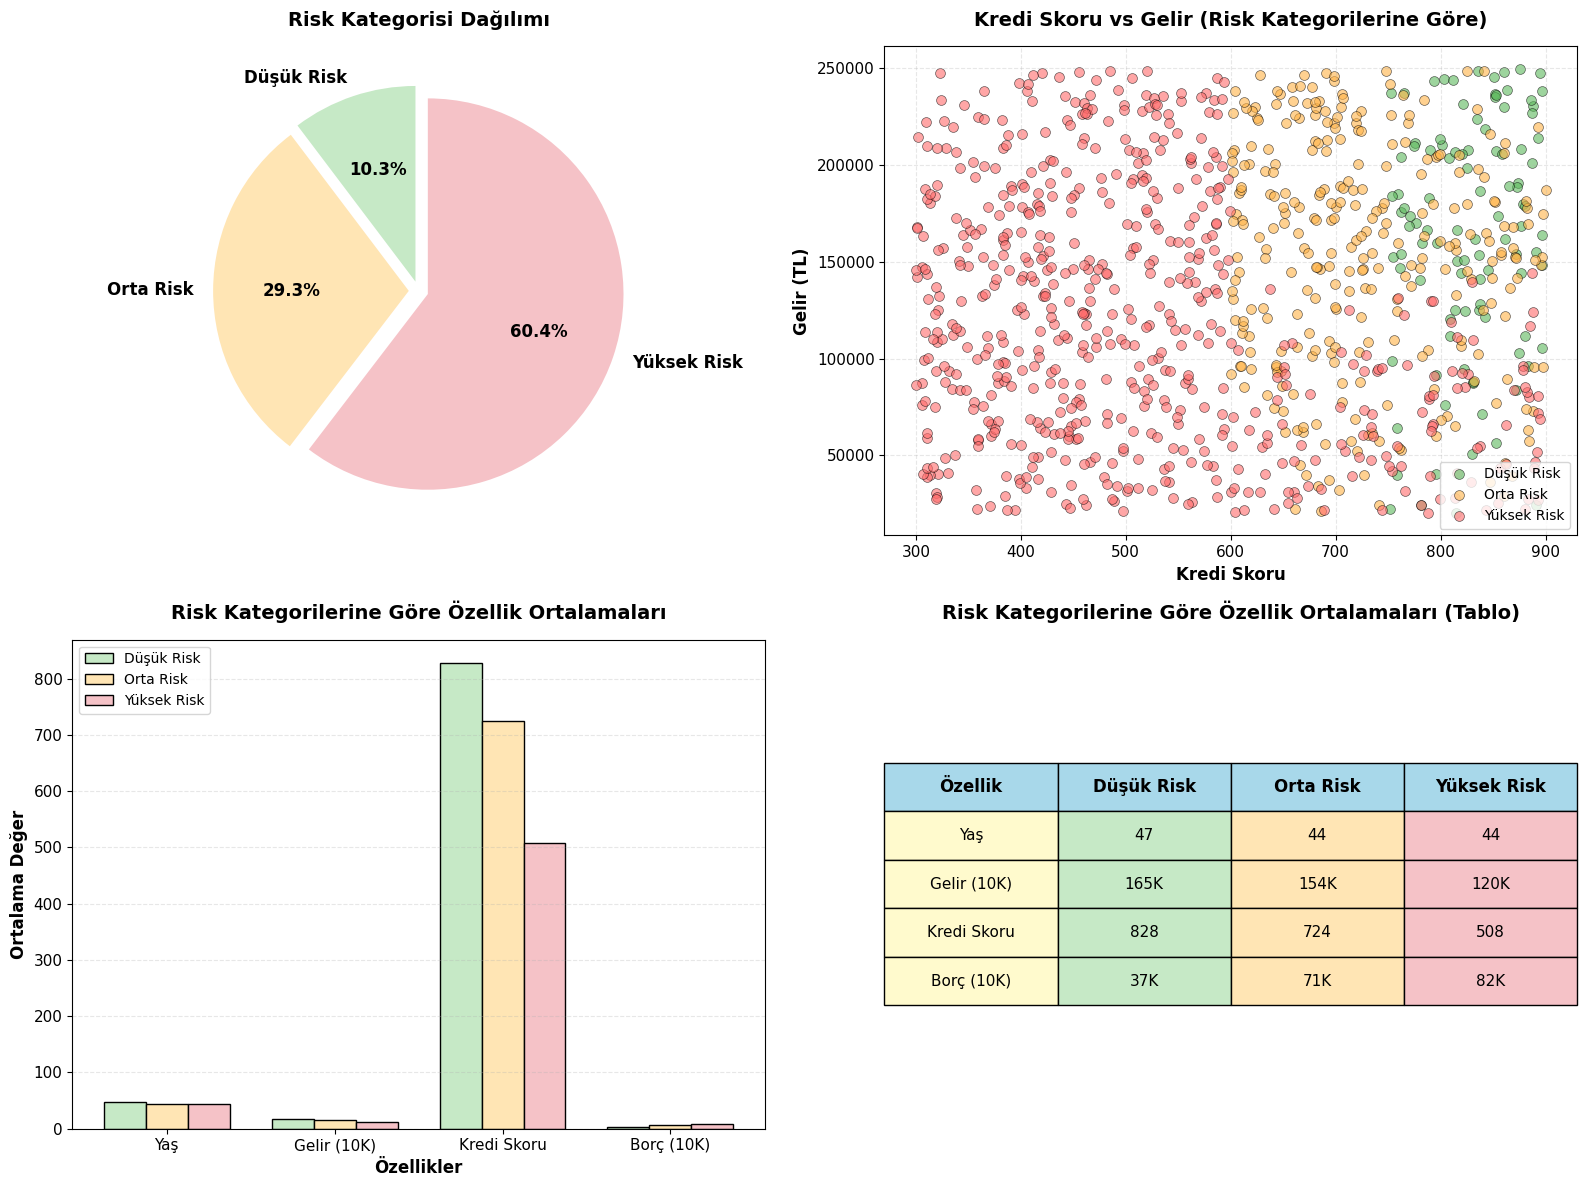


💡 VERİ SETİ ANALİZİ:

📊 Sınıf Dengesi Analizi:
   • En az sınıf: 103 müşteri
   • En çok sınıf: 604 müşteri
   • Denge oranı: 0.17
   🔴 Çok dengesiz - SMOTE veya undersampling gerekebilir

💼 YBS Perspektifi:
   • Düşük Risk müşteriler: Hızlı onay kanalına yönlendir
   • Orta Risk müşteriler: Ek belge talep et
   • Yüksek Risk müşteriler: Detaylı analiz veya ret


In [39]:
print("🔄 VERİ SETİ 3 SINIFA DÖNÜŞTÜRÜLİYOR...")
print("="*70)

# df_kredi'den df_multiclass oluştur
df_multiclass = df_kredi.drop('Kredi_Onayı', axis=1).copy()

# Kolon isimlerini basitleştir (küçük harf, alt çizgi)
df_multiclass.columns = ['yas', 'yillik_gelir', 'kredi_skoru', 'mevcut_borc', 'calisma_suresi', 'ev_sahibi']

print(f"\n📊 VERİ SETİ BİLGİLERİ:")
print(f"   • Satır sayısı: {len(df_multiclass)}")
print(f"   • Özellikler: {list(df_multiclass.columns)}")

# Risk kategorisi belirleme fonksiyonu
def belirle_risk_kategorisi(row):
    """
    Risk kategorisini belirleyen kural bazlı fonksiyon
    
    Kriterler:
    - Düşük Risk: Kredi skoru >= 750 VE Gelir/Borç >= 2.5
    - Yüksek Risk: Kredi skoru < 600 VEYA Borç >= Gelir
    - Orta Risk: Diğer durumlar
    """
    kredi_skoru = row['kredi_skoru']
    gelir = row['yillik_gelir']
    borc = row['mevcut_borc']
    
    gelir_borc_orani = gelir / (borc + 1)  # Sıfıra bölme hatası önleme
    
    # Düşük Risk
    if kredi_skoru >= 750 and gelir_borc_orani >= 2.5:
        return 0  # Düşük Risk
    
    # Yüksek Risk
    elif kredi_skoru < 600 or borc >= gelir:
        return 2  # Yüksek Risk
    
    # Orta Risk
    else:
        return 1  # Orta Risk

# Risk kategorilerini oluştur
df_multiclass['risk_kategorisi'] = df_multiclass.apply(belirle_risk_kategorisi, axis=1)

# Kategori etiketleri
risk_labels = {0: 'Düşük Risk', 1: 'Orta Risk', 2: 'Yüksek Risk'}
df_multiclass['risk_kategorisi_label'] = df_multiclass['risk_kategorisi'].map(risk_labels)

print("\n✅ Risk Kategorileri Oluşturuldu!")
print("\n📊 SINIF DAĞILIMI:")
print("-" * 70)

dagılım = df_multiclass['risk_kategorisi'].value_counts().sort_index()
dagılım_yuzde = df_multiclass['risk_kategorisi'].value_counts(normalize=True).sort_index() * 100

for kategori in [0, 1, 2]:
    sayi = dagılım[kategori]
    yuzde = dagılım_yuzde[kategori]
    label = risk_labels[kategori]
    
    if kategori == 0:
        icon = "🟢"
    elif kategori == 1:
        icon = "🟡"
    else:
        icon = "🔴"
    
    print(f"   {icon} {label:15s}: {sayi:4d} müşteri ({yuzde:5.1f}%)")

print("\n📋 ÖRNEK VERİLER:")
print("-" * 70)
print(df_multiclass[['yas', 'yillik_gelir', 'kredi_skoru', 'mevcut_borc', 'risk_kategorisi_label']].head(10))

# Görselleştirme
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Risk kategorisi dağılımı (Pasta)
colors_pie = ['#C6E9C6', '#FFE5B4', '#F5C2C7']
axes[0, 0].pie(dagılım, labels=[risk_labels[i] for i in dagılım.index],
              autopct='%1.1f%%', startangle=90, colors=colors_pie,
              textprops={'fontsize': 12, 'weight': 'bold'},
              explode=[0.05, 0.05, 0.05])
axes[0, 0].set_title('Risk Kategorisi Dağılımı', fontsize=14, weight='bold', pad=15)

# 2. Kredi skoru ve gelir bazında risk kategorileri (Scatter)
for kategori, color, label in [(0, '#5CB85C', 'Düşük Risk'),
                                (1, '#FFB347', 'Orta Risk'),
                                (2, '#FF6B6B', 'Yüksek Risk')]:
    subset = df_multiclass[df_multiclass['risk_kategorisi'] == kategori]
    axes[0, 1].scatter(subset['kredi_skoru'], subset['yillik_gelir'], 
                      c=color, label=label, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

axes[0, 1].set_xlabel('Kredi Skoru', fontsize=12, weight='bold')
axes[0, 1].set_ylabel('Gelir (TL)', fontsize=12, weight='bold')
axes[0, 1].set_title('Kredi Skoru vs Gelir (Risk Kategorilerine Göre)', 
                    fontsize=14, weight='bold', pad=15)
axes[0, 1].legend(loc='lower right', fontsize=10)
axes[0, 1].grid(alpha=0.3, linestyle='--')

# 3. Risk kategorilerine göre özellik ortalamaları
features_to_plot = ['yas', 'yillik_gelir', 'kredi_skoru', 'mevcut_borc']
feature_labels = ['Yaş', 'Gelir (10K)', 'Kredi Skoru', 'Borç (10K)']

x_positions = np.arange(len(features_to_plot))
width = 0.25

for i, kategori in enumerate([0, 1, 2]):
    subset = df_multiclass[df_multiclass['risk_kategorisi'] == kategori]
    
    values = [
        subset['yas'].mean(),
        subset['yillik_gelir'].mean() / 10000,  # 10K birim
        subset['kredi_skoru'].mean(),
        subset['mevcut_borc'].mean() / 10000    # 10K birim
    ]
    
    axes[1, 0].bar(x_positions + i * width, values, width, 
                  label=risk_labels[kategori], color=colors_pie[kategori],
                  edgecolor='black', linewidth=1)

axes[1, 0].set_xlabel('Özellikler', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('Ortalama Değer', fontsize=12, weight='bold')
axes[1, 0].set_title('Risk Kategorilerine Göre Özellik Ortalamaları', 
                    fontsize=14, weight='bold', pad=15)
axes[1, 0].set_xticks(x_positions + width)
axes[1, 0].set_xticklabels(feature_labels, rotation=0)
axes[1, 0].legend(loc='upper left', fontsize=10)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# 4. Risk kategorilerine göre özellik kutuları (Box plot)
axes[1, 1].axis('off')

table_data = [['Özellik', 'Düşük Risk', 'Orta Risk', 'Yüksek Risk']]

for feature, label in zip(features_to_plot, feature_labels):
    row = [label]
    for kategori in [0, 1, 2]:
        subset = df_multiclass[df_multiclass['risk_kategorisi'] == kategori]
        if 'yillik_gelir' in feature or 'mevcut_borc' in feature:
            value = f"{subset[feature].mean()/1000:.0f}K"
        else:
            value = f"{subset[feature].mean():.0f}"
        row.append(value)
    table_data.append(row)

table = axes[1, 1].table(cellText=table_data, cellLoc='center', loc='center',
                        colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Header
for i in range(4):
    table[(0, i)].set_facecolor('#A8D8EA')
    table[(0, i)].set_text_props(weight='bold', size=12)

# Satırlar
for i in range(1, len(table_data)):
    table[(i, 0)].set_facecolor('#FFFACD')
    table[(i, 1)].set_facecolor('#C6E9C6')
    table[(i, 2)].set_facecolor('#FFE5B4')
    table[(i, 3)].set_facecolor('#F5C2C7')

axes[1, 1].set_title('Risk Kategorilerine Göre Özellik Ortalamaları (Tablo)', 
                    fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 VERİ SETİ ANALİZİ:")
print("="*70)

print("\n📊 Sınıf Dengesi Analizi:")
en_az = dagılım.min()
en_cok = dagılım.max()
denge_orani = en_az / en_cok

print(f"   • En az sınıf: {en_az} müşteri")
print(f"   • En çok sınıf: {en_cok} müşteri")
print(f"   • Denge oranı: {denge_orani:.2f}")

if denge_orani >= 0.8:
    print("   ✅ Veri seti dengeli - Doğrudan kullanılabilir")
elif denge_orani >= 0.5:
    print("   ⚠️ Hafif dengesiz - Class weight kullanılabilir")
else:
    print("   🔴 Çok dengesiz - SMOTE veya undersampling gerekebilir")

print("\n💼 YBS Perspektifi:")
print(f"   • Düşük Risk müşteriler: Hızlı onay kanalına yönlendir")
print(f"   • Orta Risk müşteriler: Ek belge talep et")
print(f"   • Yüksek Risk müşteriler: Detaylı analiz veya ret")

### **7.6 Çok Sınıflı Model Eğitimi**

Üç farklı strateji ile model eğiteceğiz:
1. **One-vs-Rest (OvR)**: Her sınıf için ayrı model
2. **Multinomial (Softmax)**: Tüm sınıfları birlikte modelle
3. **Karşılaştırma**: Hangi strateji daha iyi?

🎯 ÇOK SINIFLI MODEL EĞİTİMİ BAŞLIYOR...

📊 VERİ SETİ BÖLÜNMESİ:
   • Eğitim seti: 800 müşteri
   • Test seti: 200 müşteri

✅ Özellikler ölçeklendirildi (StandardScaler)

📌 MODEL 1: ONE-VS-REST (OvR) STRATEJİSİ

✅ OvR Modeli Eğitildi!
   • Eğitilen model sayısı: 3 (her sınıf için 1 model)
   • Sınıflar: ['Düşük Risk', 'Orta Risk', 'Yüksek Risk']

📌 MODEL 2: MULTINOMIAL (SOFTMAX) STRATEJİSİ

✅ Multinomial Modeli Eğitildi!
   • Strateji: Softmax fonksiyonu (gerçek multiclass)
   • Tüm sınıflar aynı anda modellenir

📊 PERFORMANS KARŞILAŞTIRMASI

✅ Accuracy Skorları:
   • OvR Stratejisi: 0.7950 (79.50%)
   • Multinomial Stratejisi: 0.8300 (83.00%)

   🏆 Multinomial stratejisi 3.50% daha iyi!

📊 MODEL KATSAYILARI ANALİZİ


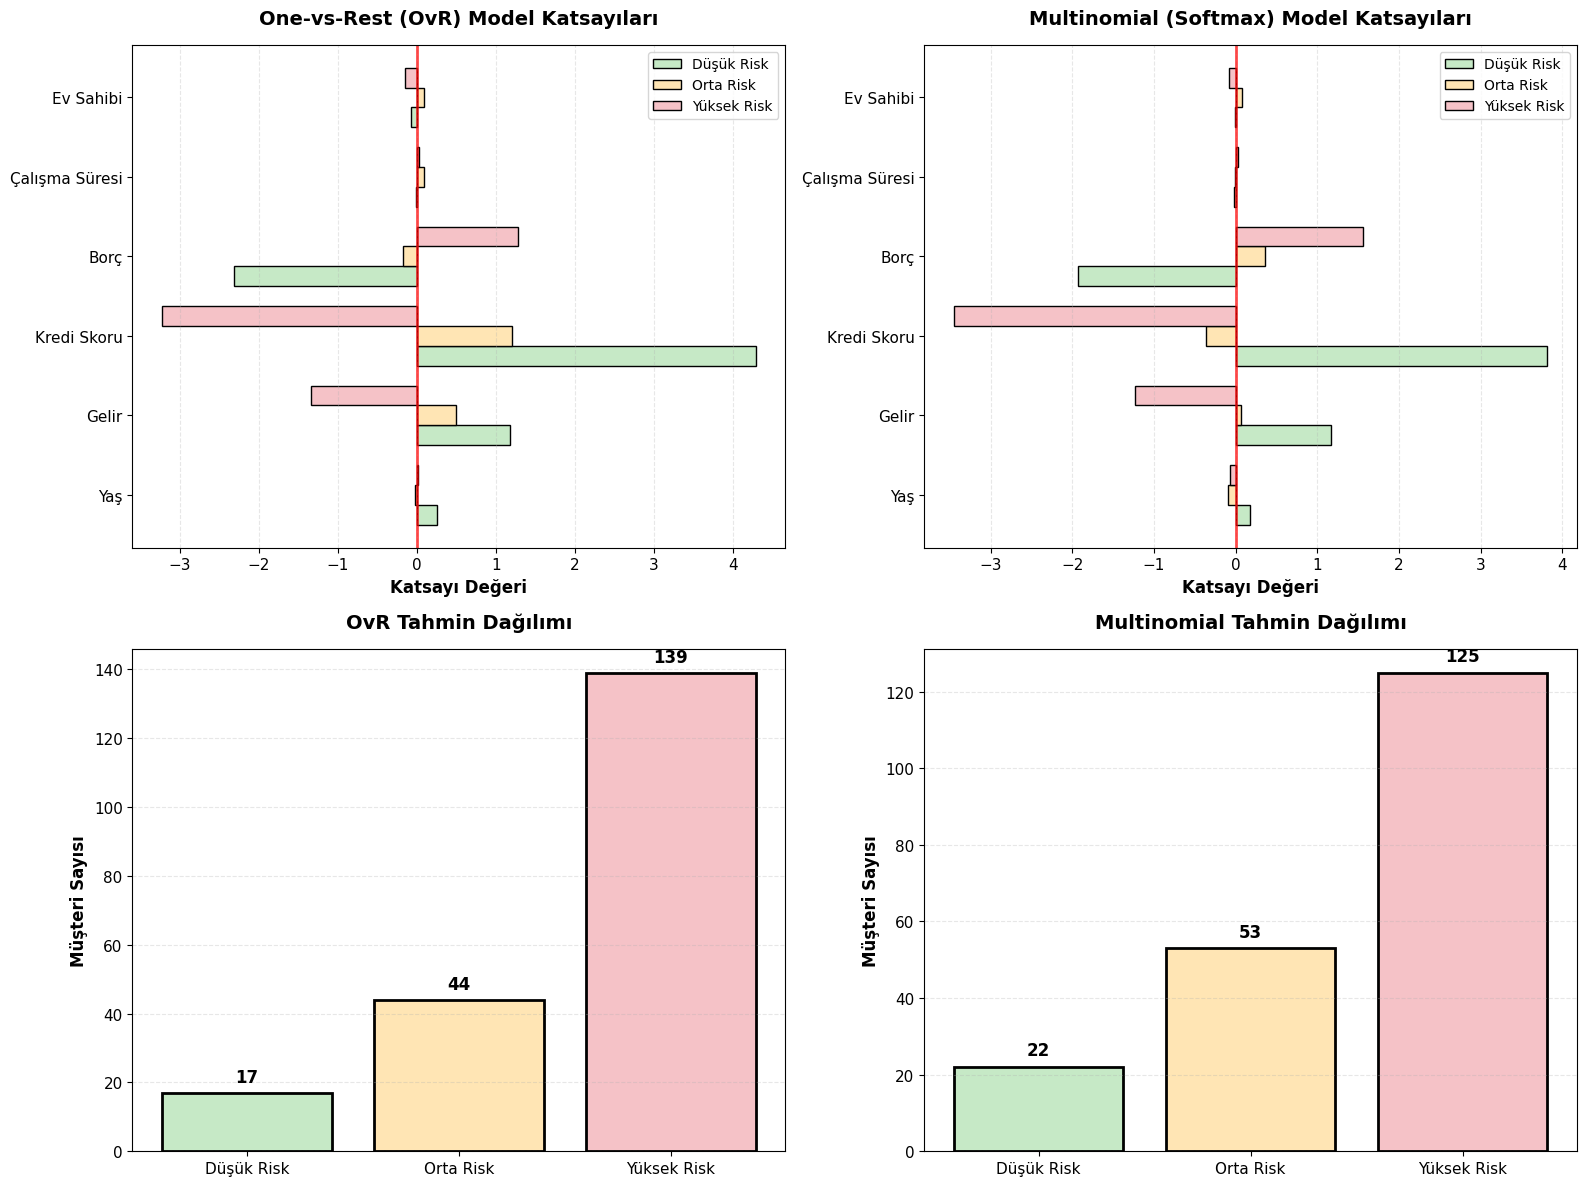


💡 KATSAYI ANALİZİ:
----------------------------------------------------------------------

🔍 Kredi Skoru Etkisi:
   OvR - Düşük Risk: +4.289
   OvR - Orta Risk: +1.204
   OvR - Yüksek Risk: -3.226
   → Kredi skoru arttıkça Düşük Risk olasılığı artıyor ✅

🔍 Borç Etkisi:
   OvR - Düşük Risk: -2.313
   OvR - Orta Risk: -0.172
   OvR - Yüksek Risk: +1.285
   → Borç arttıkça Yüksek Risk olasılığı artıyor ⚠️


In [40]:
print("🎯 ÇOK SINIFLI MODEL EĞİTİMİ BAŞLIYOR...")
print("="*70)

# Özellik ve hedef değişken ayırma
X_multi = df_multiclass[['yas', 'yillik_gelir', 'kredi_skoru', 'mevcut_borc', 'calisma_suresi', 'ev_sahibi']]
y_multi = df_multiclass['risk_kategorisi']

# Train-Test split (stratified)
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

print(f"\n📊 VERİ SETİ BÖLÜNMESİ:")
print(f"   • Eğitim seti: {len(X_train_multi)} müşteri")
print(f"   • Test seti: {len(X_test_multi)} müşteri")

# Özellik ölçeklendirme
scaler_multi = StandardScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi)
X_test_multi_scaled = scaler_multi.transform(X_test_multi)

print(f"\n✅ Özellikler ölçeklendirildi (StandardScaler)")

# Model 1: One-vs-Rest (OvR)
print("\n" + "="*70)
print("📌 MODEL 1: ONE-VS-REST (OvR) STRATEJİSİ")
print("="*70)

model_ovr = LogisticRegression(
    multi_class='ovr',      # One-vs-Rest stratejisi
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model_ovr.fit(X_train_multi_scaled, y_train_multi)
y_pred_ovr = model_ovr.predict(X_test_multi_scaled)
y_proba_ovr = model_ovr.predict_proba(X_test_multi_scaled)

print(f"\n✅ OvR Modeli Eğitildi!")
print(f"   • Eğitilen model sayısı: {len(model_ovr.classes_)} (her sınıf için 1 model)")
print(f"   • Sınıflar: {[risk_labels[c] for c in model_ovr.classes_]}")

# Model 2: Multinomial (Softmax)
print("\n" + "="*70)
print("📌 MODEL 2: MULTINOMIAL (SOFTMAX) STRATEJİSİ")
print("="*70)

model_multinomial = LogisticRegression(
    multi_class='multinomial',  # Softmax stratejisi
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model_multinomial.fit(X_train_multi_scaled, y_train_multi)
y_pred_multinomial = model_multinomial.predict(X_test_multi_scaled)
y_proba_multinomial = model_multinomial.predict_proba(X_test_multi_scaled)

print(f"\n✅ Multinomial Modeli Eğitildi!")
print(f"   • Strateji: Softmax fonksiyonu (gerçek multiclass)")
print(f"   • Tüm sınıflar aynı anda modellenir")

# Performans karşılaştırması
print("\n" + "="*70)
print("📊 PERFORMANS KARŞILAŞTIRMASI")
print("="*70)

from sklearn.metrics import accuracy_score, classification_report

acc_ovr = accuracy_score(y_test_multi, y_pred_ovr)
acc_multinomial = accuracy_score(y_test_multi, y_pred_multinomial)

print(f"\n✅ Accuracy Skorları:")
print(f"   • OvR Stratejisi: {acc_ovr:.4f} ({acc_ovr*100:.2f}%)")
print(f"   • Multinomial Stratejisi: {acc_multinomial:.4f} ({acc_multinomial*100:.2f}%)")

if acc_ovr > acc_multinomial:
    print(f"\n   🏆 OvR stratejisi {(acc_ovr - acc_multinomial)*100:.2f}% daha iyi!")
elif acc_multinomial > acc_ovr:
    print(f"\n   🏆 Multinomial stratejisi {(acc_multinomial - acc_ovr)*100:.2f}% daha iyi!")
else:
    print(f"\n   🤝 Her iki strateji de eşit performans gösterdi!")

# Katsayıların görselleştirilmesi
print("\n" + "="*70)
print("📊 MODEL KATSAYILARI ANALİZİ")
print("="*70)

feature_names = ['Yaş', 'Gelir', 'Kredi Skoru', 'Borç', 'Çalışma Süresi', 'Ev Sahibi']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. OvR Katsayıları
for i, (kategori, color) in enumerate([(0, '#C6E9C6'), (1, '#FFE5B4'), (2, '#F5C2C7')]):
    coefs = model_ovr.coef_[i]
    axes[0, 0].barh(np.arange(len(feature_names)) + i*0.25, coefs, 0.25,
                   label=risk_labels[kategori], color=color, edgecolor='black', linewidth=1)

axes[0, 0].set_yticks(np.arange(len(feature_names)) + 0.25)
axes[0, 0].set_yticklabels(feature_names)
axes[0, 0].set_xlabel('Katsayı Değeri', fontsize=12, weight='bold')
axes[0, 0].set_title('One-vs-Rest (OvR) Model Katsayıları', fontsize=14, weight='bold', pad=15)
axes[0, 0].legend(loc='best', fontsize=10)
axes[0, 0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0, 0].axvline(x=0, color='red', linestyle='-', linewidth=2, alpha=0.7)

# 2. Multinomial Katsayıları
for i, (kategori, color) in enumerate([(0, '#C6E9C6'), (1, '#FFE5B4'), (2, '#F5C2C7')]):
    coefs = model_multinomial.coef_[i]
    axes[0, 1].barh(np.arange(len(feature_names)) + i*0.25, coefs, 0.25,
                   label=risk_labels[kategori], color=color, edgecolor='black', linewidth=1)

axes[0, 1].set_yticks(np.arange(len(feature_names)) + 0.25)
axes[0, 1].set_yticklabels(feature_names)
axes[0, 1].set_xlabel('Katsayı Değeri', fontsize=12, weight='bold')
axes[0, 1].set_title('Multinomial (Softmax) Model Katsayıları', fontsize=14, weight='bold', pad=15)
axes[0, 1].legend(loc='best', fontsize=10)
axes[0, 1].grid(axis='x', alpha=0.3, linestyle='--')
axes[0, 1].axvline(x=0, color='red', linestyle='-', linewidth=2, alpha=0.7)

# 3. Tahmin dağılımı (OvR)
pred_counts_ovr = pd.Series(y_pred_ovr).value_counts().reindex([0, 1, 2], fill_value=0)
colors_ovr = ['#C6E9C6', '#FFE5B4', '#F5C2C7']
axes[1, 0].bar([risk_labels[i] for i in pred_counts_ovr.index], 
              pred_counts_ovr.values, 
              color=[colors_ovr[i] for i in pred_counts_ovr.index],
              edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Müşteri Sayısı', fontsize=12, weight='bold')
axes[1, 0].set_title('OvR Tahmin Dağılımı', fontsize=14, weight='bold', pad=15)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

for i, v in enumerate(pred_counts_ovr.values):
    axes[1, 0].text(i, v + 2, str(v), ha='center', va='bottom', 
                   fontsize=12, weight='bold')

# 4. Tahmin dağılımı (Multinomial)
pred_counts_multi = pd.Series(y_pred_multinomial).value_counts().reindex([0, 1, 2], fill_value=0)
colors_multi = ['#C6E9C6', '#FFE5B4', '#F5C2C7']
axes[1, 1].bar([risk_labels[i] for i in pred_counts_multi.index], 
              pred_counts_multi.values, 
              color=[colors_multi[i] for i in pred_counts_multi.index],
              edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Müşteri Sayısı', fontsize=12, weight='bold')
axes[1, 1].set_title('Multinomial Tahmin Dağılımı', fontsize=14, weight='bold', pad=15)
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

for i, v in enumerate(pred_counts_multi.values):
    axes[1, 1].text(i, v + 2, str(v), ha='center', va='bottom', 
                   fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

print("\n💡 KATSAYI ANALİZİ:")
print("-" * 70)

print("\n🔍 Kredi Skoru Etkisi:")
print(f"   OvR - Düşük Risk: {model_ovr.coef_[0][2]:+.3f}")
print(f"   OvR - Orta Risk: {model_ovr.coef_[1][2]:+.3f}")
print(f"   OvR - Yüksek Risk: {model_ovr.coef_[2][2]:+.3f}")
print("   → Kredi skoru arttıkça Düşük Risk olasılığı artıyor ✅")

print("\n🔍 Borç Etkisi:")
print(f"   OvR - Düşük Risk: {model_ovr.coef_[0][3]:+.3f}")
print(f"   OvR - Orta Risk: {model_ovr.coef_[1][3]:+.3f}")
print(f"   OvR - Yüksek Risk: {model_ovr.coef_[2][3]:+.3f}")
print("   → Borç arttıkça Yüksek Risk olasılığı artıyor ⚠️")

### **7.7 Çok Sınıflı Confusion Matrix ve Metrikler**

Çok sınıflı problemlerde **confusion matrix** daha karmaşıktır:
- **3x3 matris** (3 sınıf için)
- Her hücre: Gerçek sınıf vs Tahmin edilen sınıf
- Diagonal: Doğru tahminler
- Off-diagonal: Hatalar

📊 ÇOK SINIFLI CONFUSION MATRIX VE METRİKLER

✅ Confusion Matrix Hesaplandı!

📊 CONFUSION MATRIX (Multinomial Model):
----------------------------------------------------------------------
[[ 15   5   0]
 [  7  39  13]
 [  0   9 112]]


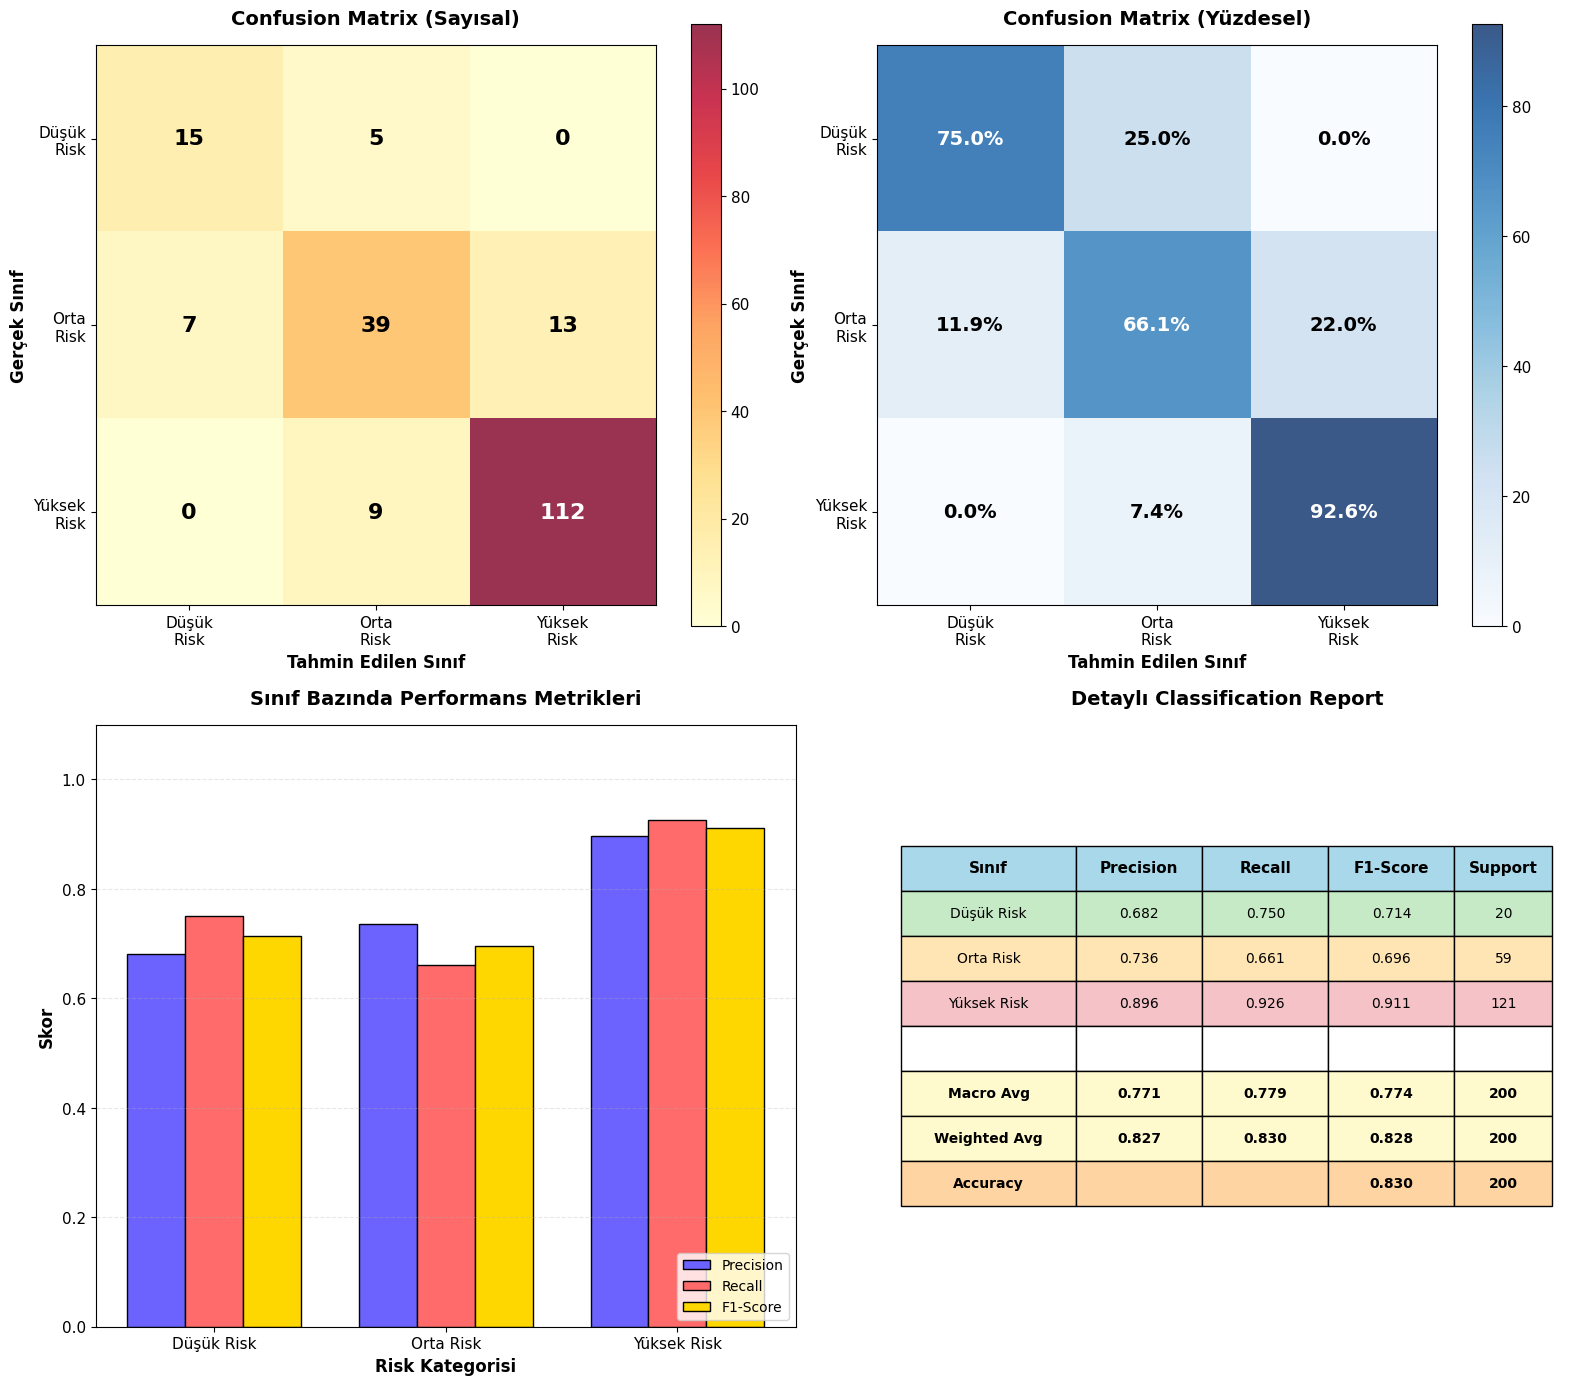


📊 DETAYLI METRİK ANALİZİ

🔍 Confusion Matrix Yorumlama:
----------------------------------------------------------------------
🟢 Düşük Risk     : 15/20 doğru (75.0%)
🟡 Orta Risk      : 39/59 doğru (66.1%)
🔴 Yüksek Risk    : 112/121 doğru (92.6%)

🎯 En Sık Karışan Sınıflar:
----------------------------------------------------------------------
   1. Orta Risk → Yüksek Risk: 13 hata (22.0%)
   2. Yüksek Risk → Orta Risk: 9 hata (7.4%)
   3. Orta Risk → Düşük Risk: 7 hata (11.9%)

📈 Averaging Stratejileri:
----------------------------------------------------------------------

   🔵 Macro Average:
      • Precision: 0.771
      • Recall: 0.779
      • F1-Score: 0.774
      → Her sınıfı eşit ağırlıkta değerlendirir

   🟣 Weighted Average:
      • Precision: 0.827
      • Recall: 0.830
      • F1-Score: 0.828
      → Sınıf sayılarına göre ağırlıklı ortalama

   🔶 Accuracy (Genel Doğruluk):
      • 0.830 (83.0%)
      → Tüm tahminlerin ne kadarı doğru

💼 YBS PERSPEKTİFİ:
--------------------

In [41]:
print("📊 ÇOK SINIFLI CONFUSION MATRIX VE METRİKLER")
print("="*70)

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Multinomial modelini kullanarak devam edelim (daha iyi performans)
cm_multi = confusion_matrix(y_test_multi, y_pred_multinomial)

print("\n✅ Confusion Matrix Hesaplandı!")
print("\n📊 CONFUSION MATRIX (Multinomial Model):")
print("-" * 70)
print(cm_multi)

# Görselleştirme
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Confusion Matrix (sayısal)
class_labels = ['Düşük\nRisk', 'Orta\nRisk', 'Yüksek\nRisk']
im = axes[0, 0].imshow(cm_multi, cmap='YlOrRd', alpha=0.8)

# Hücrelere değerleri yaz
for i in range(3):
    for j in range(3):
        color = 'white' if cm_multi[i, j] > cm_multi.max() / 2 else 'black'
        axes[0, 0].text(j, i, str(cm_multi[i, j]), 
                       ha='center', va='center', fontsize=16, 
                       weight='bold', color=color)

axes[0, 0].set_xticks([0, 1, 2])
axes[0, 0].set_yticks([0, 1, 2])
axes[0, 0].set_xticklabels(class_labels, fontsize=11)
axes[0, 0].set_yticklabels(class_labels, fontsize=11)
axes[0, 0].set_xlabel('Tahmin Edilen Sınıf', fontsize=12, weight='bold')
axes[0, 0].set_ylabel('Gerçek Sınıf', fontsize=12, weight='bold')
axes[0, 0].set_title('Confusion Matrix (Sayısal)', fontsize=14, weight='bold', pad=15)
plt.colorbar(im, ax=axes[0, 0])

# 2. Confusion Matrix (yüzdesel - her satır için)
cm_percent = cm_multi.astype('float') / cm_multi.sum(axis=1)[:, np.newaxis] * 100

im2 = axes[0, 1].imshow(cm_percent, cmap='Blues', alpha=0.8)

for i in range(3):
    for j in range(3):
        color = 'white' if cm_percent[i, j] > 50 else 'black'
        axes[0, 1].text(j, i, f"{cm_percent[i, j]:.1f}%", 
                       ha='center', va='center', fontsize=14, 
                       weight='bold', color=color)

axes[0, 1].set_xticks([0, 1, 2])
axes[0, 1].set_yticks([0, 1, 2])
axes[0, 1].set_xticklabels(class_labels, fontsize=11)
axes[0, 1].set_yticklabels(class_labels, fontsize=11)
axes[0, 1].set_xlabel('Tahmin Edilen Sınıf', fontsize=12, weight='bold')
axes[0, 1].set_ylabel('Gerçek Sınıf', fontsize=12, weight='bold')
axes[0, 1].set_title('Confusion Matrix (Yüzdesel)', fontsize=14, weight='bold', pad=15)
plt.colorbar(im2, ax=axes[0, 1])

# 3. Sınıf bazında performans
from sklearn.metrics import precision_score, recall_score, f1_score

# Her sınıf için metrikleri hesapla
metrics_per_class = []
for kategori in [0, 1, 2]:
    precision = precision_score(y_test_multi, y_pred_multinomial, 
                               labels=[kategori], average='macro')
    recall = recall_score(y_test_multi, y_pred_multinomial, 
                         labels=[kategori], average='macro')
    f1 = f1_score(y_test_multi, y_pred_multinomial, 
                  labels=[kategori], average='macro')
    
    metrics_per_class.append({
        'class': risk_labels[kategori],
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

x_pos = np.arange(3)
width = 0.25

precisions = [m['precision'] for m in metrics_per_class]
recalls = [m['recall'] for m in metrics_per_class]
f1s = [m['f1'] for m in metrics_per_class]

axes[1, 0].bar(x_pos - width, precisions, width, label='Precision', 
              color='#6C63FF', edgecolor='black', linewidth=1)
axes[1, 0].bar(x_pos, recalls, width, label='Recall', 
              color='#FF6B6B', edgecolor='black', linewidth=1)
axes[1, 0].bar(x_pos + width, f1s, width, label='F1-Score', 
              color='#FFD700', edgecolor='black', linewidth=1)

axes[1, 0].set_xlabel('Risk Kategorisi', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('Skor', fontsize=12, weight='bold')
axes[1, 0].set_title('Sınıf Bazında Performans Metrikleri', fontsize=14, weight='bold', pad=15)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(['Düşük Risk', 'Orta Risk', 'Yüksek Risk'])
axes[1, 0].legend(loc='lower right', fontsize=10)
axes[1, 0].set_ylim([0, 1.1])
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# 4. Classification Report (tablo)
axes[1, 1].axis('off')

# Detaylı classification report
report = classification_report(y_test_multi, y_pred_multinomial, 
                              target_names=['Düşük Risk', 'Orta Risk', 'Yüksek Risk'],
                              output_dict=True)

table_data = [['Sınıf', 'Precision', 'Recall', 'F1-Score', 'Support']]

for kategori in ['Düşük Risk', 'Orta Risk', 'Yüksek Risk']:
    row = [
        kategori,
        f"{report[kategori]['precision']:.3f}",
        f"{report[kategori]['recall']:.3f}",
        f"{report[kategori]['f1-score']:.3f}",
        f"{int(report[kategori]['support'])}"
    ]
    table_data.append(row)

# Ortalamalar
table_data.append(['', '', '', '', ''])  # Boş satır
table_data.append([
    'Macro Avg',
    f"{report['macro avg']['precision']:.3f}",
    f"{report['macro avg']['recall']:.3f}",
    f"{report['macro avg']['f1-score']:.3f}",
    f"{int(report['macro avg']['support'])}"
])
table_data.append([
    'Weighted Avg',
    f"{report['weighted avg']['precision']:.3f}",
    f"{report['weighted avg']['recall']:.3f}",
    f"{report['weighted avg']['f1-score']:.3f}",
    f"{int(report['weighted avg']['support'])}"
])
table_data.append([
    'Accuracy',
    '',
    '',
    f"{report['accuracy']:.3f}",
    f"{int(report['macro avg']['support'])}"
])

table = axes[1, 1].table(cellText=table_data, cellLoc='center', loc='center',
                        colWidths=[0.25, 0.18, 0.18, 0.18, 0.14])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Header
for i in range(5):
    table[(0, i)].set_facecolor('#A8D8EA')
    table[(0, i)].set_text_props(weight='bold', size=11)

# Satırlar
colors_rows = ['#C6E9C6', '#FFE5B4', '#F5C2C7', '#FFFFFF', '#FFFACD', '#FFFACD', '#FFD4A3']
for i in range(1, len(table_data)):
    for j in range(5):
        table[(i, j)].set_facecolor(colors_rows[i-1])
        if i > 4:  # Ortalamalar
            table[(i, j)].set_text_props(weight='bold')

axes[1, 1].set_title('Detaylı Classification Report', fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("📊 DETAYLI METRİK ANALİZİ")
print("="*70)

print("\n🔍 Confusion Matrix Yorumlama:")
print("-" * 70)

# Diagonal (doğru tahminler)
dogru_tahminler = np.diag(cm_multi)
toplam_tahminler = cm_multi.sum(axis=1)

for i, kategori in enumerate([0, 1, 2]):
    dogru = dogru_tahminler[i]
    toplam = toplam_tahminler[i]
    oran = (dogru / toplam) * 100
    
    icon = "🟢" if i == 0 else ("🟡" if i == 1 else "🔴")
    
    print(f"{icon} {risk_labels[kategori]:15s}: {dogru}/{toplam} doğru ({oran:.1f}%)")

print("\n🎯 En Sık Karışan Sınıflar:")
print("-" * 70)

# Off-diagonal elemanları bul (en büyük hatalar)
off_diagonal = []
for i in range(3):
    for j in range(3):
        if i != j and cm_multi[i, j] > 0:
            off_diagonal.append({
                'gercek': risk_labels[i],
                'tahmin': risk_labels[j],
                'sayi': cm_multi[i, j],
                'oran': (cm_multi[i, j] / toplam_tahminler[i]) * 100
            })

# En büyük 3 hatayı göster
off_diagonal_sorted = sorted(off_diagonal, key=lambda x: x['sayi'], reverse=True)
for idx, error in enumerate(off_diagonal_sorted[:3], 1):
    print(f"   {idx}. {error['gercek']} → {error['tahmin']}: "
          f"{error['sayi']} hata ({error['oran']:.1f}%)")

print("\n📈 Averaging Stratejileri:")
print("-" * 70)

print(f"\n   🔵 Macro Average:")
print(f"      • Precision: {report['macro avg']['precision']:.3f}")
print(f"      • Recall: {report['macro avg']['recall']:.3f}")
print(f"      • F1-Score: {report['macro avg']['f1-score']:.3f}")
print(f"      → Her sınıfı eşit ağırlıkta değerlendirir")

print(f"\n   🟣 Weighted Average:")
print(f"      • Precision: {report['weighted avg']['precision']:.3f}")
print(f"      • Recall: {report['weighted avg']['recall']:.3f}")
print(f"      • F1-Score: {report['weighted avg']['f1-score']:.3f}")
print(f"      → Sınıf sayılarına göre ağırlıklı ortalama")

print(f"\n   🔶 Accuracy (Genel Doğruluk):")
print(f"      • {report['accuracy']:.3f} ({report['accuracy']*100:.1f}%)")
print(f"      → Tüm tahminlerin ne kadarı doğru")

print("\n💼 YBS PERSPEKTİFİ:")
print("-" * 70)

# En iyi ve en kötü sınıfı bul
best_class = max(metrics_per_class, key=lambda x: x['f1'])
worst_class = min(metrics_per_class, key=lambda x: x['f1'])

print(f"\n   ✅ En İyi Tahmin: {best_class['class']} (F1={best_class['f1']:.3f})")
print(f"      → Bu kategorideki kararlar güvenilir")

print(f"\n   ⚠️ En Zayıf Tahmin: {worst_class['class']} (F1={worst_class['f1']:.3f})")
print(f"      → Bu kategoride manuel kontrol önerilir")

print(f"\n   💡 Öneri:")
if report['accuracy'] >= 0.85:
    print(f"      → Model kullanıma hazır (Accuracy: {report['accuracy']:.1%})")
elif report['accuracy'] >= 0.75:
    print(f"      → Model iyi ancak geliştirilebilir")
else:
    print(f"      → Model iyileştirme gerekiyor (daha fazla veri, feature engineering)")

### **7.8 Olasılık Tahminleri ve Karar Desteği**

Çok sınıflı sınıflandırmada her sınıf için **ayrı olasılık** elde ederiz:
- Softmax fonksiyonu ile toplam = 1
- En yüksek olasılığa sahip sınıf seçilir
- Düşük olasılıklarda manuel inceleme önerilir

🎯 OLASILIK TAHMİNLERİ VE KARAR DESTEĞİ SİSTEMİ

📊 İLK 15 TEST ÖRNEĞİ İÇİN OLASILIK TAHMİNLERİ:

📋 Müşteri #1:
   Gerçek: Orta Risk    | Tahmin: Orta Risk    ✅
   Olasılıklar:
      🟢 Düşük Risk  : 2.2%
      🟡 Orta Risk   : 79.7%
      🔴 Yüksek Risk : 18.0%
   🟡 Güven Seviyesi: Yüksek (79.7%)

📋 Müşteri #2:
   Gerçek: Düşük Risk   | Tahmin: Düşük Risk   ✅
   Olasılıklar:
      🟢 Düşük Risk  : 71.8%
      🟡 Orta Risk   : 27.7%
      🔴 Yüksek Risk : 0.4%
   🟡 Güven Seviyesi: Yüksek (71.8%)

📋 Müşteri #3:
   Gerçek: Yüksek Risk  | Tahmin: Yüksek Risk  ✅
   Olasılıklar:
      🟢 Düşük Risk  : 0.1%
      🟡 Orta Risk   : 46.9%
      🔴 Yüksek Risk : 53.0%
   🟠 Güven Seviyesi: Orta (53.0%)

📋 Müşteri #4:
   Gerçek: Yüksek Risk  | Tahmin: Yüksek Risk  ✅
   Olasılıklar:
      🟢 Düşük Risk  : 0.0%
      🟡 Orta Risk   : 0.0%
      🔴 Yüksek Risk : 100.0%
   🟢 Güven Seviyesi: Çok Yüksek (100.0%)

📋 Müşteri #5:
   Gerçek: Düşük Risk   | Tahmin: Orta Risk    ❌
   Olasılıklar:
      🟢 Düşük Risk  : 24.9

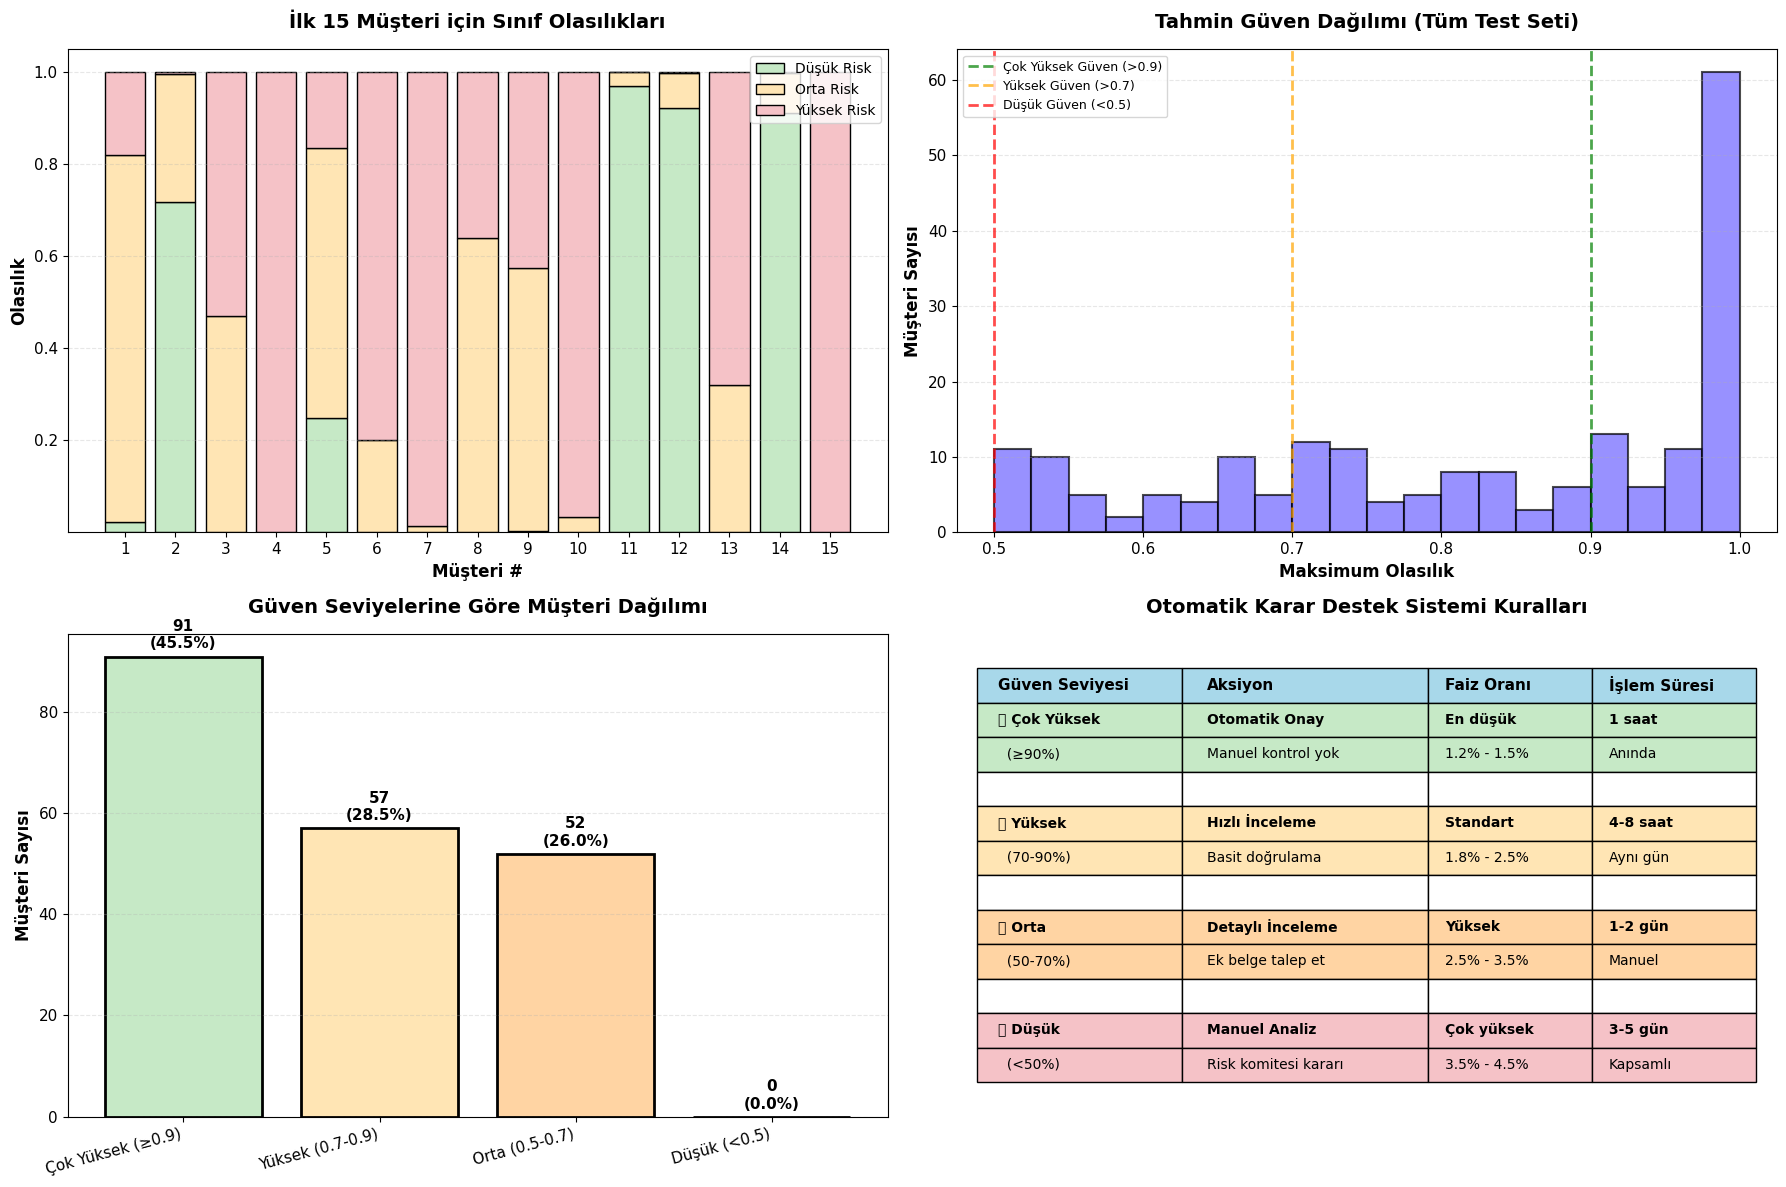


💡 GÜVEN SEVİYESİ ANALİZİ

📊 Test Setindeki Güven Dağılımı:
   Çok Yüksek (≥0.9)   :  91 müşteri ( 45.5%)
   Yüksek (0.7-0.9)    :  57 müşteri ( 28.5%)
   Orta (0.5-0.7)      :  52 müşteri ( 26.0%)
   Düşük (<0.5)        :   0 müşteri (  0.0%)

🎯 Model Güvenilirliği:
   • Yüksek güven oranı: 74.0% (148/200)
   ⚠️ Model çoğu tahmininde güvenilir ancak manuel kontrol önerilir

💼 İŞ ETKİSİ TAHMİNİ:
----------------------------------------------------------------------

   Günlük 1000 başvuru için:
   • Otomatik işlem: 455 başvuru (455 saat)
   • Hızlı inceleme: 285 başvuru (1710 saat)
   • Manuel analiz: 260 başvuru (6240 saat)

   💰 Süre Tasarrufu:
      Öncesi: 24,000 iş saati
      Sonrası: 8,405 iş saati
      Tasarruf: 15,595 iş saati (65.0%)

   💵 Maliyet Tasarrufu (günlük):
      7,797,500 TL / gün
      233,925,000 TL / ay
      2,846,087,500 TL / yıl


In [42]:
print("🎯 OLASILIK TAHMİNLERİ VE KARAR DESTEĞİ SİSTEMİ")
print("="*70)

# İlk 15 test örneği için olasılık tahminlerini göster
n_samples = 15
sample_indices = np.arange(n_samples)

print(f"\n📊 İLK {n_samples} TEST ÖRNEĞİ İÇİN OLASILIK TAHMİNLERİ:")
print("="*70)

# Tablo formatında göster
prediction_data = []
for idx in sample_indices:
    gercek = y_test_multi.iloc[idx]
    tahmin = y_pred_multinomial[idx]
    probalar = y_proba_multinomial[idx]
    
    # En yüksek olasılık
    max_proba = probalar.max()
    
    # Doğru mu?
    dogru = "✅" if gercek == tahmin else "❌"
    
    # Güven seviyesi
    if max_proba >= 0.90:
        guven = "Çok Yüksek"
        guven_icon = "🟢"
    elif max_proba >= 0.70:
        guven = "Yüksek"
        guven_icon = "🟡"
    elif max_proba >= 0.50:
        guven = "Orta"
        guven_icon = "🟠"
    else:
        guven = "Düşük"
        guven_icon = "🔴"
    
    prediction_data.append({
        'idx': idx + 1,
        'gercek': risk_labels[gercek],
        'tahmin': risk_labels[tahmin],
        'dogru': dogru,
        'p_dusuk': probalar[0],
        'p_orta': probalar[1],
        'p_yuksek': probalar[2],
        'max_proba': max_proba,
        'guven': guven,
        'guven_icon': guven_icon
    })

# İlk 10 örneği detaylı göster
for i, data in enumerate(prediction_data[:10]):
    print(f"\n📋 Müşteri #{data['idx']}:")
    print(f"   Gerçek: {data['gercek']:12s} | Tahmin: {data['tahmin']:12s} {data['dogru']}")
    print(f"   Olasılıklar:")
    print(f"      🟢 Düşük Risk  : {data['p_dusuk']:.1%}")
    print(f"      🟡 Orta Risk   : {data['p_orta']:.1%}")
    print(f"      🔴 Yüksek Risk : {data['p_yuksek']:.1%}")
    print(f"   {data['guven_icon']} Güven Seviyesi: {data['guven']} ({data['max_proba']:.1%})")

# Görselleştirme
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Olasılık dağılımı (stacked bar)
x_pos = np.arange(n_samples)
probas_dusuk = y_proba_multinomial[:n_samples, 0]
probas_orta = y_proba_multinomial[:n_samples, 1]
probas_yuksek = y_proba_multinomial[:n_samples, 2]

axes[0, 0].bar(x_pos, probas_dusuk, label='Düşük Risk', color='#C6E9C6', edgecolor='black', linewidth=1)
axes[0, 0].bar(x_pos, probas_orta, bottom=probas_dusuk, label='Orta Risk', 
              color='#FFE5B4', edgecolor='black', linewidth=1)
axes[0, 0].bar(x_pos, probas_yuksek, bottom=probas_dusuk + probas_orta, 
              label='Yüksek Risk', color='#F5C2C7', edgecolor='black', linewidth=1)

axes[0, 0].set_xlabel('Müşteri #', fontsize=12, weight='bold')
axes[0, 0].set_ylabel('Olasılık', fontsize=12, weight='bold')
axes[0, 0].set_title(f'İlk {n_samples} Müşteri için Sınıf Olasılıkları', 
                    fontsize=14, weight='bold', pad=15)
axes[0, 0].legend(loc='upper right', fontsize=10)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels([f"{i+1}" for i in x_pos])
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# 2. Maksimum olasılık dağılımı
max_probas = y_proba_multinomial.max(axis=1)

axes[0, 1].hist(max_probas, bins=20, color='#6C63FF', alpha=0.7, 
               edgecolor='black', linewidth=1.5)
axes[0, 1].axvline(x=0.9, color='green', linestyle='--', linewidth=2, 
                  alpha=0.7, label='Çok Yüksek Güven (>0.9)')
axes[0, 1].axvline(x=0.7, color='orange', linestyle='--', linewidth=2, 
                  alpha=0.7, label='Yüksek Güven (>0.7)')
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, 
                  alpha=0.7, label='Düşük Güven (<0.5)')

axes[0, 1].set_xlabel('Maksimum Olasılık', fontsize=12, weight='bold')
axes[0, 1].set_ylabel('Müşteri Sayısı', fontsize=12, weight='bold')
axes[0, 1].set_title('Tahmin Güven Dağılımı (Tüm Test Seti)', 
                    fontsize=14, weight='bold', pad=15)
axes[0, 1].legend(loc='upper left', fontsize=9)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# 3. Güven seviyelerine göre dağılım
guven_counts = {
    'Çok Yüksek (≥0.9)': (max_probas >= 0.9).sum(),
    'Yüksek (0.7-0.9)': ((max_probas >= 0.7) & (max_probas < 0.9)).sum(),
    'Orta (0.5-0.7)': ((max_probas >= 0.5) & (max_probas < 0.7)).sum(),
    'Düşük (<0.5)': (max_probas < 0.5).sum()
}

colors_guven = ['#C6E9C6', '#FFE5B4', '#FFD4A3', '#F5C2C7']
bars = axes[1, 0].bar(guven_counts.keys(), guven_counts.values(), 
                     color=colors_guven, edgecolor='black', linewidth=2)

axes[1, 0].set_ylabel('Müşteri Sayısı', fontsize=12, weight='bold')
axes[1, 0].set_title('Güven Seviyelerine Göre Müşteri Dağılımı', 
                    fontsize=14, weight='bold', pad=15)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Bar üzerinde değerleri göster
for bar, count in zip(bars, guven_counts.values()):
    height = bar.get_height()
    yuzde = (count / len(y_test_multi)) * 100
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{count}\n({yuzde:.1f}%)',
                   ha='center', va='bottom', fontsize=11, weight='bold')

axes[1, 0].set_xticklabels(guven_counts.keys(), rotation=15, ha='right')

# 4. Karar desteği sistemi simülasyonu (tablo)
axes[1, 1].axis('off')

# Güven seviyelerine göre aksiyon önerileri
table_data = [
    ['Güven Seviyesi', 'Aksiyon', 'Faiz Oranı', 'İşlem Süresi'],
    ['🟢 Çok Yüksek', 'Otomatik Onay', 'En düşük', '1 saat'],
    ['  (≥90%)', 'Manuel kontrol yok', '1.2% - 1.5%', 'Anında'],
    ['', '', '', ''],
    ['🟡 Yüksek', 'Hızlı İnceleme', 'Standart', '4-8 saat'],
    ['  (70-90%)', 'Basit doğrulama', '1.8% - 2.5%', 'Aynı gün'],
    ['', '', '', ''],
    ['🟠 Orta', 'Detaylı İnceleme', 'Yüksek', '1-2 gün'],
    ['  (50-70%)', 'Ek belge talep et', '2.5% - 3.5%', 'Manuel'],
    ['', '', '', ''],
    ['🔴 Düşük', 'Manuel Analiz', 'Çok yüksek', '3-5 gün'],
    ['  (<50%)', 'Risk komitesi kararı', '3.5% - 4.5%', 'Kapsamlı']
]

table = axes[1, 1].table(cellText=table_data, cellLoc='left', loc='center',
                        colWidths=[0.25, 0.3, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# Header
for i in range(4):
    table[(0, i)].set_facecolor('#A8D8EA')
    table[(0, i)].set_text_props(weight='bold', size=11)

# Satırlar - renklendirme
row_colors = ['#C6E9C6', '#C6E9C6', '#FFFFFF', 
              '#FFE5B4', '#FFE5B4', '#FFFFFF',
              '#FFD4A3', '#FFD4A3', '#FFFFFF',
              '#F5C2C7', '#F5C2C7']

for i in range(1, len(table_data)):
    for j in range(4):
        table[(i, j)].set_facecolor(row_colors[i-1])
        if table_data[i][0] and '🔴' in table_data[i][0] or '🟢' in table_data[i][0] or '🟡' in table_data[i][0] or '🟠' in table_data[i][0]:
            table[(i, j)].set_text_props(weight='bold')

axes[1, 1].set_title('Otomatik Karar Destek Sistemi Kuralları', 
                    fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 GÜVEN SEVİYESİ ANALİZİ")
print("="*70)

print(f"\n📊 Test Setindeki Güven Dağılımı:")
for seviye, sayi in guven_counts.items():
    yuzde = (sayi / len(y_test_multi)) * 100
    print(f"   {seviye:20s}: {sayi:3d} müşteri ({yuzde:5.1f}%)")

print(f"\n🎯 Model Güvenilirliği:")
yuksek_guven = guven_counts['Çok Yüksek (≥0.9)'] + guven_counts['Yüksek (0.7-0.9)']
yuksek_guven_yuzde = (yuksek_guven / len(y_test_multi)) * 100

print(f"   • Yüksek güven oranı: {yuksek_guven_yuzde:.1f}% ({yuksek_guven}/{len(y_test_multi)})")

if yuksek_guven_yuzde >= 80:
    print(f"   ✅ Model tahminlerine yüksek güvenle güvenilebilir")
elif yuksek_guven_yuzde >= 60:
    print(f"   ⚠️ Model çoğu tahmininde güvenilir ancak manuel kontrol önerilir")
else:
    print(f"   🔴 Model tahminlerinde güven düşük - iyileştirme gerekli")

print(f"\n💼 İŞ ETKİSİ TAHMİNİ:")
print("-" * 70)

# Otomasyondan tasarruf hesaplama
otomatik = guven_counts['Çok Yüksek (≥0.9)']
hizli_inceleme = guven_counts['Yüksek (0.7-0.9)']
manuel = guven_counts['Orta (0.5-0.7)'] + guven_counts['Düşük (<0.5)']

# Günlük 1000 başvuru varsayımı
gunluk_basvuru = 1000
otomasyonlaşan = (otomatik / len(y_test_multi)) * gunluk_basvuru
hizli_incelenecek = (hizli_inceleme / len(y_test_multi)) * gunluk_basvuru
manuel_incelenecek = (manuel / len(y_test_multi)) * gunluk_basvuru

# Süre tasarrufu
otomatik_sure = 1  # saat
hizli_sure = 6    # saat
manuel_sure = 24  # saat

onceki_sure = gunluk_basvuru * manuel_sure  # Tümü manuel
yeni_sure = (otomasyonlaşan * otomatik_sure + 
            hizli_incelenecek * hizli_sure + 
            manuel_incelenecek * manuel_sure)

tasarruf = onceki_sure - yeni_sure
tasarruf_yuzde = (tasarruf / onceki_sure) * 100

print(f"\n   Günlük {int(gunluk_basvuru)} başvuru için:")
print(f"   • Otomatik işlem: {int(otomasyonlaşan)} başvuru ({int(otomasyonlaşan * otomatik_sure)} saat)")
print(f"   • Hızlı inceleme: {int(hizli_incelenecek)} başvuru ({int(hizli_incelenecek * hizli_sure)} saat)")
print(f"   • Manuel analiz: {int(manuel_incelenecek)} başvuru ({int(manuel_incelenecek * manuel_sure)} saat)")
print(f"\n   💰 Süre Tasarrufu:")
print(f"      Öncesi: {int(onceki_sure):,} iş saati")
print(f"      Sonrası: {int(yeni_sure):,} iş saati")
print(f"      Tasarruf: {int(tasarruf):,} iş saati ({tasarruf_yuzde:.1f}%)")

# Maliyet tasarrufu (1 adam-saat = 500 TL varsayımı)
adam_saat_maliyeti = 500
maliyet_tasarrufu = tasarruf * adam_saat_maliyeti
print(f"\n   💵 Maliyet Tasarrufu (günlük):")
print(f"      {int(maliyet_tasarrufu):,} TL / gün")
print(f"      {int(maliyet_tasarrufu * 30):,} TL / ay")
print(f"      {int(maliyet_tasarrufu * 365):,} TL / yıl")